In [2]:
import warnings

import pytensor.tensor as at
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import scipy as sp

from scipy.special import expit as logistic

%config InlineBackend.figure_format = 'retina'
warnings.simplefilter(action="ignore", category=FutureWarning)
RANDOM_SEED = 8927
np.random.seed(286)

In [3]:
az.style.use("arviz-darkgrid")
az.rcParams["stats.hdi_prob"] = 0.89


def standardize(series):
    """Standardize a pandas series"""
    return (series - series.mean()) / series.std()

#### Code 12.1

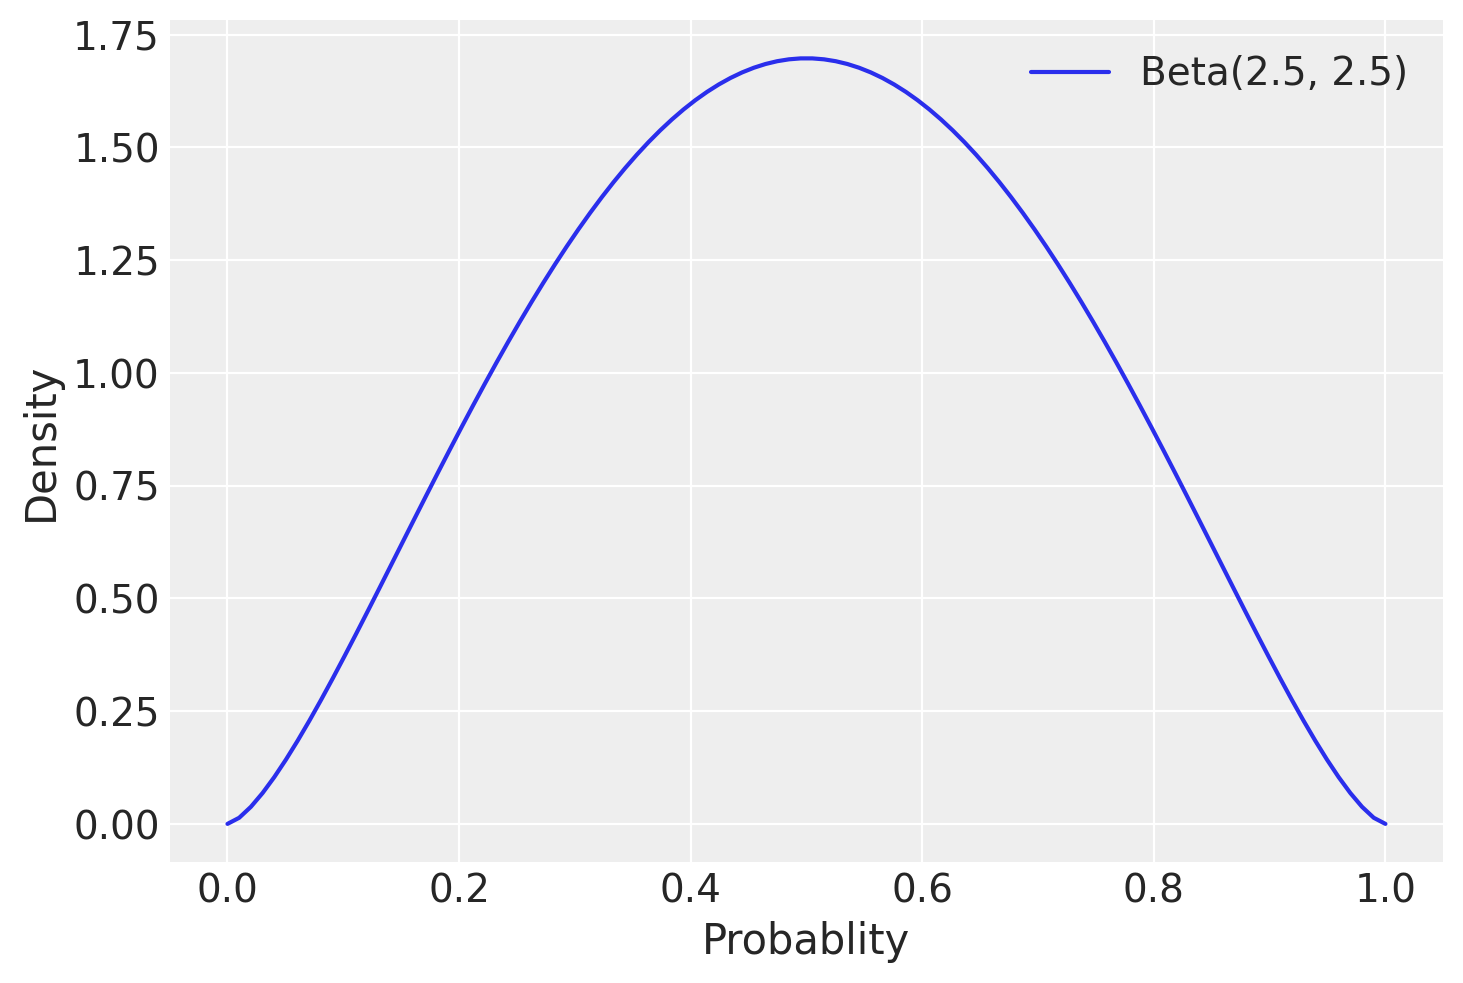

In [4]:
x_plot = np.linspace(0, 1, 100)
pbar = 0.5
theta = 5.0
plt.plot(
    x_plot,
    sp.stats.beta.pdf(x_plot[:, np.newaxis], pbar * theta, (1 - pbar) * theta),
    label=f"Beta({pbar * theta}, {(1 - pbar) * theta})",
)
plt.xlabel("Probablity")
plt.ylabel("Density")
plt.legend();

#### Code 12.2

In [7]:
admit_df = pd.read_csv("Data/UCBadmit.csv", sep=";")
N = admit_df.applications.values
gid = (admit_df["applicant.gender"] == "female").astype(int).values
admit_df.head()

,dept,applicant.gender,admit,reject,applications
1,A,male,512,313,825
2,A,female,89,19,108
3,B,male,353,207,560
4,B,female,17,8,25
5,C,male,120,205,325


In [8]:
with pm.Model() as m12_1:
    a = pm.Normal("a", 0.0, 1.5, shape=2)
    phi = pm.Exponential("phi", 1.0)

    theta = pm.Deterministic("theta", phi + 2.0)
    pbar = pm.Deterministic("pbar", pm.math.invlogit(a[gid]))

    A = pm.BetaBinomial("A", pbar * theta, (1.0 - pbar) * theta, N, observed=admit_df.admit.values)

    trace_12_1 = pm.sample(random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, phi]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 44 seconds.


#### Code 12.3

In [9]:
az.summary(trace_12_1, var_names=["a", "phi", "theta"], round_to=2)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],-0.44,0.40,-1.05,0.23,0.01,0.01,2536.71,2360.17,1.0
a[1],-0.32,0.41,-0.90,0.40,0.01,0.01,2760.38,2190.41,1.0
phi,1.03,0.78,0.00,2.07,0.01,0.01,2258.88,1466.42,1.0
theta,3.03,0.78,2.00,4.07,0.01,0.01,2258.88,1466.42,1.0


In [10]:
post_a = az.extract_dataset(trace_12_1["posterior"])["a"]
diff_a = post_a[0, :] - post_a[1, :]
az.summary({"diff_a": diff_a}, kind="stats", round_to=2)

,mean,sd,hdi_5.5%,hdi_94.5%
diff_a,-0.12,0.57,-1.07,0.76


#### Code 12.4

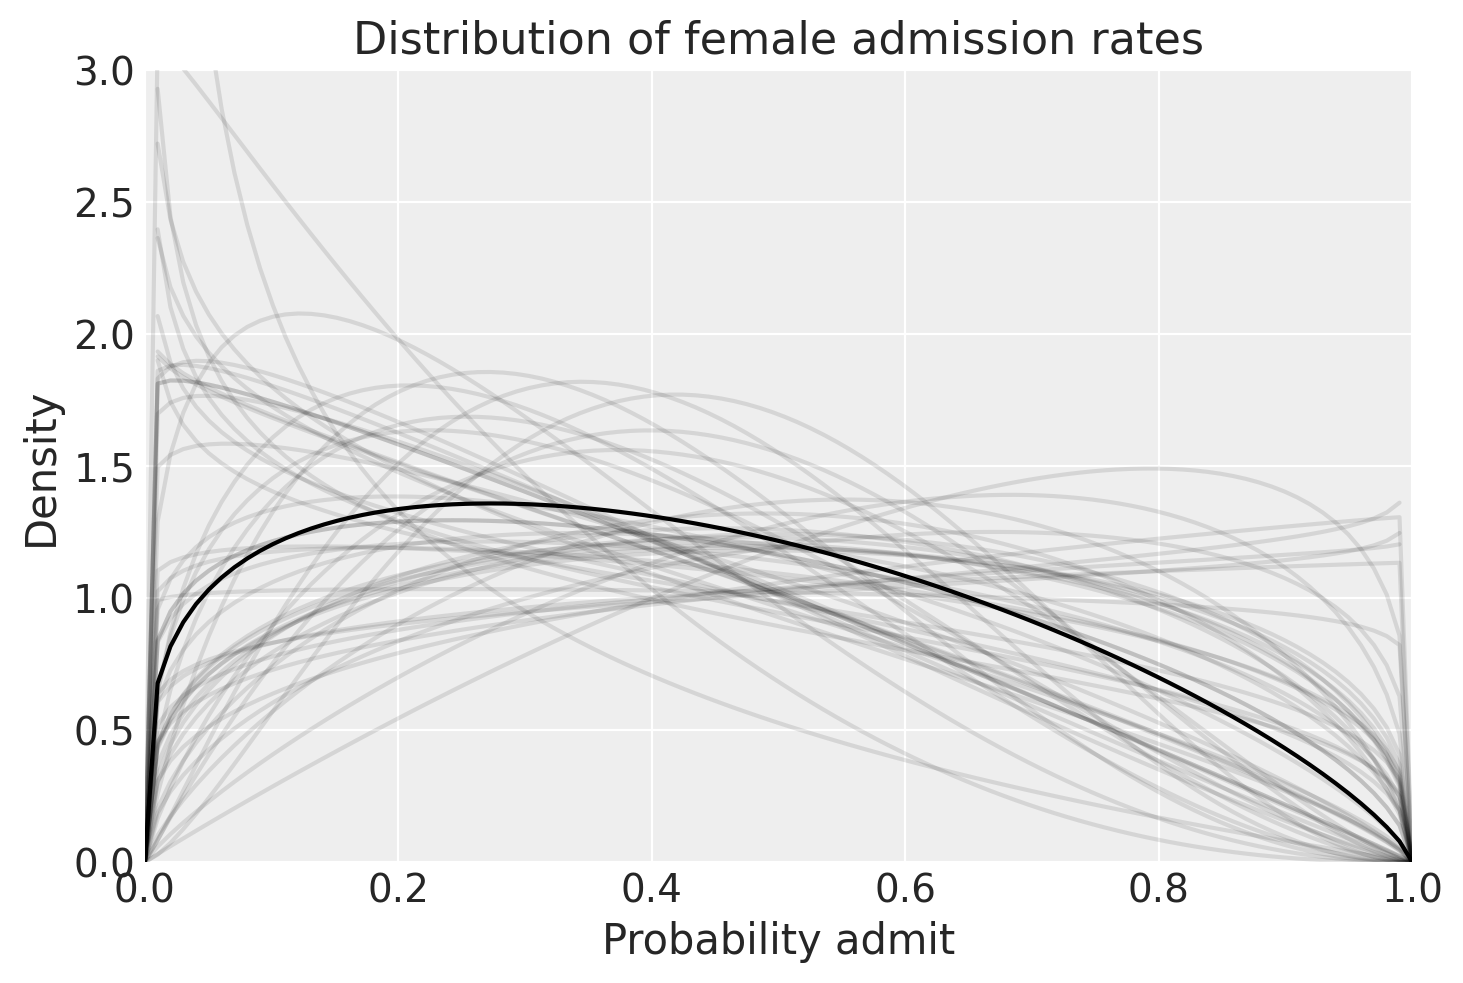

In [11]:
gid = 1
x_plot = np.linspace(0, 1, 100)
post_theta = az.extract_dataset(trace_12_1["posterior"])["theta"]

# draw posterior mean beta distribution:
pbar_mean = logistic(post_a[gid, :]).mean()
theta_mean = post_theta.mean()
plt.plot(
    x_plot,
    sp.stats.beta.pdf(x_plot, pbar_mean * theta_mean, (1.0 - pbar_mean) * theta_mean),
    c="k",
)

# draw 50 beta distributions sampled from posterior:
plt.plot(
    x_plot,
    sp.stats.beta.pdf(
        x_plot[:, np.newaxis],
        logistic(post_a[gid, :])[:50] * post_theta[:50],
        (1.0 - logistic(post_a[gid, :])[:50]) * post_theta[:50],
    ),
    c="k",
    alpha=0.1,
)

plt.xlim(0.0, 1.0)
plt.xlabel("Probability admit")
plt.ylim(0.0, 3.0)
plt.ylabel("Density")
plt.title("Distribution of female admission rates");

#### Code 12.5

In [12]:
with m12_1:
    ppc = pm.sample_posterior_predictive(trace_12_1, random_seed=RANDOM_SEED)[
        "posterior_predictive"
    ]["A"]
pp_admit = ppc / N

Sampling: [A]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

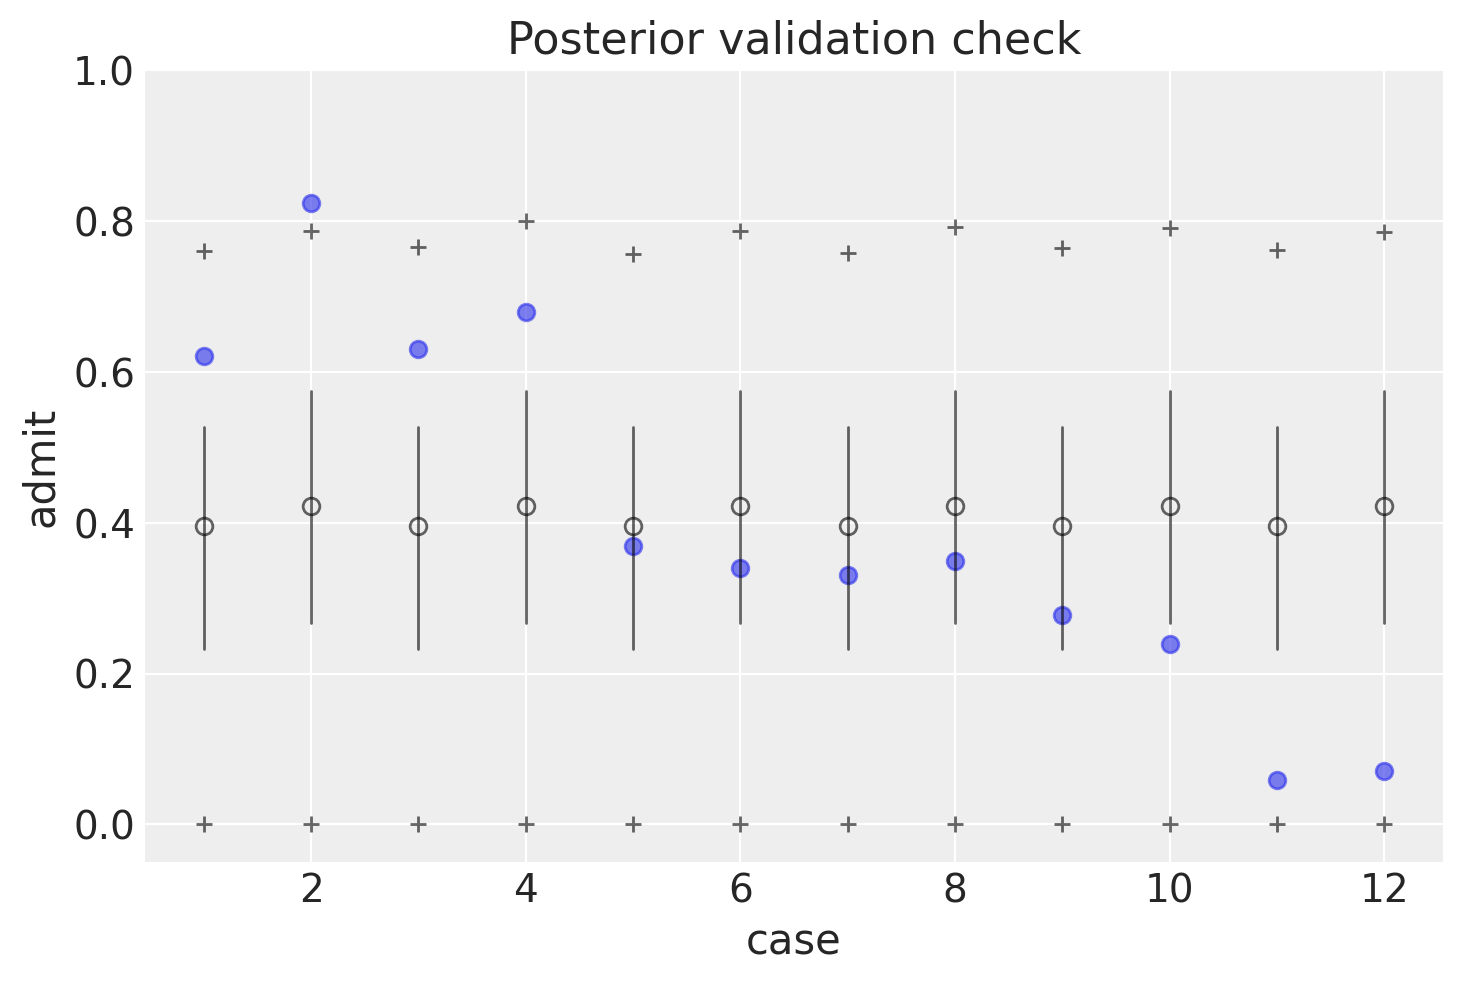

In [14]:
plt.plot(range(1, 13), admit_df.admit / N, "C0o", ms=6, alpha=0.6)
plt.plot(
    range(1, 13),
    trace_12_1["posterior"]["pbar"].mean(["chain", "draw"]),
    "ko",
    fillstyle="none",
    ms=6,
    alpha=0.6,
)
plt.plot(
    [range(1, 13), range(1, 13)],
    az.hdi(trace_12_1["posterior"]["pbar"])["pbar"].T,
    "k-",
    lw=1,
    alpha=0.6,
)
plt.plot([range(1, 13), range(1, 13)], az.hdi(pp_admit)["A"].T, "k+", ms=6, alpha=0.6)

plt.xlabel("case")
plt.ylabel("admit")
plt.title("Posterior validation check")
plt.ylim(-0.05, 1);

#### Code 12.6

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, g, phi]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 351 seconds.
C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


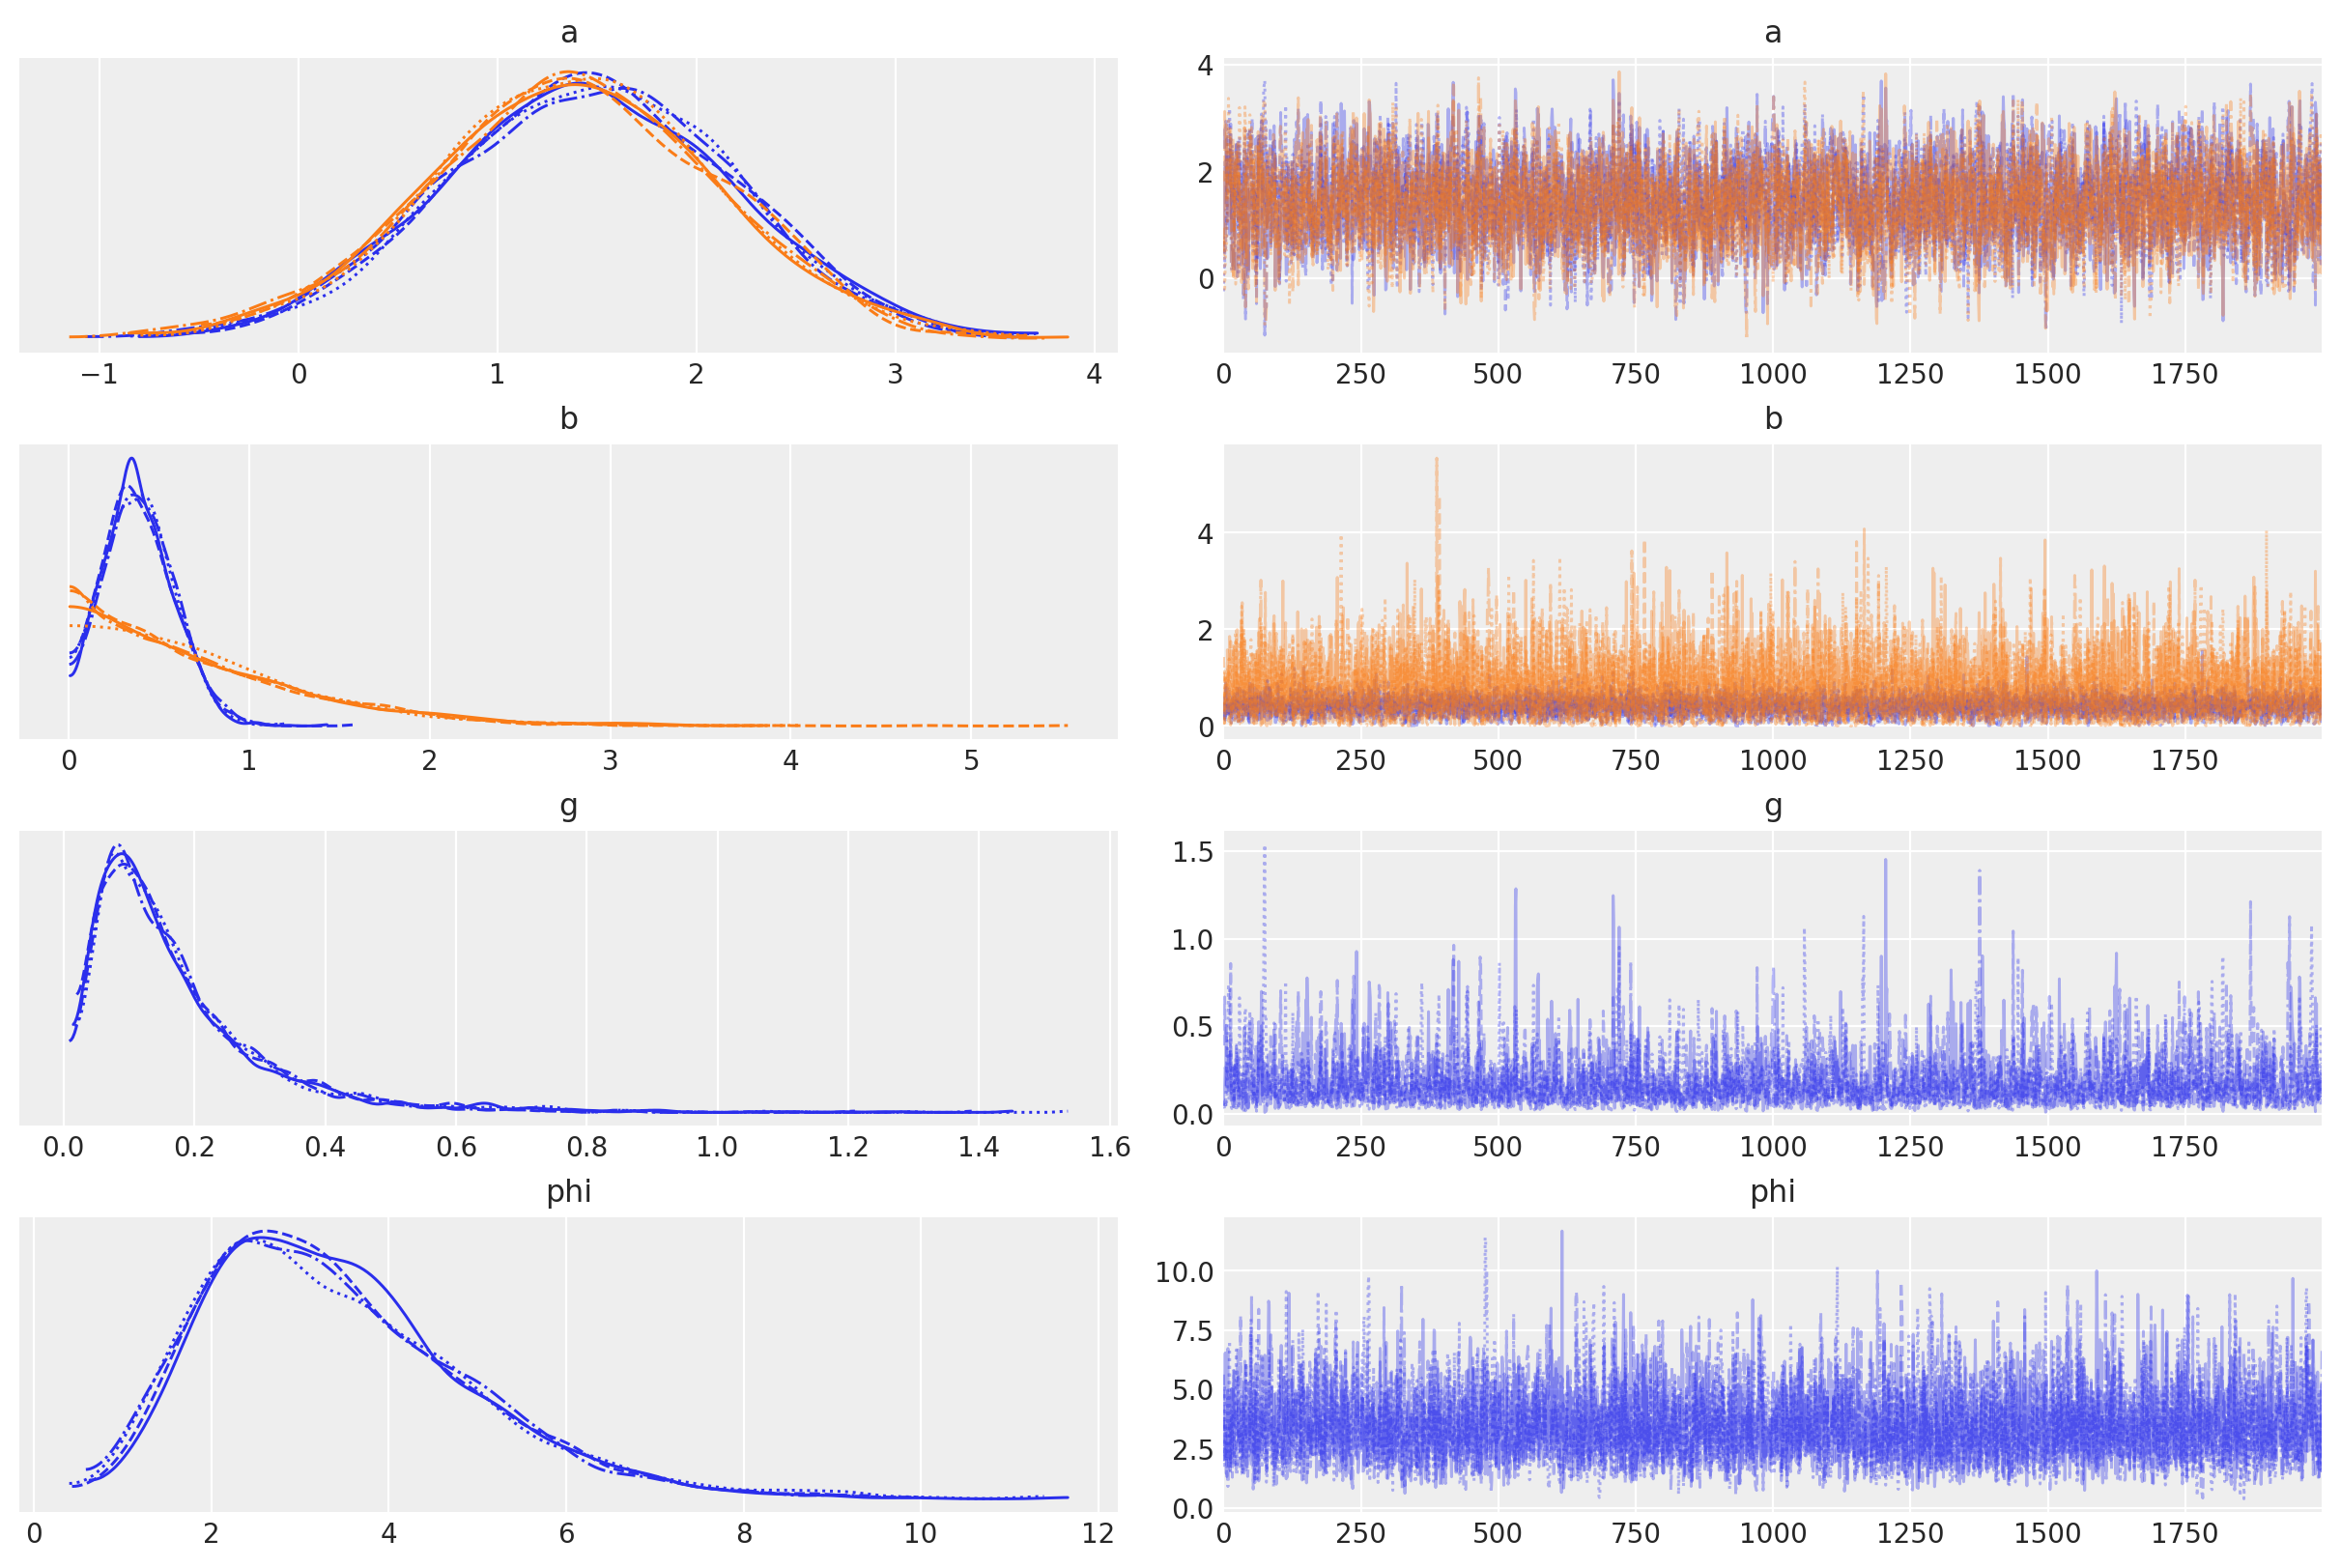

In [19]:
dk = pd.read_csv("Data/Kline", sep=";")
P = standardize(np.log(dk.population)).values
P = P + np.abs(P.min()) + 0.1  # must be > 0 (see chp. 11)
c_id = (dk.contact == "high").astype(int).values

with pm.Model() as m12_2:
    a = pm.Normal("a", 1.0, 1.0, shape=2)
    b = pm.Exponential("b", 1.0, shape=2)
    g = pm.Exponential("g", 1.0)
    phi = pm.Exponential("phi", 1.0)

    cid = pm.intX(pm.Data("cid", c_id))
    P_ = pm.Data("P", P)
    lam = (at.exp(a[cid]) * P_ ** b[cid]) / g

    T = pm.NegativeBinomial("total_tools", lam, phi, observed=dk.total_tools.values)

    trace_12_2 = pm.sample(2000, tune=2000, target_accept=0.9, random_seed=RANDOM_SEED,
                              return_inferencedata=True,
    idata_kwargs={"log_likelihood": True})

# store pareto-k values for plot:
k_12 = az.loo(trace_12_2, pointwise=True).pareto_k.values

az.plot_trace(trace_12_2, compact=True);

#### Bonus: Figure 12.2

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, g]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 401 seconds.
C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


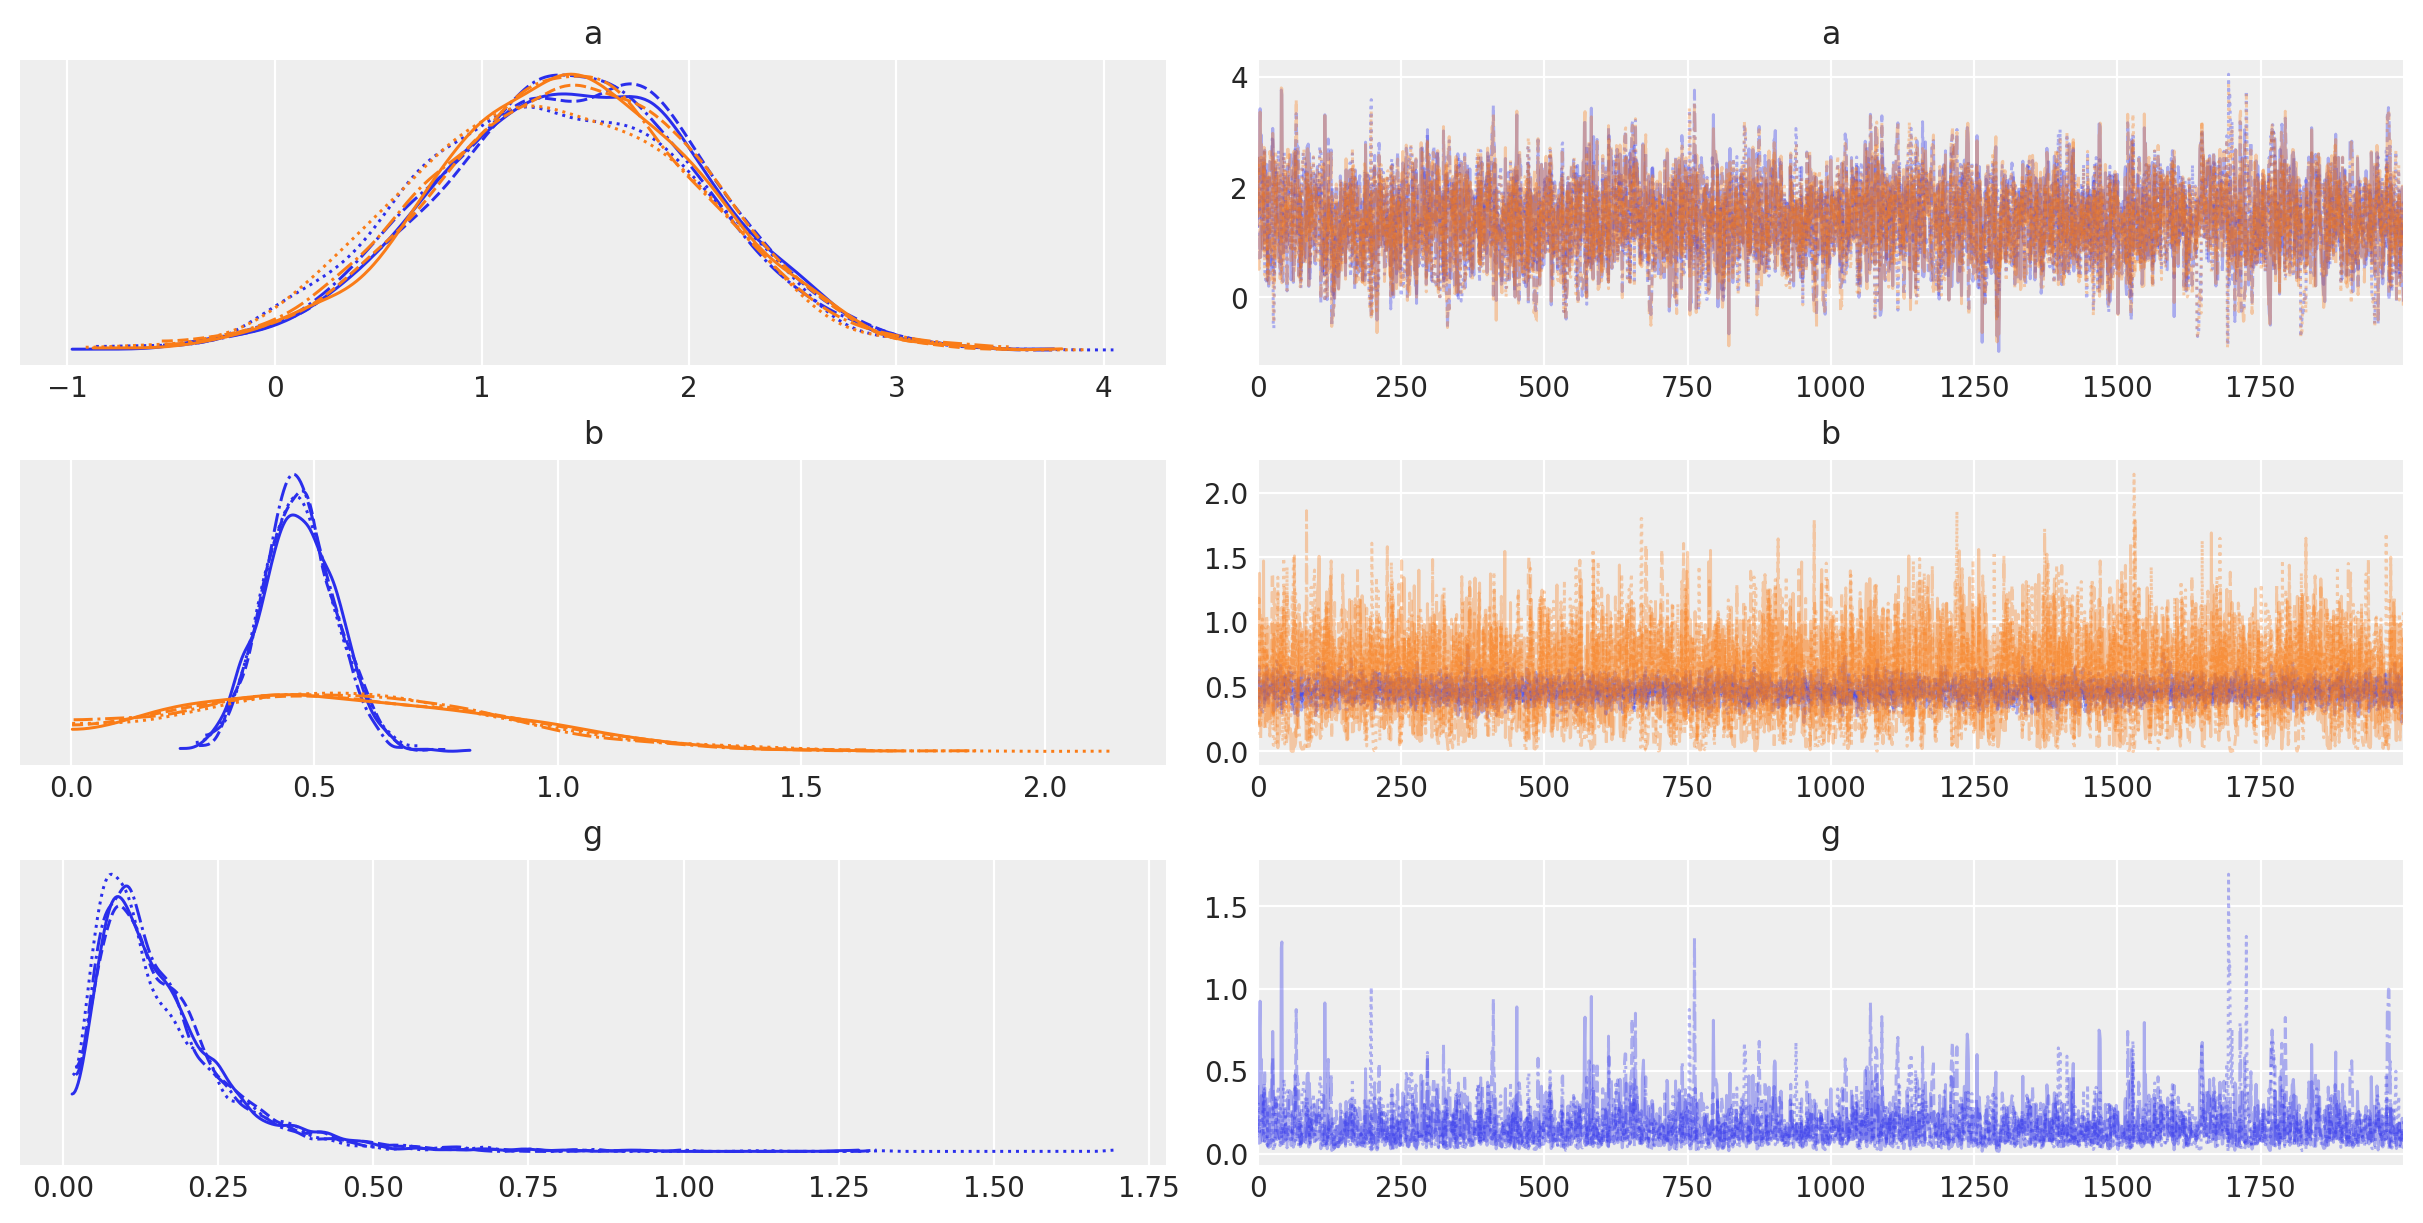

In [20]:
with pm.Model() as m11_11:
    a = pm.Normal("a", 1.0, 1.0, shape=2)
    b = pm.Exponential("b", 1.0, shape=2)
    g = pm.Exponential("g", 1.0)

    cid = pm.intX(pm.Data("cid", c_id))
    P_ = pm.Data("P", P)
    lam = (at.exp(a[cid]) * P_ ** b[cid]) / g

    T = pm.Poisson("total_tools", lam, observed=dk.total_tools.values)

    trace_11_11 = pm.sample(2000, tune=2000, target_accept=0.9, random_seed=RANDOM_SEED,
                           return_inferencedata=True,
    idata_kwargs={"log_likelihood": True})

# store pareto-k values for plot:
k_11 = az.loo(trace_11_11, pointwise=True).pareto_k.values

az.plot_trace(trace_11_11, compact=True);

In [22]:
ns = 10
P_seq = np.linspace(-1.4, 3.0, ns) + 1.4  # our little trick

with m11_11:
    # predictions for cid=0 (low contact)
    pm.set_data({"cid": np.array([0] * ns), "P": P_seq})
    lam0_11 = pm.sample_posterior_predictive(trace_11_11, var_names=["total_tools"])[
        "posterior_predictive"
    ]["total_tools"]

    # predictions for cid=1 (high contact)
    pm.set_data({"cid": np.array([1] * ns)})
    lam1_11 = pm.sample_posterior_predictive(trace_11_11, var_names=["total_tools"])[
        "posterior_predictive"
    ]["total_tools"]

with m12_2:
    pm.set_data({"cid": np.array([0] * ns), "P": P_seq})
    lam0_12 = pm.sample_posterior_predictive(trace_12_2, var_names=["total_tools"])[
        "posterior_predictive"
    ]["total_tools"]

    pm.set_data({"cid": np.array([1] * ns)})
    lam1_12 = pm.sample_posterior_predictive(trace_12_2, var_names=["total_tools"])[
        "posterior_predictive"
    ]["total_tools"]

lmu0_11, lmu1_11 = lam0_11.mean(["chain", "draw"]), lam1_11.mean(["chain", "draw"])
lmu0_12, lmu1_12 = lam0_12.mean(["chain", "draw"]), lam1_12.mean(["chain", "draw"])

Sampling: [total_tools]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [total_tools]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [total_tools]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [total_tools]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Text(0.5, 1.0, 'Gamma-Poisson model')

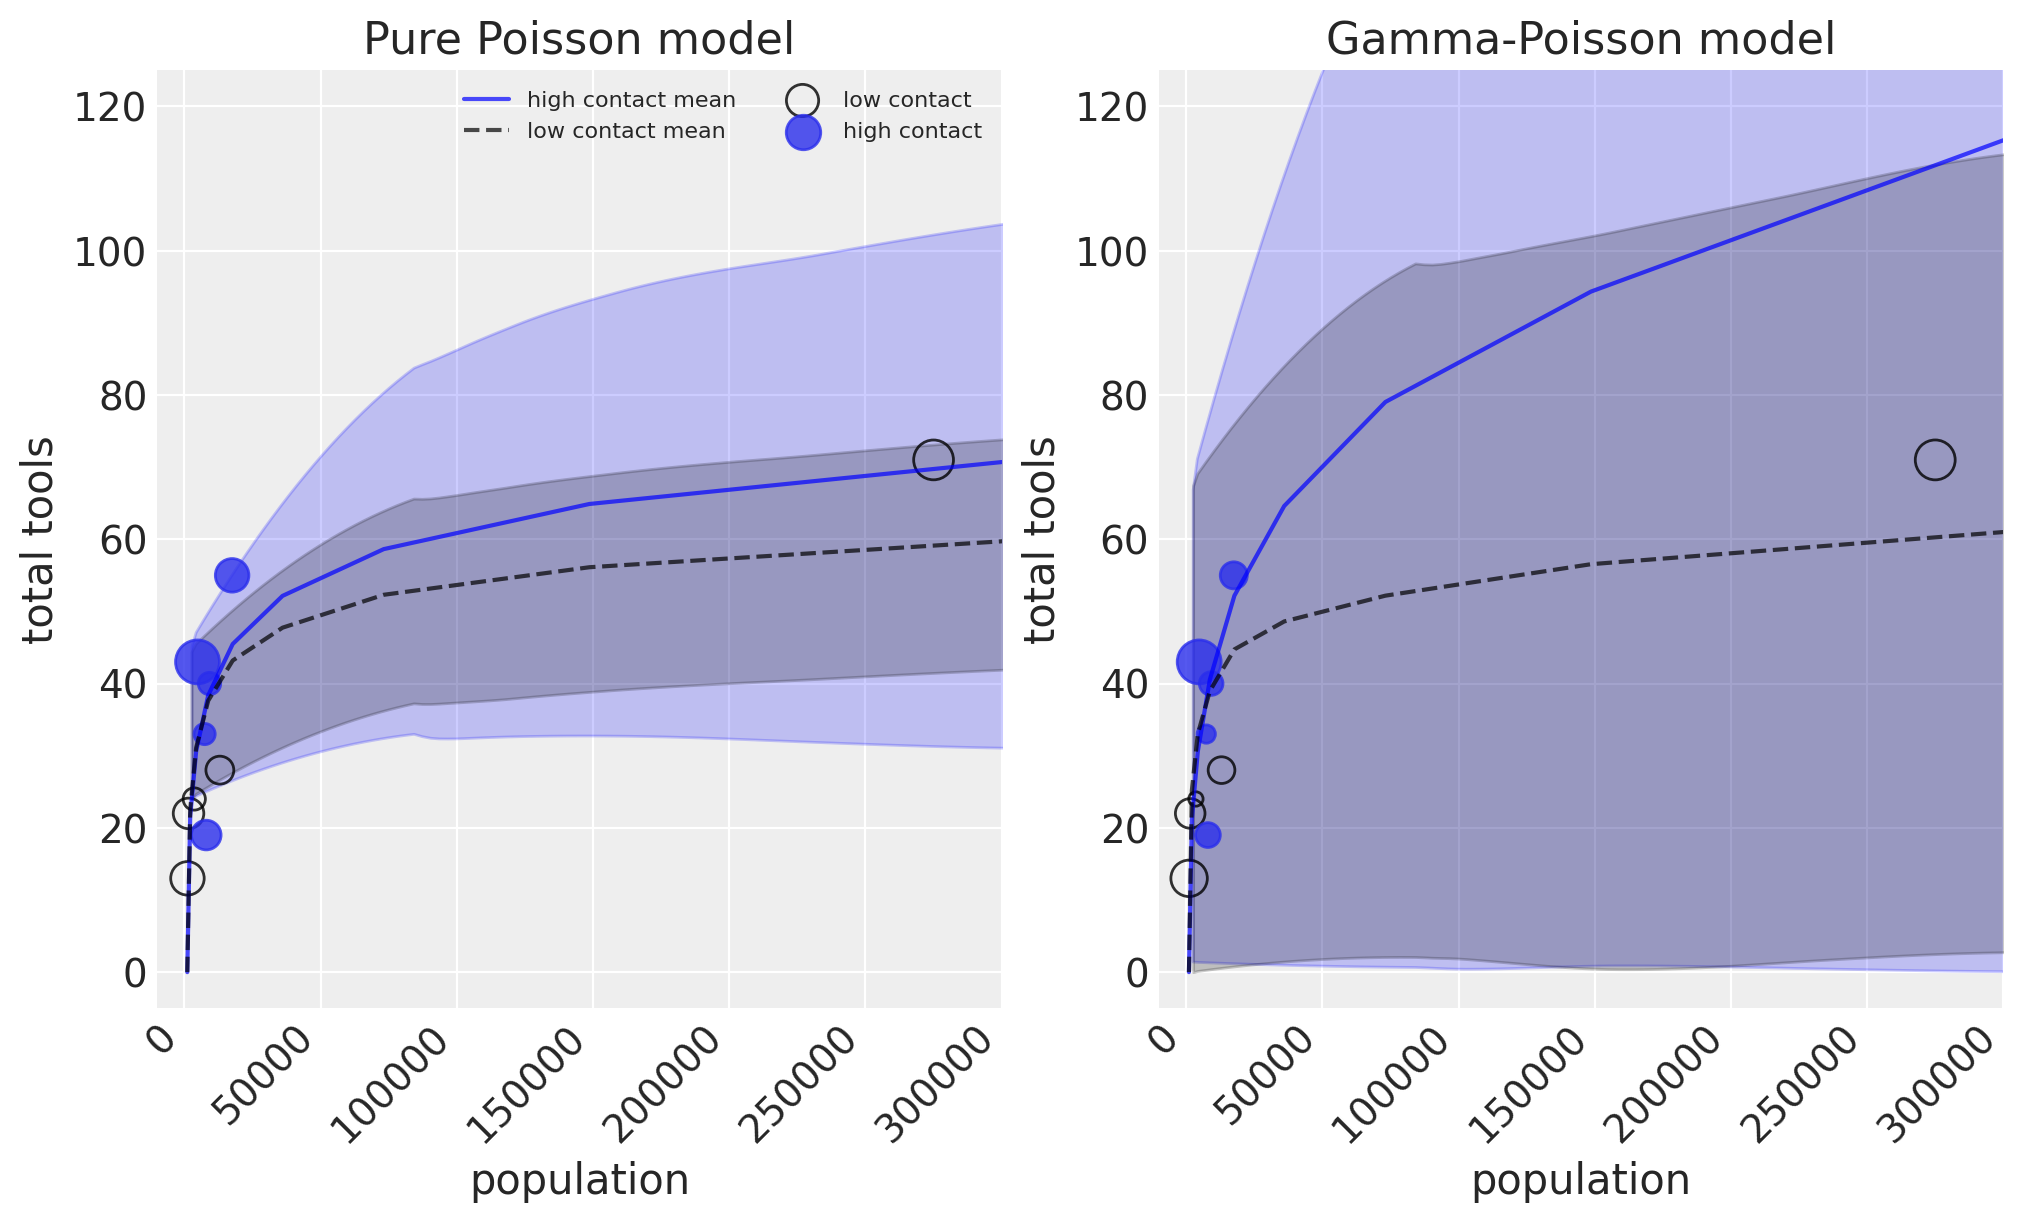

In [23]:
# scale point size to Pareto-k:
k_11 /= k_11.max()
psize_11 = 250 * k_11
k_12 /= k_12.max()
psize_12 = 250 * k_12

_, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 6))

# Poisson predictions:
# unstandardize our log pop sequence:
P_seq = np.exp(
    (P_seq - 1.4) * np.log(dk.population.values).std() + np.log(dk.population.values).mean()
)
az.plot_hdi(P_seq, lam1_11, color="b", fill_kwargs={"alpha": 0.2}, ax=ax0)
ax0.plot(P_seq, lmu1_11, color="b", alpha=0.7, label="high contact mean")

az.plot_hdi(P_seq, lam0_11, color="k", fill_kwargs={"alpha": 0.2}, ax=ax0)
ax0.plot(P_seq, lmu0_11, "--", color="k", alpha=0.7, label="low contact mean")

# display observed data:
index = c_id == 1
ax0.scatter(
    dk.population[~index],
    dk.total_tools[~index],
    s=psize_11[~index],
    facecolors="none",
    edgecolors="k",
    alpha=0.8,
    lw=1,
    label="low contact",
)
ax0.scatter(
    dk.population[index], dk.total_tools[index], s=psize_11[index], alpha=0.8, label="high contact"
)
plt.setp(ax0.get_xticklabels(), ha="right", rotation=45)
ax0.set_xlim((-10_000, 300_000))
ax0.set_xlabel("population")
ax0.set_ylabel("total tools")
ax0.set_ylim((-5, 125))
ax0.set_title("Pure Poisson model")
ax0.legend(fontsize=8, ncol=2)

# Gamma-Poisson predictions:
az.plot_hdi(P_seq, lam1_12, color="b", fill_kwargs={"alpha": 0.2}, ax=ax1)
ax1.plot(P_seq, lmu1_12, color="b", alpha=0.7)

az.plot_hdi(P_seq, lam0_12, color="k", fill_kwargs={"alpha": 0.2}, ax=ax1)
ax1.plot(P_seq, lmu0_12, "--", color="k", alpha=0.7)

# display observed data:
ax1.scatter(
    dk.population[~index],
    dk.total_tools[~index],
    s=psize_12[~index],
    facecolors="none",
    edgecolors="k",
    alpha=0.8,
    lw=1,
)
ax1.scatter(dk.population[index], dk.total_tools[index], s=psize_12[index], alpha=0.8)
plt.setp(ax1.get_xticklabels(), ha="right", rotation=45)
ax1.set_xlim((-10_000, 300_000))
ax1.set_xlabel("population")
ax1.set_ylim((-5, 125))
ax1.set_ylabel("total tools")
ax1.set_title("Gamma-Poisson model")

#### Code 12.7

In [24]:
# define parameters
PROB_DRINK = 0.2  # 20% of days
RATE_WORK = 1.0  # average 1 manuscript per day

# sample one year of production
N = 365

# simulate days monks drink
drink = np.random.binomial(1, PROB_DRINK, size=N)

# simulate manuscripts completed
y = (1 - drink) * np.random.poisson(RATE_WORK, size=N)

#### Code 12.8

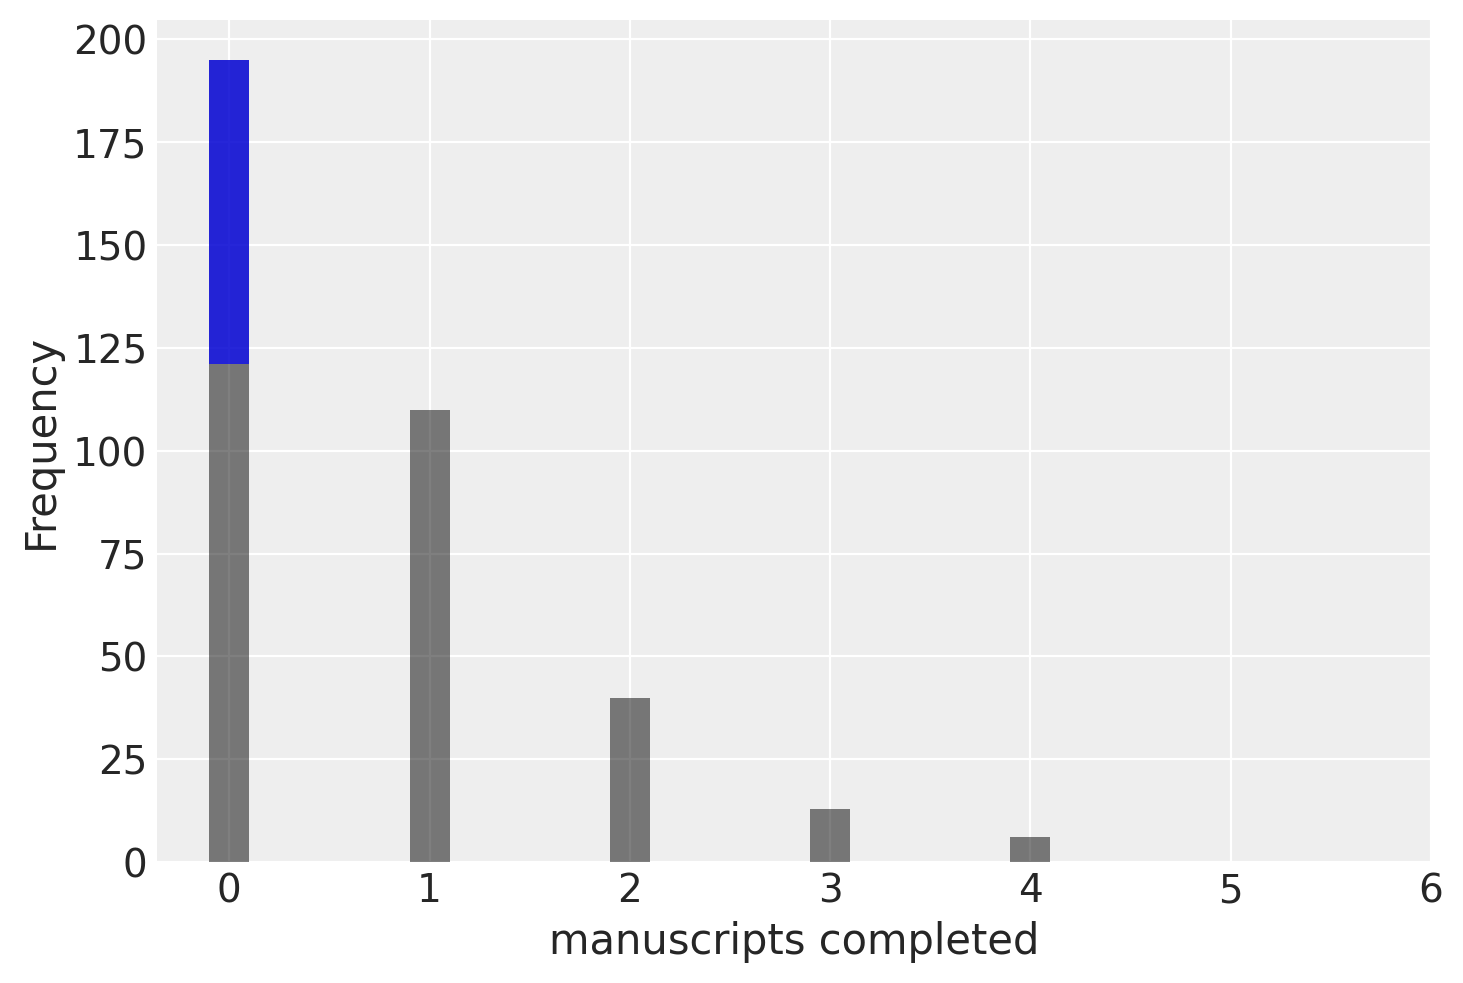

In [25]:
zeros_drink = drink.sum()
zeros_work = (y == 0).sum() - zeros_drink

bins = np.arange(y.max() + 1) - 0.5
plt.hist(y, bins=bins, align="mid", rwidth=0.2, color="k", alpha=0.5)
plt.bar(0.0, zeros_drink, bottom=zeros_work, width=0.2, color="b", alpha=0.7)

plt.xticks(bins + 0.5)
plt.xlabel("manuscripts completed")
plt.ylabel("Frequency");

#### Code 12.9

In [26]:
with pm.Model() as m12_3:
    ap = pm.Normal("ap", -1.5, 1.0)
    al = pm.Normal("al", 1.0, 0.5)

    p = pm.math.invlogit(ap)
    lambda_ = pm.math.exp(al)

    y_obs = pm.ZeroInflatedPoisson("y_obs", 1.0 - p, lambda_, observed=y)

    trace_12_3 = pm.sample(tune=2000, random_seed=RANDOM_SEED)
az.summary(trace_12_3, round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ap, al]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 947 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ap,-1.33,0.41,-1.95,-0.74,0.01,0.01,1225.51,1441.27,1.0
al,-0.08,0.10,-0.24,0.06,0.00,0.00,1309.07,1115.47,1.0


#### Code 12.10

In [27]:
logistic(trace_12_3["posterior"]["ap"]).mean(["chain", "draw"])  # probability drink

<xarray.DataArray 'ap' ()> Size: 8B
array(0.21621034)

In [28]:
np.exp(trace_12_3["posterior"]["al"]).mean(
    ["chain", "draw"]
)  # rate finish manuscripts, when not drinking

<xarray.DataArray 'al' ()> Size: 8B
array(0.92565113)

#### Code 12.11

Stan-related

#### Code 12.12

In [3]:
trolley_df = pd.read_csv("Data/Trolley.csv", sep=";")
trolley_df.head()

,case,response,order,id,age,male,edu,action,intention,contact,story,action2
0,cfaqu,4,2,96;434,14,0,Middle School,0,0,1,aqu,1
1,cfbur,3,31,96;434,14,0,Middle School,0,0,1,bur,1
2,cfrub,4,16,96;434,14,0,Middle School,0,0,1,rub,1
3,cibox,3,32,96;434,14,0,Middle School,0,1,1,box,1
4,cibur,3,4,96;434,14,0,Middle School,0,1,1,bur,1


#### Code 12.13

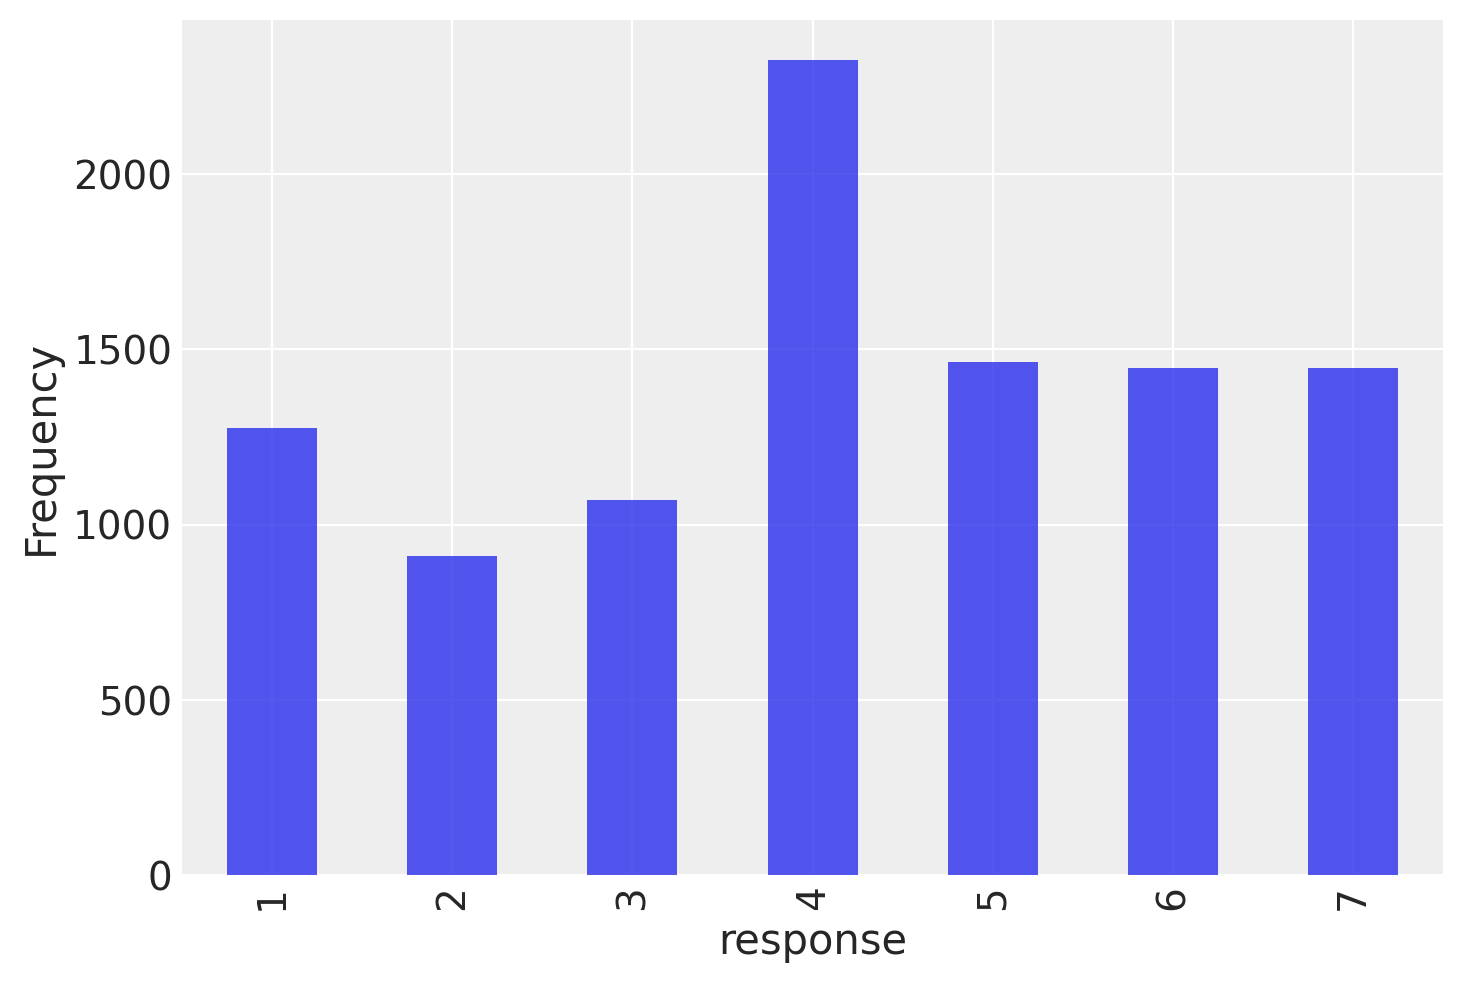

In [4]:
ax = trolley_df.response.sort_values().value_counts(sort=False).plot(kind="bar", alpha=0.8)
ax.set_xlabel("response")
ax.set_ylabel("Frequency");

#### Code 12.14

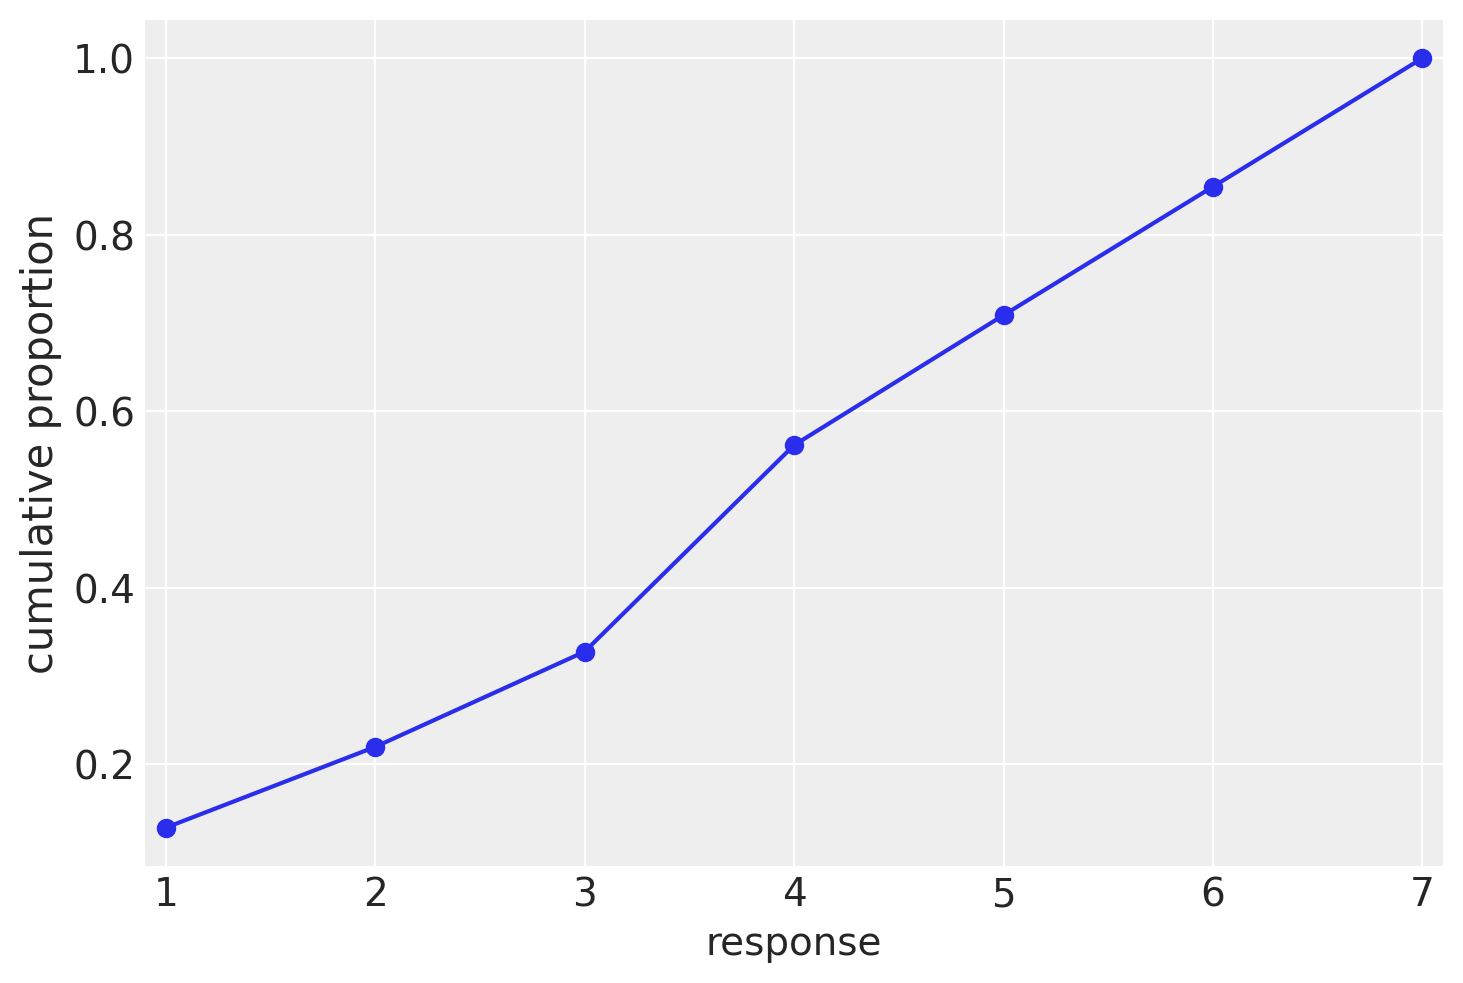

In [5]:
ax = (
    trolley_df.response.sort_values()
    .value_counts(normalize=True, sort=False)
    .cumsum()
    .plot(marker="o")
)

ax.set_xlim(0.9, 7.1)
ax.set_xlabel("response", fontsize=14)
ax.set_ylabel("cumulative proportion");

#### Code 12.15

In [6]:
lco = (
    trolley_df.response.sort_values()
    .value_counts(normalize=True, sort=False)
    .cumsum()
    .apply(sp.special.logit)
)
lco.round(2)

response
1   -1.92
2   -1.27
3   -0.72
4    0.25
5    0.89
6    1.77
7     NaN
Name: proportion, dtype: float64

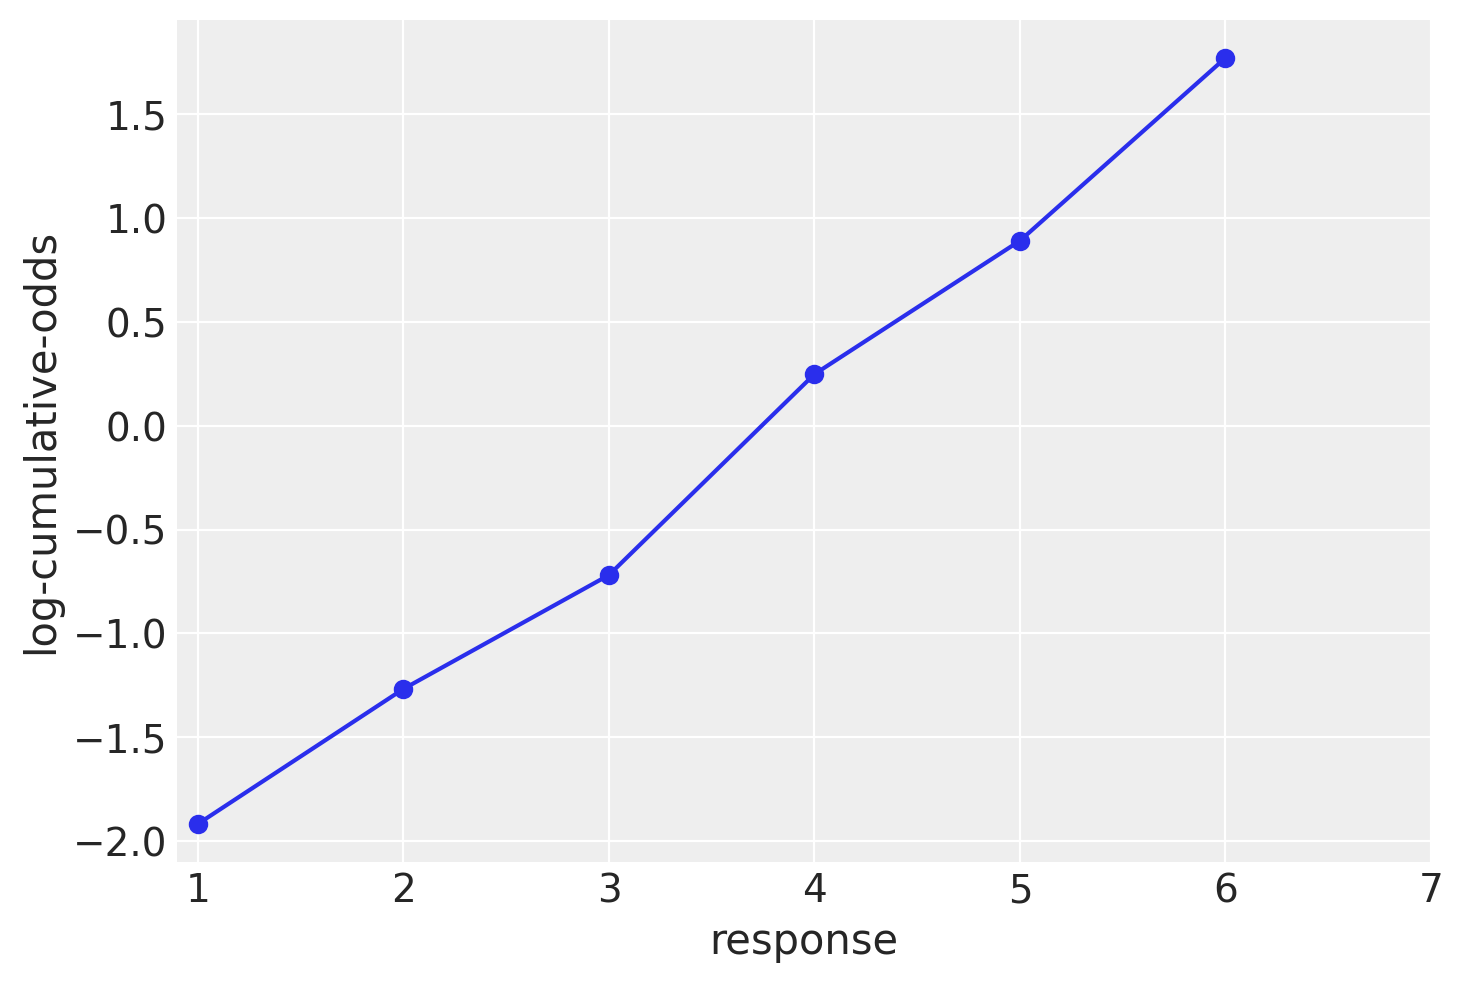

In [7]:
ax = lco.plot(marker="o")
ax.set_xlim(0.9, 7)
ax.set_xlabel("response")
ax.set_ylabel("log-cumulative-odds");

#### Code 12.16 / 17

In [8]:
with pm.Model() as m12_4:
    cutpoints = pm.Normal(
        "cutpoints",
        0.0,
        1.5,
        transform=pm.distributions.transforms.ordered,
        shape=6,
        initval=np.arange(6) - 2.5,
    )

    R = pm.OrderedLogistic("R", 0.0, cutpoints, observed=trolley_df.response.values - 1)

#### Code 12.18

In [9]:
with m12_4:
    trace_12_4 = pm.sample(random_seed=RANDOM_SEED)
az.summary(trace_12_4, round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1505 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
cutpoints[0],-1.92,0.03,-1.96,-1.87,0.0,0.0,4144.98,3069.65,1.0
cutpoints[1],-1.27,0.02,-1.31,-1.23,0.0,0.0,4504.09,3506.60,1.0
cutpoints[2],-0.72,0.02,-0.75,-0.68,0.0,0.0,5236.50,3415.31,1.0
cutpoints[3],0.25,0.02,0.22,0.28,0.0,0.0,4704.64,3457.20,1.0
cutpoints[4],0.89,0.02,0.85,0.92,0.0,0.0,5106.27,3436.90,1.0
cutpoints[5],1.77,0.03,1.72,1.81,0.0,0.0,5051.67,3136.69,1.0
R_probs[0],0.13,0.00,0.12,0.13,0.0,0.0,4144.98,3069.65,1.0
R_probs[1],0.09,0.00,0.09,0.10,0.0,0.0,5675.51,2912.53,1.0
R_probs[2],0.11,0.00,0.10,0.11,0.0,0.0,5387.01,3224.05,1.0
R_probs[3],0.23,0.00,0.23,0.24,0.0,0.0,4533.80,3267.13,1.0


#### Code 12.19

In [10]:
logistic(trace_12_4["posterior"]["cutpoints"]).mean(["chain", "draw"]).round(3)

<xarray.DataArray 'cutpoints' (cutpoints_dim_0: 6)> Size: 48B
array([0.128, 0.22 , 0.328, 0.562, 0.709, 0.854])
Coordinates:
  * cutpoints_dim_0  (cutpoints_dim_0) int64 48B 0 1 2 3 4 5

#### Code 12.20

In [11]:
def ordered_logistic_proba(a):
    p_cum = logistic(a)
    p_cum = np.concatenate(([0.0], p_cum, [1.0]))

    return p_cum[1:] - p_cum[:-1]


pk = ordered_logistic_proba(trace_12_4["posterior"]["cutpoints"].mean(["chain", "draw"]))
pk.round(2)

array([0.13, 0.09, 0.11, 0.23, 0.15, 0.15, 0.15])

#### Code 12.21

In [12]:
(pk * np.arange(1, 8)).sum()

np.float64(4.199106474644346)

#### Code 12.22

In [13]:
pk = ordered_logistic_proba(trace_12_4["posterior"]["cutpoints"].mean(["chain", "draw"]) - 0.5)
pk.round(2)

array([0.08, 0.06, 0.08, 0.21, 0.16, 0.18, 0.22])

#### Code 12.23

In [14]:
(pk * np.arange(1, 8)).sum()

np.float64(4.729541991470319)

#### Code 12.24

In [ ]:
R = trolley_df.response.values - 1

with pm.Model() as m12_5:
    cutpoints = pm.Normal(
        "cutpoints",
        0.0,
        1.5,
        transform=pm.distributions.transforms.ordered,
        shape=6,
        initval=np.arange(6) - 2.5,
    )
    bA = pm.Normal("bA", 0.0, 0.5)
    bC = pm.Normal("bC", 0.0, 0.5)
    bI = pm.Normal("bI", 0.0, 0.5)
    bIA = pm.Normal("bIA", 0.0, 0.5)
    bIC = pm.Normal("bIC", 0.0, 0.5)

    A = pm.Data("A", trolley_df.action.values)
    I = pm.Data("I", trolley_df.intention.values)
    C = pm.Data("C", trolley_df.contact.values)

    BI = bI + bIA * A + bIC * C
    phi = pm.Deterministic("phi", bA * A + bC * C + BI * I)

    resp_obs = pm.OrderedLogistic("resp_obs", phi, cutpoints, observed=R)

    trace_12_5 = pm.sample(random_seed=RANDOM_SEED)

az.summary(trace_12_5, var_names=["bIC", "bIA", "bC", "bI", "bA"], round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints, bA, bC, bI, bIA, bIC]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

#### Code 12.25

In [ ]:
az.plot_forest(
    trace_12_5, var_names=["bIC", "bIA", "bC", "bI", "bA"], figsize=(5, 2), combined=True
);

#### Code 12.26 - 28

In [ ]:
# Observed cum probs:
p_obs = (
    trolley_df.groupby(["action", "contact", "intention"])
    .response.value_counts(normalize=True, sort=False)
    .unstack()
    .cumsum(axis=1)
    .iloc[:, :-1]
)
p_obs.columns = range(6)
p_obs

In [ ]:
# Counterfactual cases:
cases_df = pd.DataFrame(
    np.array([[0, 0, 0], [0, 0, 1], [1, 0, 0], [1, 0, 1], [0, 1, 0], [0, 1, 1]]),
    columns=["action", "contact", "intention"],
)
cases_df

In [ ]:
with m12_5:
    pm.set_data(
        {
            "A": cases_df.action.values,
            "C": cases_df.contact.values,
            "I": cases_df.intention.values,
        }
    )
    pp_phi = pm.sample_posterior_predictive(trace_12_5, var_names=["phi"], random_seed=RANDOM_SEED)[
        "posterior_predictive"
    ]

In [37]:
def p_ord_logit(responses: range, phi: np.ndarray, a: np.ndarray):
    """
    For the given posterior sample, computes the cumulative probabilities
    of each response in each of the counterfactual values of the predictors.

    responses: range of possible responses in the experiment
    phi: posterior phi for each counterfactual case
    a: posterior intercept for each response
    """
    p = pd.DataFrame(index=range(len(cases_df)), columns=responses)
    for case in p.index:
        p.loc[case] = logistic(a - phi[case])

    p = pd.concat([cases_df, p], axis=1).set_index(["action", "contact", "intention"]).sort_index()
    p.index.name = "case"
    p.columns.name = "response"

    return p

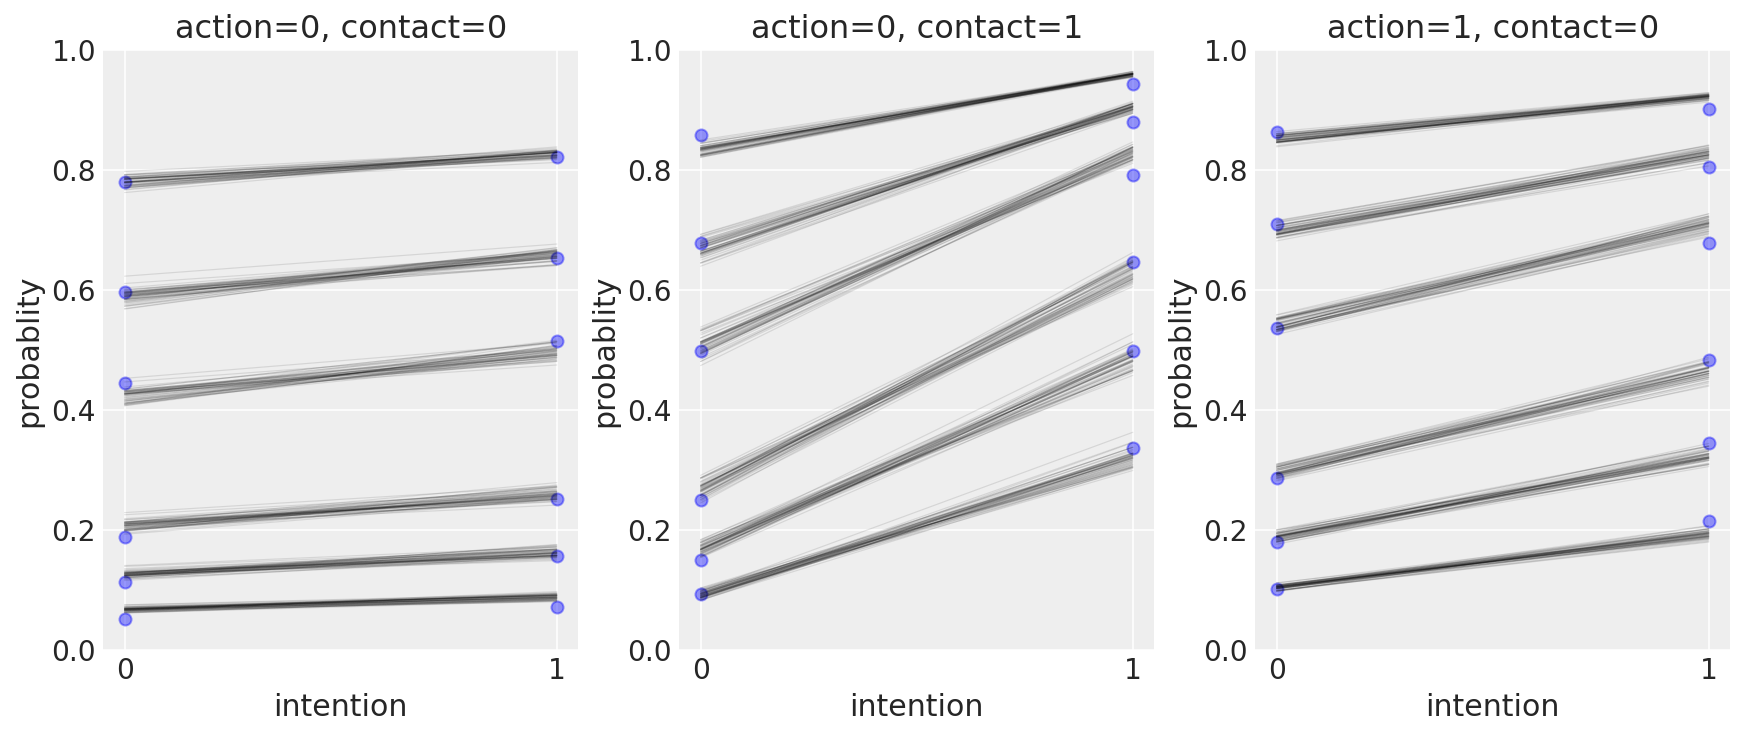

In [38]:
_, axes = plt.subplots(1, 3, figsize=(12, 5))

pp_cut_array = np.array(az.extract_dataset(trace_12_5["posterior"])["cutpoints"]).T
pp_phi_array = np.array(az.extract_dataset(pp_phi)["phi"]).T

for s in range(50):
    p = p_ord_logit(responses=range(6), phi=pp_phi_array[s], a=pp_cut_array[s])

    cur_ax = 0
    for (action, contact), _ in p.groupby(level=["action", "contact"]):
        axes[cur_ax].plot([0, 1], p.loc[action, contact], lw=0.6, c="k", alpha=0.1)

        if s == 0:
            axes[cur_ax].plot([0, 1], p_obs.loc[action, contact], "ob", alpha=0.4)
            axes[cur_ax].set_xticks([0, 1])
            axes[cur_ax].set_xlabel("intention")
            axes[cur_ax].set_ylabel("probablity")
            axes[cur_ax].set_ylim([0, 1])
            axes[cur_ax].set_title(f"action={action}, contact={contact}")

        cur_ax += 1

#### Code 12.29

In [39]:
with m12_5:
    pp_resp = pm.sample_posterior_predictive(
        trace_12_5, var_names=["resp_obs"], random_seed=RANDOM_SEED
    )["posterior_predictive"]
    pp_resp_array = np.array(az.extract_dataset(pp_resp)["resp_obs"])

resp_df = pd.DataFrame(pp_resp_array)
resp_df.index.name = "case"
resp_df = (
    pd.concat([cases_df, resp_df], axis=1)
    .set_index(["action", "contact", "intention"])
    .sort_index()
)
resp_df

0     1     2     3     4     5     6     7     \
action contact intention                                                   
0      0       0             4     2     3     4     1     3     2     4   
               1             6     3     2     6     6     4     5     3   
       1       0             6     5     4     5     4     5     6     3   
               1             1     6     3     3     1     5     3     2   
1      0       0             4     6     4     6     5     4     0     0   
               1             2     3     0     0     0     3     1     2   

                          8     9     ...  3990  3991  3992  3993  3994  3995  \
action contact intention              ...                                       
0      0       0             0     4  ...     3     2     3     4     2     6   
               1             6     6  ...     5     4     4     5     1     6   
       1       0             6     3  ...     3     4     3     6     3     3   
               1             4     5  ...     1     0     0     4     3     0   
1      0       0             4     2  ...     0     6     0     0     3     5   
               1             1     0  ...     3     2     4     4     3     4   

                          3996  3997  3998  3999  
action contact intention                          
0      0       0             3     6     4     4  
               1             4     1     3     2  
       1       0             6     5     2     0  
               1             4     0     0     3  
1      0       0             2     0     3     2  
               1             1     3     0     0  

[6 rows x 4000 columns]

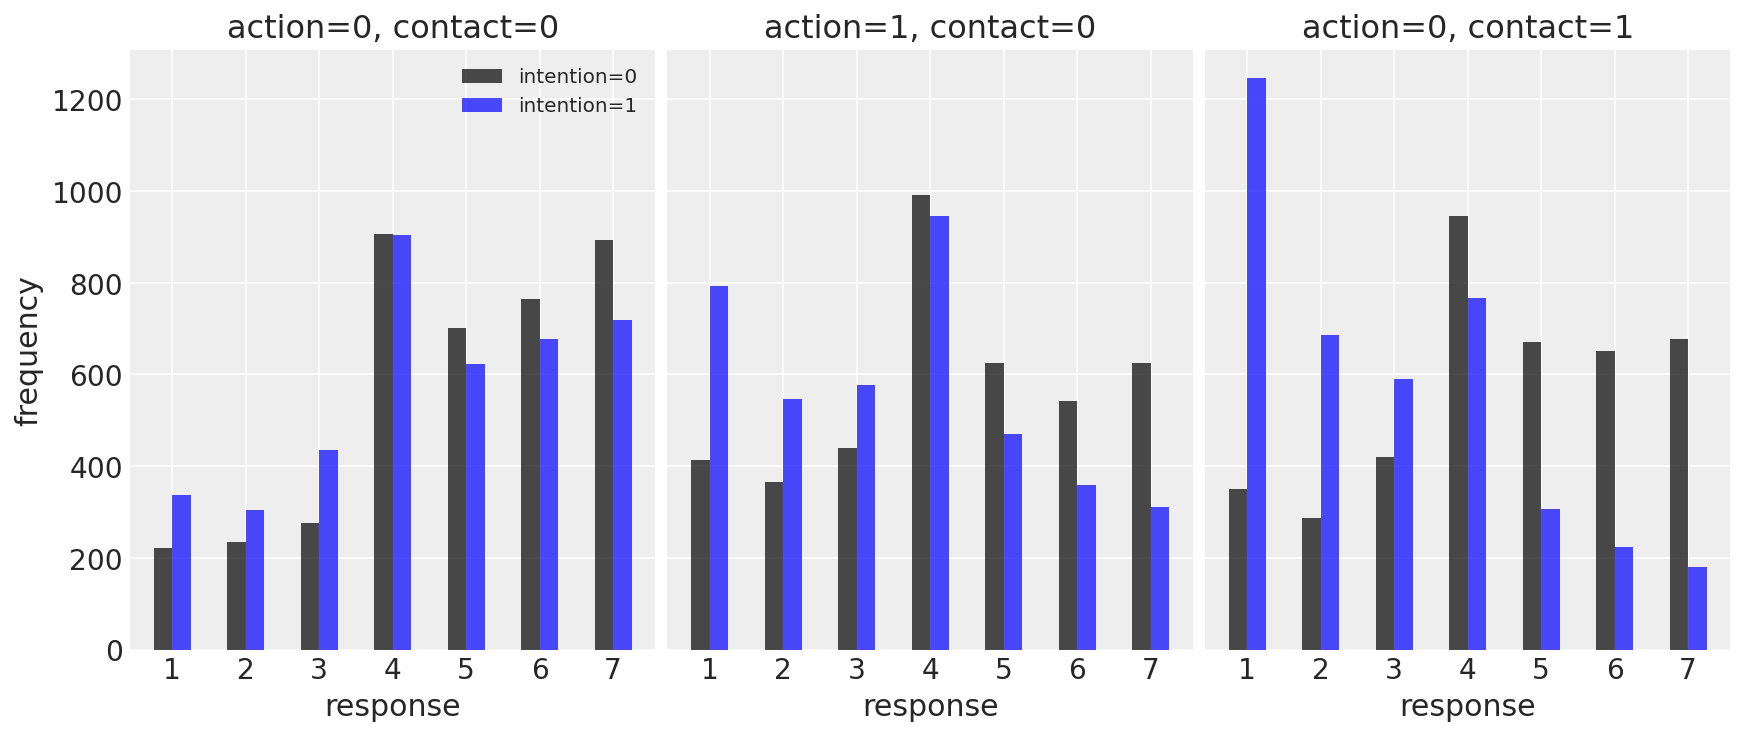

In [40]:
_, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
bins, xticks, xlabels, colors = (
    np.arange(8) - 0.5,
    np.arange(7),
    np.arange(1, 8),
    ["k", "b"],
)

axes[0].hist(
    [resp_df.loc[0, 0, 0], resp_df.loc[0, 0, 1]],
    bins=bins,
    rwidth=0.5,
    label=["intention=0", "intention=1"],
    color=colors,
    alpha=0.7,
)
axes[0].set_title("action=0, contact=0")
axes[0].set_ylabel("frequency")
axes[0].legend(fontsize=10)

axes[1].hist(
    [resp_df.loc[1, 0, 0], resp_df.loc[1, 0, 1]],
    bins=bins,
    rwidth=0.5,
    color=colors,
    alpha=0.7,
)
axes[1].set_title("action=1, contact=0")

axes[2].hist(
    [resp_df.loc[0, 1, 0], resp_df.loc[0, 1, 1]],
    bins=bins,
    rwidth=0.5,
    color=colors,
    alpha=0.7,
)
axes[2].set_title("action=0, contact=1")

for ax in axes:
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("response")

#### Code 12.30

In [41]:
pd.Categorical(trolley_df.edu)

['Middle School', 'Middle School', 'Middle School', 'Middle School', 'Middle School', ..., 'Graduate Degree', 'Graduate Degree', 'Graduate Degree', 'Graduate Degree', 'Graduate Degree']
Length: 9930
Categories (8, object): ['Bachelor's Degree', 'Elementary School', 'Graduate Degree', 'High School Graduate', 'Master's Degree', 'Middle School', 'Some College', 'Some High School']

#### Code 12.31

In [42]:
trolley_df["edu_new"] = pd.Categorical(
    trolley_df.edu.values,
    categories=[
        "Elementary School",
        "Middle School",
        "Some High School",
        "High School Graduate",
        "Some College",
        "Bachelor's Degree",
        "Master's Degree",
        "Graduate Degree",
    ],
    ordered=True,
)
trolley_df["edu_new"] = trolley_df.edu_new.cat.codes

#### Code 12.32

In [43]:
delta = np.random.dirichlet(np.repeat(2.0, 7), size=10)

#### Code 12.33

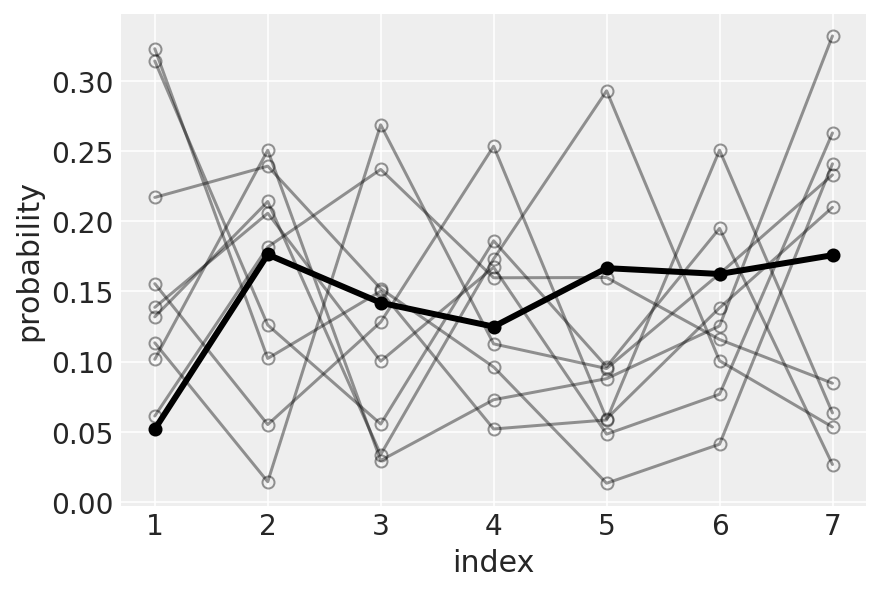

In [44]:
plt.plot(np.stack([range(1, 8)] * 9).T, delta[1:].T, "-ok", alpha=0.4, fillstyle="none")
plt.plot(np.arange(1, 8).T, delta[0].T, "-ok", lw=3, ms=6)
plt.xlabel("index")
plt.ylabel("probability");

#### Code 12.34

In [45]:
R = trolley_df.response.values - 1
A = trolley_df.action.values
I = trolley_df.intention.values
C = trolley_df.contact.values
E = trolley_df.edu_new.values

with pm.Model() as m12_6:
    kappa = pm.Normal(
        "kappa",
        0.0,
        1.5,
        transform=pm.distributions.transforms.ordered,
        shape=6,
        testval=np.arange(6),
    )

    bA = pm.Normal("bA", 0.0, 0.5)
    bC = pm.Normal("bC", 0.0, 0.5)
    bI = pm.Normal("bI", 0.0, 0.5)
    bE = pm.Normal("bE", 0.0, 0.5)

    delta = pm.Dirichlet("delta", np.repeat(2.0, 7), shape=7)
    delta_j = at.concatenate([at.zeros(1), delta])
    delta_j_cumulative = at.cumsum(delta_j)

    phi = bE * delta_j_cumulative[E] + bA * A + bC * C + bI * I

    resp_obs = pm.OrderedLogistic("resp_obs", phi, kappa, observed=R)

    trace_12_6 = pm.sample(2000, tune=2000, target_accept=0.9, random_seed=RANDOM_SEED)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, bA, bC, bI, bE, delta]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1770 seconds.


#### Code 12.35

In [46]:
az.summary(trace_12_6, var_names=["bA", "bC", "bI", "bE", "delta"], round_to=2)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bA,-0.70,0.04,-0.76,-0.63,0.0,0.0,8102.76,6265.24,1.0
bC,-0.95,0.05,-1.03,-0.87,0.0,0.0,7016.29,5730.33,1.0
bI,-0.72,0.04,-0.77,-0.66,0.0,0.0,8693.16,5556.96,1.0
bE,-0.29,0.16,-0.53,-0.04,0.0,0.0,2703.89,3302.38,1.0
delta[0],0.21,0.13,0.02,0.40,0.0,0.0,4665.44,4528.65,1.0
delta[1],0.14,0.09,0.01,0.26,0.0,0.0,7671.51,4829.84,1.0
delta[2],0.19,0.11,0.02,0.35,0.0,0.0,9329.34,4829.37,1.0
delta[3],0.17,0.10,0.02,0.31,0.0,0.0,6856.20,4569.43,1.0
delta[4],0.05,0.06,0.00,0.09,0.0,0.0,3941.73,3297.45,1.0
delta[5],0.10,0.07,0.01,0.19,0.0,0.0,5253.69,4003.92,1.0


#### Code 12.36

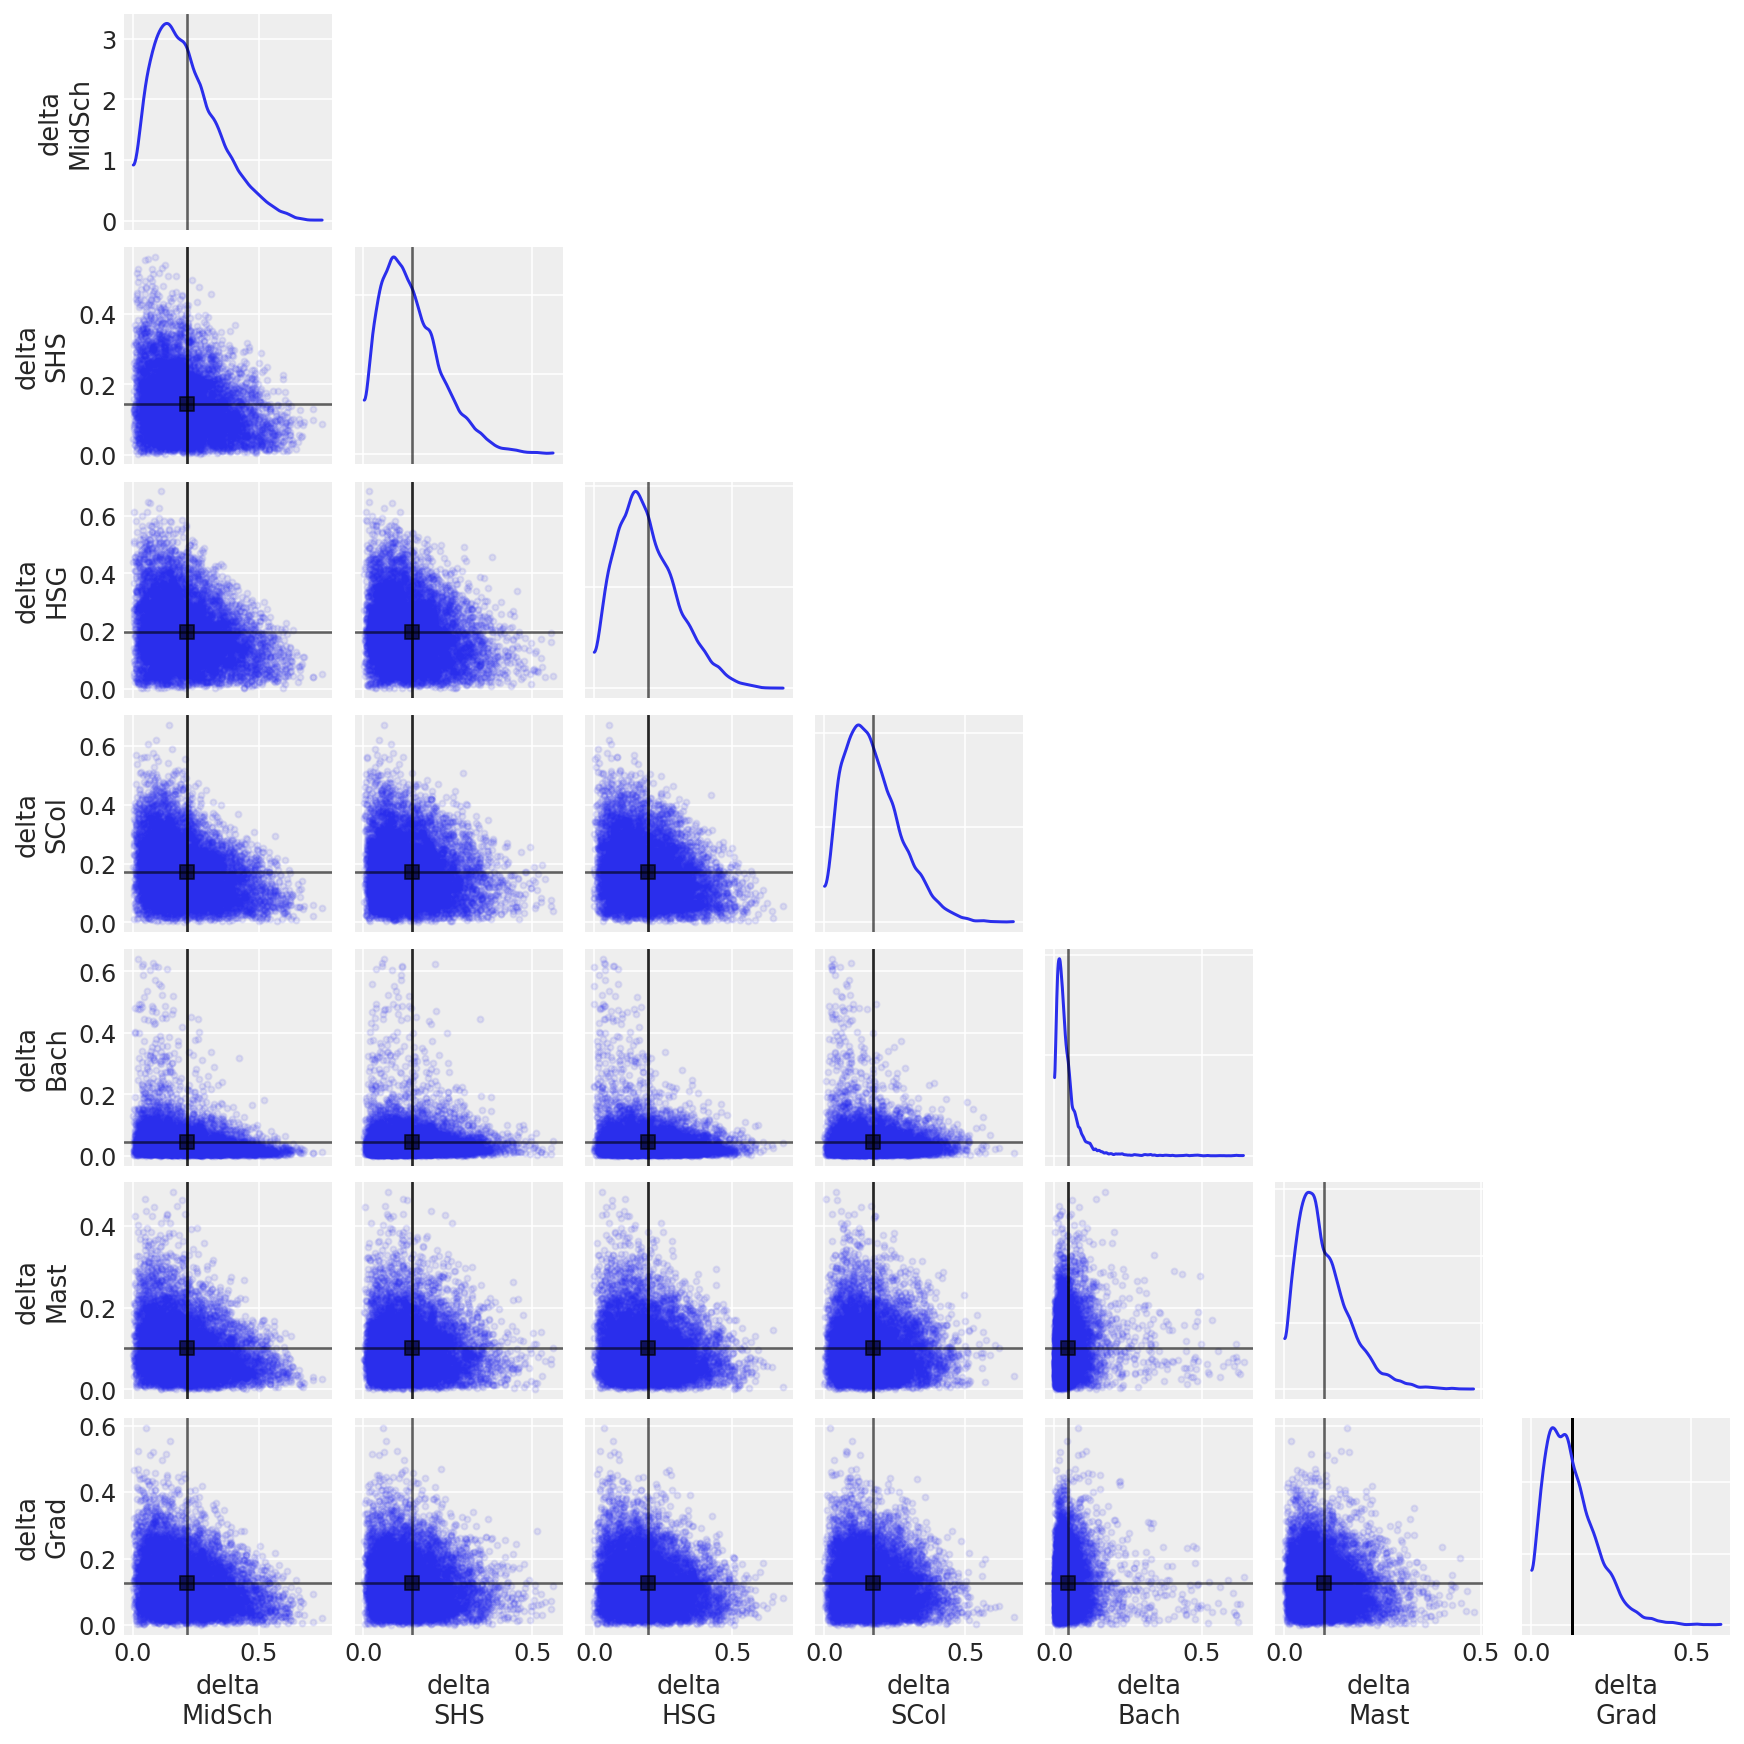

In [47]:
trace_12_6.posterior.coords["delta_dim_0"] = [
    "MidSch",
    "SHS",
    "HSG",
    "SCol",
    "Bach",
    "Mast",
    "Grad",
]

az.plot_pair(
    trace_12_6,
    var_names=["delta"],
    marginals=True,
    point_estimate="mean",
    textsize=12,
    figsize=(12, 12),
    scatter_kwargs={"alpha": 0.1},
    point_estimate_kwargs={"alpha": 0.6, "lw": 1.3},
    point_estimate_marker_kwargs={"alpha": 0.6},
);

#### Code 12.37

In [48]:
edu_norm = (
    (trolley_df.edu_new - trolley_df.edu_new.min())
    / (trolley_df.edu_new.max() - trolley_df.edu_new.min())
).values

with pm.Model() as m12_7:
    cutpoints = pm.Normal(
        "cutpoints",
        0.0,
        1.5,
        transform=pm.distributions.transforms.ordered,
        shape=6,
        testval=np.arange(6) - 2.5,
    )

    bA = pm.Normal("bA", 0.0, 0.5)
    bC = pm.Normal("bC", 0.0, 0.5)
    bI = pm.Normal("bI", 0.0, 0.5)
    bE = pm.Normal("bE", 0.0, 0.5)

    phi = bE * edu_norm + bA * A + bC * C + bI * I

    resp_obs = pm.OrderedLogistic("resp_obs", phi, cutpoints, observed=R)

    trace_12_7 = pm.sample(random_seed=RANDOM_SEED)
az.summary(trace_12_7, var_names=["bA", "bC", "bI", "bE"], round_to=2)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints, bA, bC, bI, bE]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 411 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bA,-0.70,0.04,-0.77,-0.64,0.0,0.0,3987.58,3147.06,1.0
bC,-0.95,0.05,-1.03,-0.87,0.0,0.0,4005.63,3292.93,1.0
bI,-0.72,0.04,-0.77,-0.66,0.0,0.0,4443.75,2855.88,1.0
bE,-0.10,0.09,-0.23,0.05,0.0,0.0,4592.98,2697.49,1.0


12M3.  Can you modify the derivation of the zero-inflated Poisson distribution (ZIPoisson) from the chapter to construct a zero-inflated binomial distribution?

## 🧮 Derivation of the Zero-Inflated Binomial (ZIBinomial) Distribution

We want to model a process where:

- With probability \( \pi \), the outcome is always zero (e.g., the monk was too drunk to try).
- With probability \( 1 - \pi \), the outcome is generated from a Binomial process with parameters \( n \) and \( \theta \).

---

### ✅ 1. Binomial Likelihood Recap

$$
P(y \mid n, \theta) = \binom{n}{y} \theta^y (1 - \theta)^{n - y}
$$

---

### ✅ 2. Zero-Inflation Logic

Let:

- \( \pi \): probability of a structural zero  
- \( \theta \): probability of success in the Binomial component  
- \( n \): number of trials  

Then:

#### For \( y = 0 \):

There are two ways to observe zero:

1. Structural zero (e.g., didn’t try): probability \( \pi \)  
2. Tried but got 0 successes: \( (1 - \pi)(1 - \theta)^n \)

$$
P(y = 0 \mid n, \pi, \theta) = \pi + (1 - \pi)(1 - \theta)^n
$$

#### For \( y > 0 \):

Only from the Binomial process:

$$
P(y = k \mid n, \pi, \theta) = (1 - \pi) \cdot \binom{n}{k} \theta^k (1 - \theta)^{n - k}, \quad k > 0
$$

---

### ✅ 3. Final ZIBinomial Likelihood

$$
P(y \mid n, \pi, \theta) =
\begin{cases}
\pi + (1 - \pi)(1 - \theta)^n, & \text{if } y = 0 \\
(1 - \pi) \cdot \binom{n}{y} \theta^y (1 - \theta)^{n - y}, & \text{if } y > 0
\end{cases}
$$

---

### ✅ 4. Regression Form (GLM)

You can model both parameters with predictors:

$$
\text{logit}(\pi_i) = \alpha + \beta x_i
$$

$$
\text{logit}(\theta_i) = \gamma + \delta x_i
$$

Then:

$$
y_i \sim \text{ZIBinomial}(n_i, \pi_i, \theta_i)
$$

---

### 📦 Summary

| Parameter     | Meaning                                      |
|---------------|----------------------------------------------|
| \( \pi \)     | Probability of structural (inflated) zero    |
| \( \theta \)  | Success probability in the binomial process  |
| \( n \)       | Number of trials                             |


with pm.Model() as zib_model:
    alpha_pi = pm.Normal("alpha_pi", 0, 1)
    beta_pi = pm.Normal("beta_pi", 0, 1)
    alpha_theta = pm.Normal("alpha_theta", 0, 1)
    beta_theta = pm.Normal("beta_theta", 0, 1)

    logit_pi = alpha_pi + beta_pi * x
    logit_theta = alpha_theta + beta_theta * x

    pi = pm.Deterministic("pi", pm.math.sigmoid(logit_pi))
    theta = pm.Deterministic("theta", pm.math.sigmoid(logit_theta))

    # Custom Zero-Inflated Binomial
    def ZIBinomial(name, n, pi, theta, observed):
        zero_probs = pi + (1 - pi) * (1 - theta) ** n
        binom_probs = pm.Binomial.dist(n=n, p=theta).logp(observed)
        like = pm.math.switch(pm.math.eq(observed, 0), pm.math.log(zero_probs), pm.math.log(1 - pi) + binom_probs)
        return pm.Potential(name, like)

    ZIBinomial("obs", n=n, pi=pi, theta=theta, observed=y_obs)

12H1.  In 2014, a paper was published that was entitled “Female hurricanes are deadlier than male hurricanes.”191 As the title suggests, the paper claimed that hurricanes with female names have caused greater loss of life, and the explanation given is that people unconsciously rate female hurricanes as less dangerous and so are less likely to evacuate. Statisticians severely criticized the paper after publication. Here, you’ll explore the complete data used in the paper and consider the hypothesis that hurricanes with female names are deadlier. Load the data with:

R code 12.38

library(rethinking)

data(Hurricanes)

Acquaint yourself with the columns by inspecting the help ?Hurricanes. In this problem, you’ll focus on predicting deaths using femininity of each hurricane’s name. Fit and interpret the simplest possible model, a Poisson model of deaths using femininity as a predictor. You can use quap or ulam. Compare the model to an intercept-only Poisson model of deaths. How strong is the association between femininity of name and deaths? Which storms does the model fit (retrodict) well? Which storms does it fit poorly?

In [18]:
df_hurricane=pd.read_csv('End_of_chapter_problems/data/Hurricanes.csv', sep=';')
df_hurricane.shape

(92, 8)

In [19]:
df_hurricane.head()

,name,year,deaths,category,min_pressure,damage_norm,female,femininity
0,Easy,1950,2,3,960,1590,1,6.77778
1,King,1950,4,3,955,5350,0,1.38889
2,Able,1952,3,1,985,150,0,3.83333
3,Barbara,1953,1,1,987,58,1,9.83333
4,Florence,1953,0,1,985,15,1,8.33333


<Axes: >

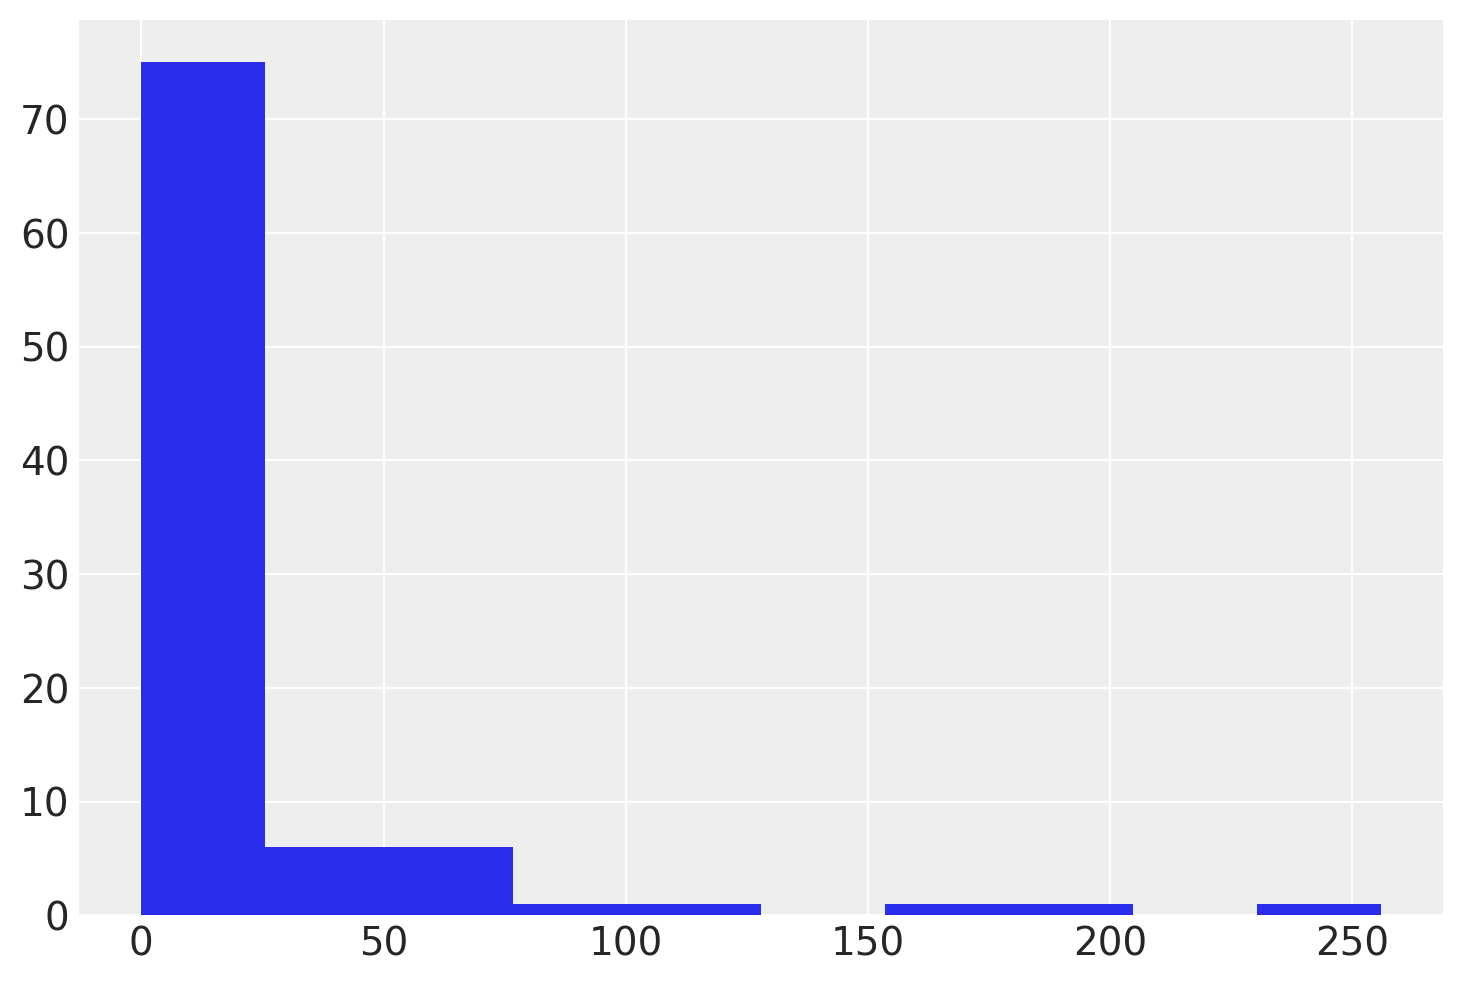

In [20]:
df_hurricane.deaths.hist()

Text(0, 0.5, 'feminity')

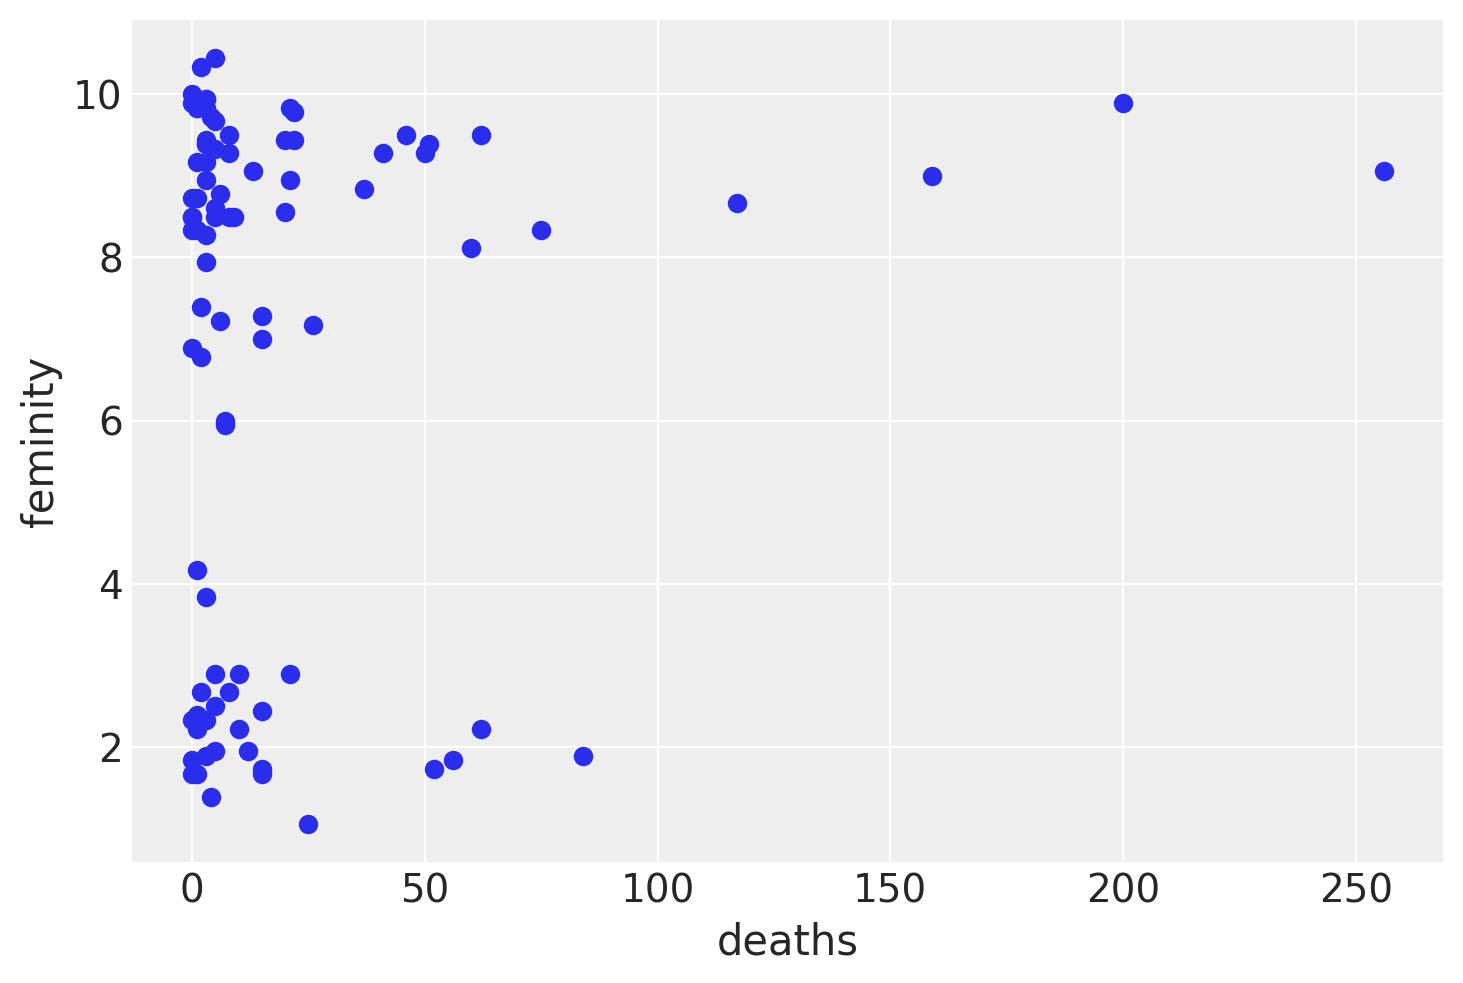

In [23]:
plt.scatter(df_hurricane.deaths, df_hurricane.femininity)
plt.xlabel('deaths')
plt.ylabel('feminity')

Text(0, 0.5, 'feminity log')

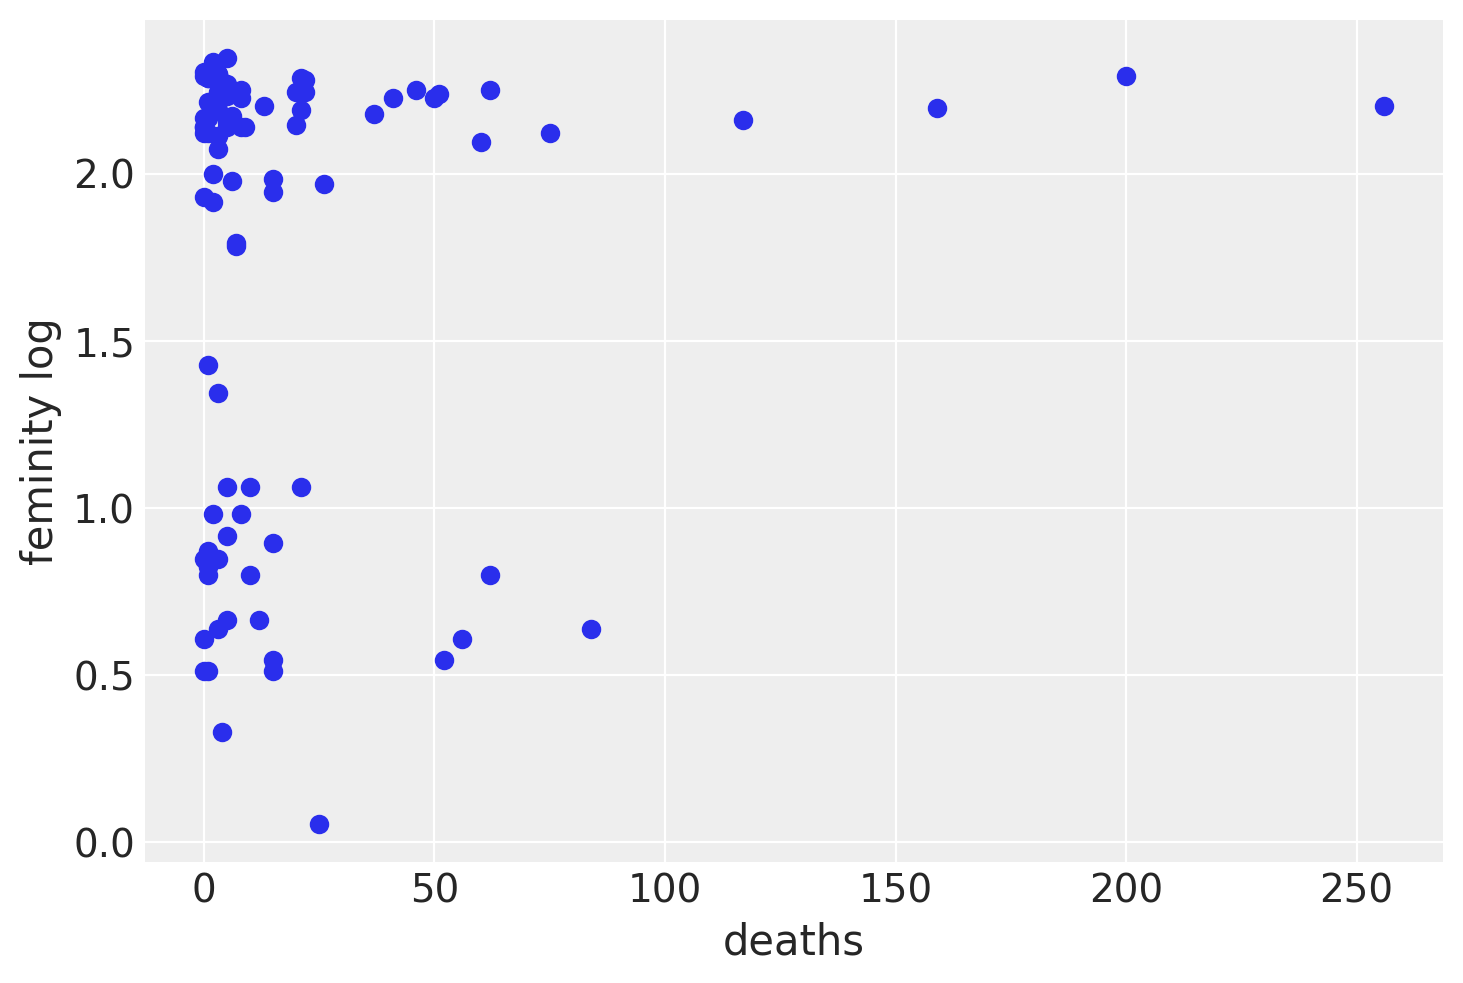

In [27]:
plt.scatter(df_hurricane.deaths, np.log(df_hurricane.femininity))
plt.xlabel('deaths')
plt.ylabel('feminity log')

C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0, 0.5, 'feminity')

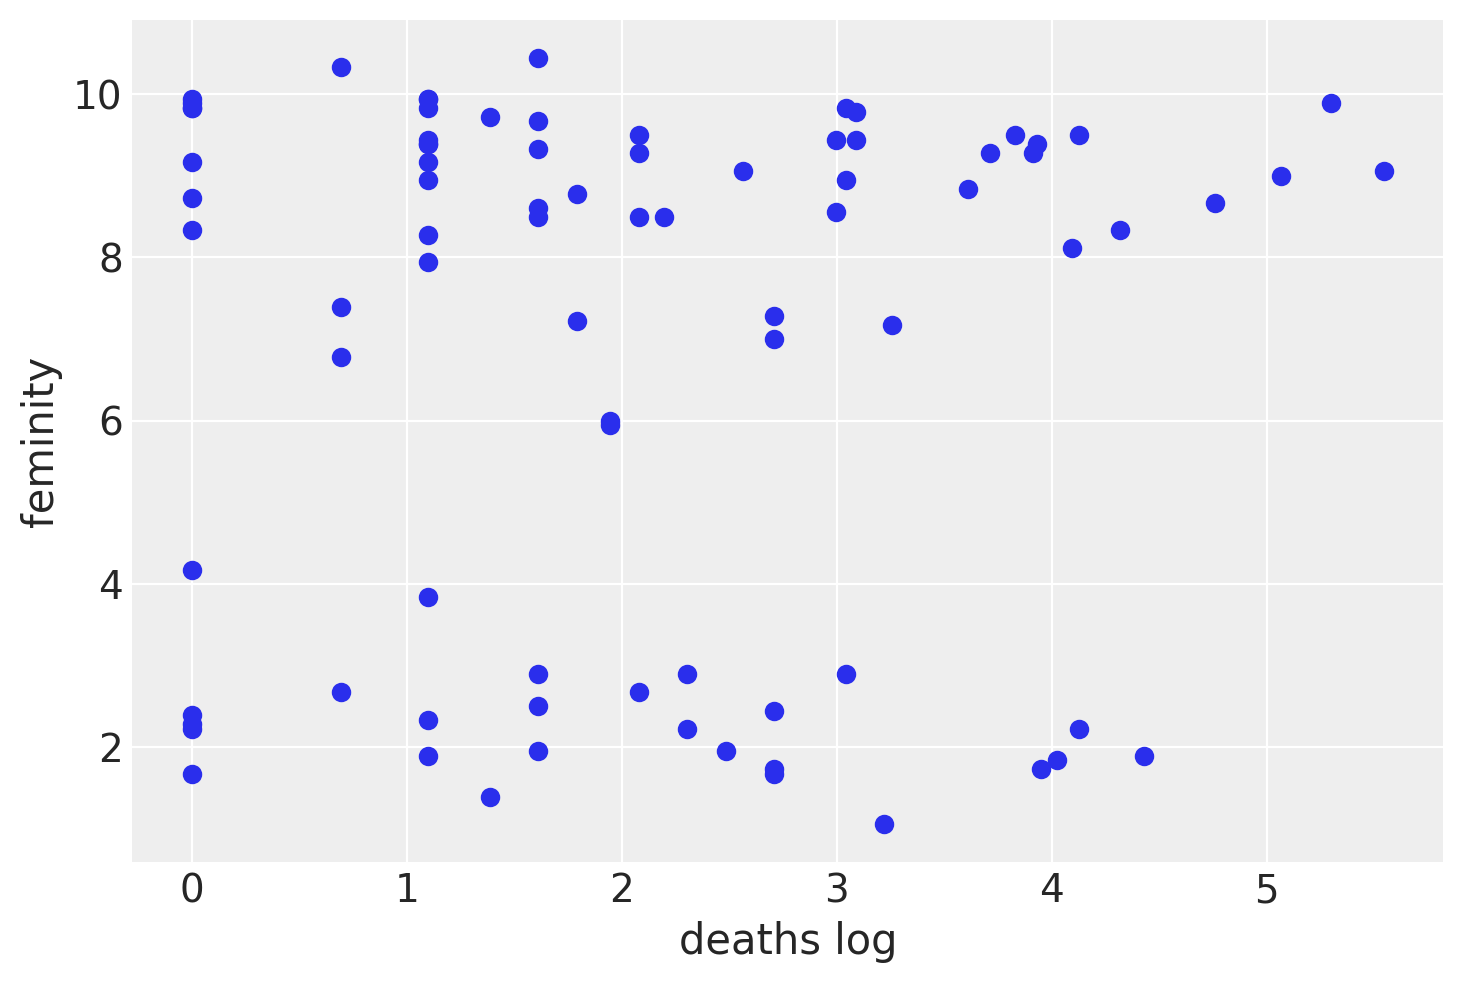

In [28]:
plt.scatter(np.log(df_hurricane.deaths), df_hurricane.femininity)
plt.xlabel('deaths log')
plt.ylabel('feminity')

In [24]:
df_hurricane

,name,year,deaths,category,min_pressure,damage_norm,female,femininity
0,Easy,1950,2,3,960,1590,1,6.77778
1,King,1950,4,3,955,5350,0,1.38889
2,Able,1952,3,1,985,150,0,3.83333
3,Barbara,1953,1,1,987,58,1,9.83333
4,Florence,1953,0,1,985,15,1,8.33333
...,...,...,...,...,...,...,...,...
87,Gustav,2008,52,2,954,4360,0,1.72222
88,Ike,2008,84,2,950,20370,0,1.88889
89,Irene,2011,41,1,952,7110,1,9.27778
90,Isaac,2012,5,1,966,24000,0,1.94444


In [40]:
with pm.Model() as m_hurricane:
    a = pm.Normal("a", 0.0, 1.0)
    b_feminity = pm.Normal("b_feminity", 0.0, 1.0) 
    femininity = pm.Data("femininity", df_hurricane.femininity)
    eta = a + b_feminity * femininity
    lam = pm.math.exp(eta)

    deaths = pm.Poisson("deaths", lam, observed=df_hurricane.deaths)

    trace_m_hurricane = pm.sample(2000, tune=2000, target_accept=0.9, random_seed=RANDOM_SEED,
                           return_inferencedata=True,
    idata_kwargs={"log_likelihood": True})

# store pareto-k values for plot:
k_m_hurricane = az.loo(trace_m_hurricane, pointwise=True).pareto_k.values

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b_feminity]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 323 seconds.
C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\arviz\stats\stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [44]:
az.summary(trace_m_hurricane)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,2.494,0.061,2.397,2.594,0.002,0.001,1517.0,1773.0,1.0
b_feminity,0.075,0.008,0.062,0.086,0.000,0.000,1546.0,2036.0,1.0


In [45]:
np.exp(0.075)

np.float64(1.0778841508846315)

For each one-unit increase in femininity, the expected number of deaths increases by about 7.8%.

array([[<Axes: title={'center': 'a'}>, <Axes: title={'center': 'a'}>],
       [<Axes: title={'center': 'b_feminity'}>,
        <Axes: title={'center': 'b_feminity'}>]], dtype=object)

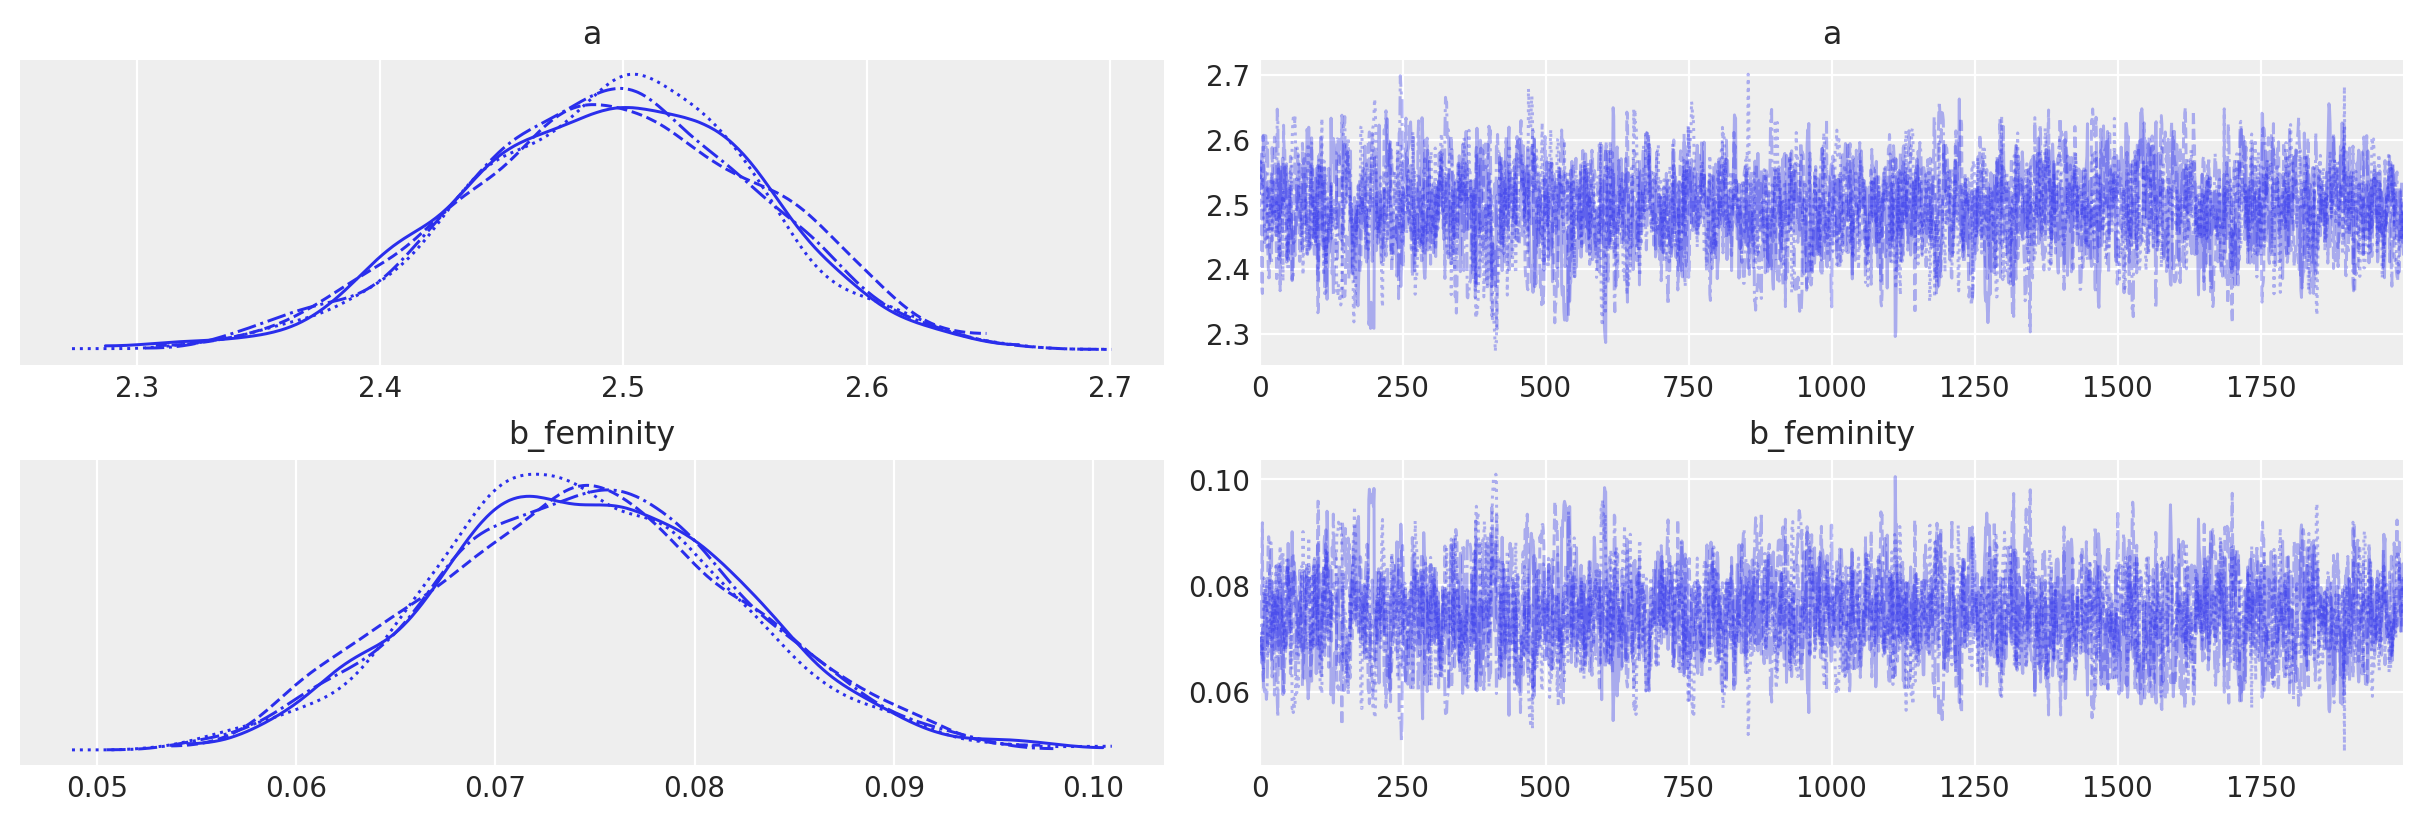

In [46]:
az.plot_trace(trace_m_hurricane)

In [47]:
with pm.Model() as m_hurricane_simplest:
    a = pm.Normal("a", 0.0, 1.0)
    eta = a 
    lam = pm.math.exp(eta)

    deaths = pm.Poisson("deaths", lam, observed=df_hurricane.deaths)

    trace_m_hurricane_simplest = pm.sample(2000, tune=2000, target_accept=0.9, random_seed=RANDOM_SEED,
                           return_inferencedata=True,
    idata_kwargs={"log_likelihood": True})


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 68 seconds.


In [49]:
az.summary(trace_m_hurricane_simplest)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,3.025,0.023,2.988,3.061,0.0,0.0,3063.0,4521.0,1.0


array([[<Axes: title={'center': 'a'}>, <Axes: title={'center': 'a'}>]],
      dtype=object)

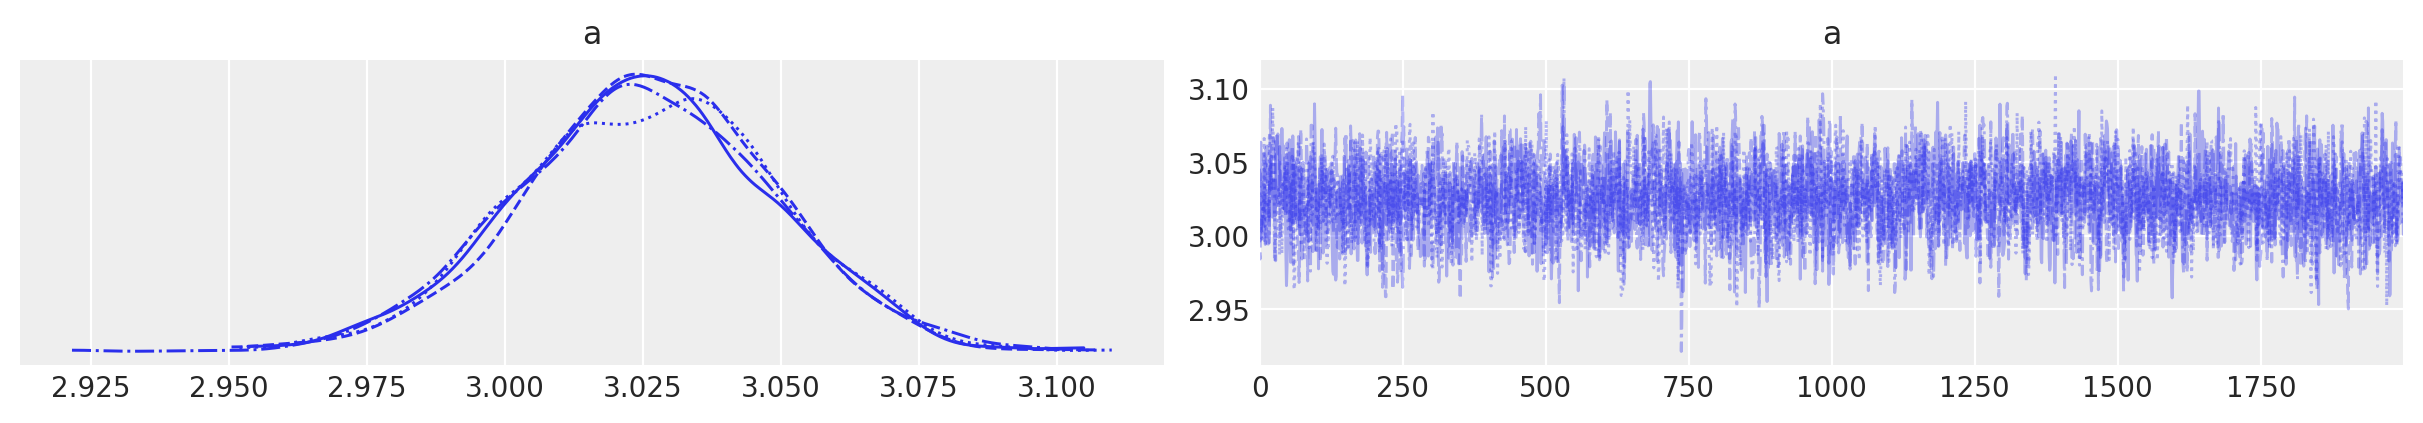

In [50]:
az.plot_trace(trace_m_hurricane_simplest)

In [51]:
az.loo(trace_m_hurricane_simplest)

C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 92 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2219.76   535.19
p_loo       76.86        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       88   95.7%
   (0.70, 1]   (bad)         1    1.1%
   (1, Inf)   (very bad)    3    3.3%

In [52]:
az.loo(trace_m_hurricane)

C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\arviz\stats\stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 92 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2193.67   491.98
p_loo      113.02        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       86   93.5%
   (0.70, 1]   (bad)         2    2.2%
   (1, Inf)   (very bad)    4    4.3%

In [53]:
np.exp(3.025), np.exp(2.494)

(np.float64(20.59400471119603), np.float64(12.109617843917832))

base rates are different and inflated, mean deaths are not so high

In [55]:
ppc = pm.sample_posterior_predictive(trace_m_hurricane, model=m_hurricane)

Sampling: [deaths]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\risto\AppData\Local\Temp\ipykernel_22012\512351178.py:29: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


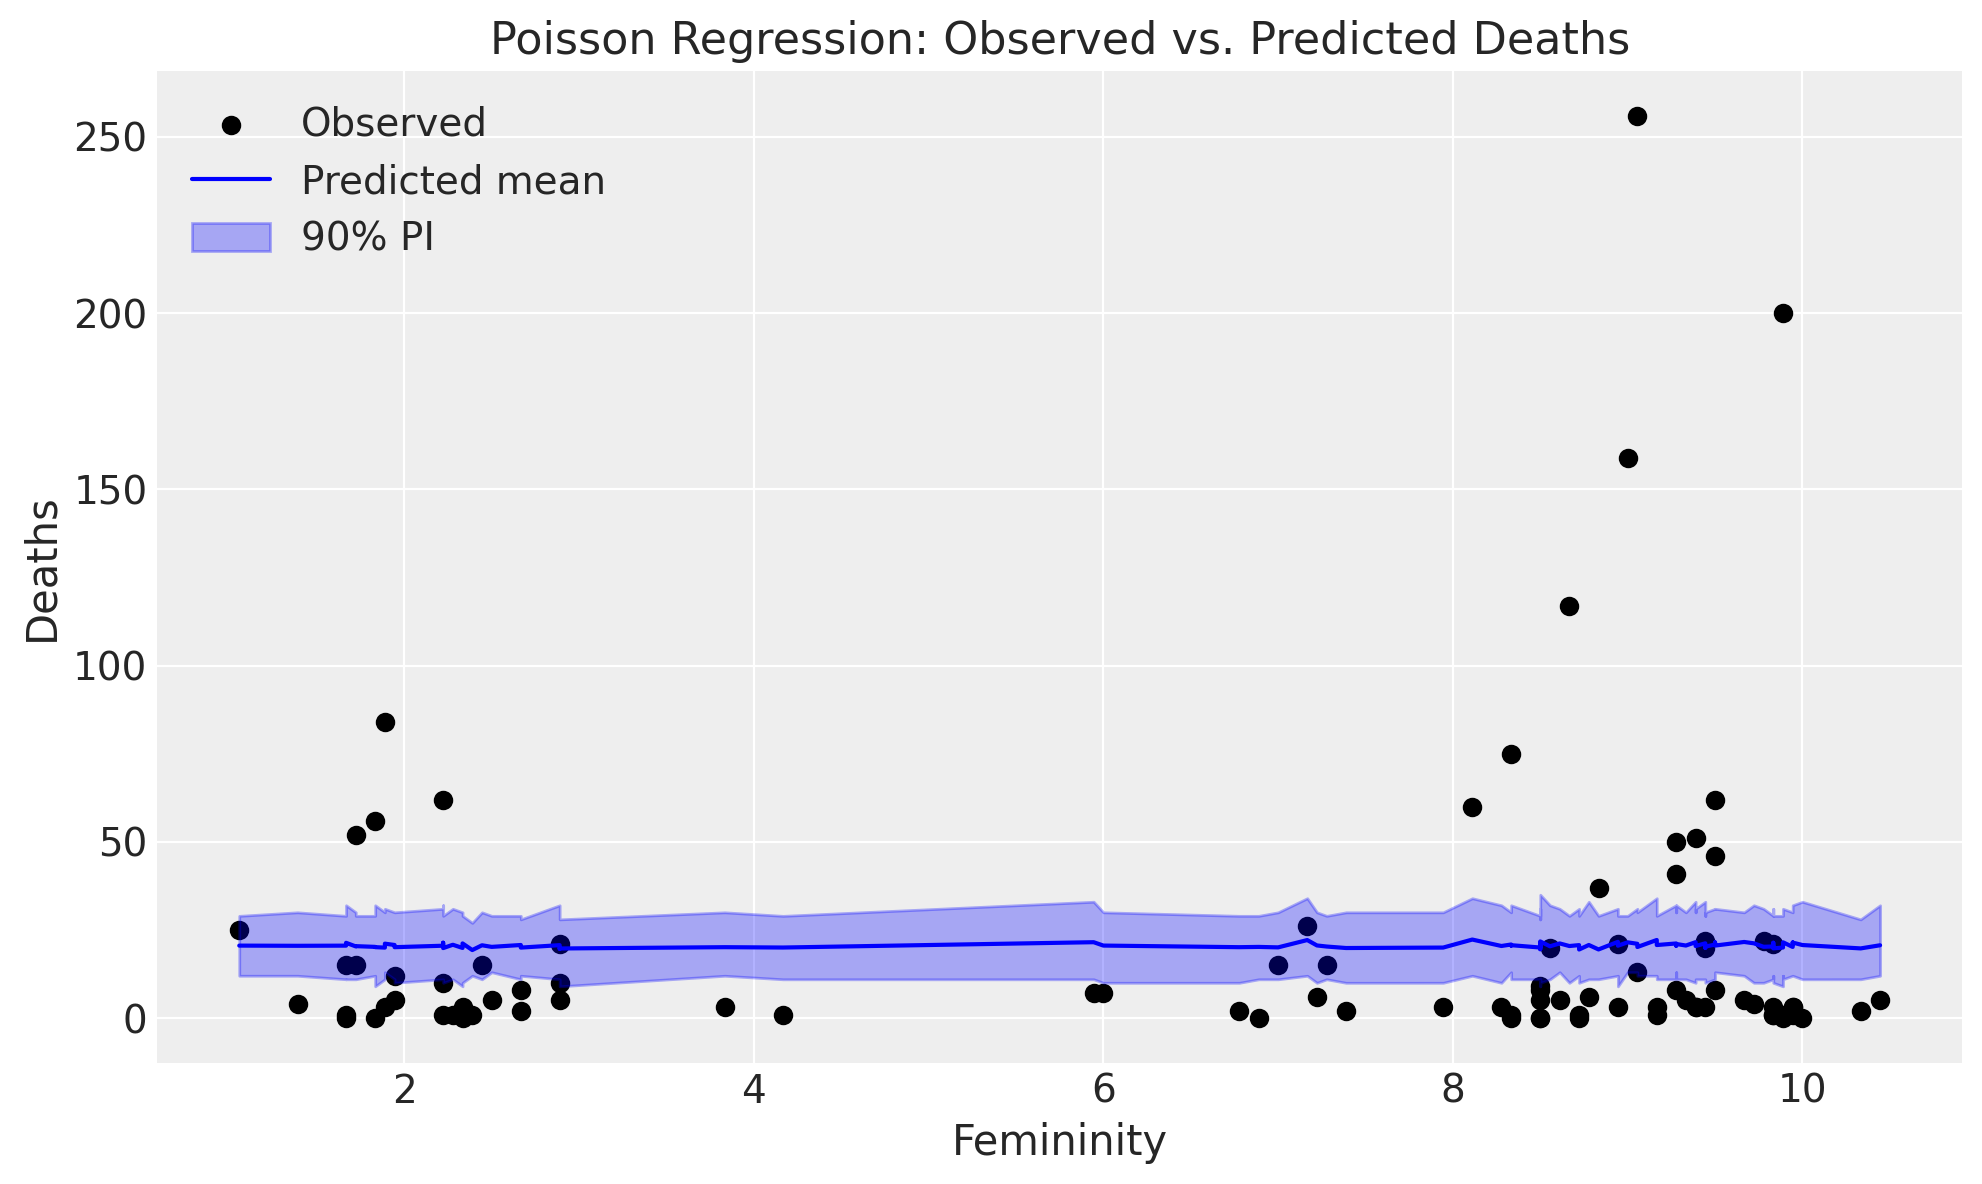

In [59]:
# Get the posterior predictive samples
y_preds = ppc.posterior_predictive["deaths"]  # shape: (chain, draw, N)
y_pred_samples = y_preds.stack(sample=("chain", "draw")).values.T  # shape: (N, samples)

# Compute mean and 90% intervals
y_pred_mean = np.mean(y_pred_samples, axis=1)
y_pred_lower = np.percentile(y_pred_samples, 5.5, axis=1)
y_pred_upper = np.percentile(y_pred_samples, 94.5, axis=1)

# Sort by femininity for cleaner plotting (optional)
sort_idx = np.argsort(df_hurricane.femininity.values)
x_sorted = df_hurricane.femininity.values[sort_idx]
y_obs_sorted = df_hurricane.deaths.values[sort_idx]
y_mean_sorted = y_pred_mean[sort_idx]
y_lower_sorted = y_pred_lower[sort_idx]
y_upper_sorted = y_pred_upper[sort_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x_sorted, y_obs_sorted, color='black', label='Observed')
plt.plot(x_sorted, y_mean_sorted, color='blue', label='Predicted mean')
plt.fill_between(x_sorted, y_lower_sorted, y_upper_sorted, color='blue', alpha=0.3, label='90% PI')

plt.xlabel("Femininity")
plt.ylabel("Deaths")
plt.title("Poisson Regression: Observed vs. Predicted Deaths")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

12H2.  Counts are nearly always over-dispersed relative to Poisson. So fit a gamma-Poisson (aka negative-binomial) model to predict deaths using femininity. Show that the over-dispersed model no longer shows as precise a positive association between femininity and deaths, with an 89% interval that overlaps zero. Can you explain why the association diminished in strength?

In [73]:
df_hurricane["femininity_std"] = (df_hurricane.femininity - df_hurricane.femininity.mean()) / df_hurricane.femininity.std()
df_hurricane["damage_norm_std"] = (df_hurricane.damage_norm - df_hurricane.damage_norm.mean()) / df_hurricane.damage_norm.std()
df_hurricane["min_pressure_std"] = (df_hurricane.min_pressure - df_hurricane.min_pressure.mean()) / df_hurricane.min_pressure.std()

In [69]:
with pm.Model() as m_hurricane_negbin:
    a = pm.Normal("a", 0.0, 1.0)
    b_feminity = pm.Normal("b_feminity", 0.0, 1.0) 
    femininity = pm.Data("femininity", df_hurricane.femininity_std)
    alpha=pm.Exponential("alpha", 1.0)
    eta = a + b_feminity * femininity
    lam = pm.math.exp(eta)

    deaths = pm.NegativeBinomial("deaths", lam, alpha=alpha, observed=df_hurricane.deaths)

    trace_m_hurricane_negbin = pm.sample(cores =4, random_seed=RANDOM_SEED,
                           return_inferencedata=True,
    idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b_feminity, alpha]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 262 seconds.


In [70]:
az.summary(trace_m_hurricane_negbin)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,2.952,0.151,2.718,3.193,0.002,0.002,4689.0,3106.0,1.0
b_feminity,0.208,0.154,-0.035,0.454,0.002,0.002,5406.0,2929.0,1.0
alpha,0.453,0.066,0.350,0.553,0.001,0.001,5090.0,3051.0,1.0


In [71]:
np.exp(-0.035), np.exp(0.454)

(np.float64(0.9656054162575665), np.float64(1.5745979974750188))

array([[<Axes: title={'center': 'a'}>, <Axes: title={'center': 'a'}>],
       [<Axes: title={'center': 'b_feminity'}>,
        <Axes: title={'center': 'b_feminity'}>],
       [<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>]], dtype=object)

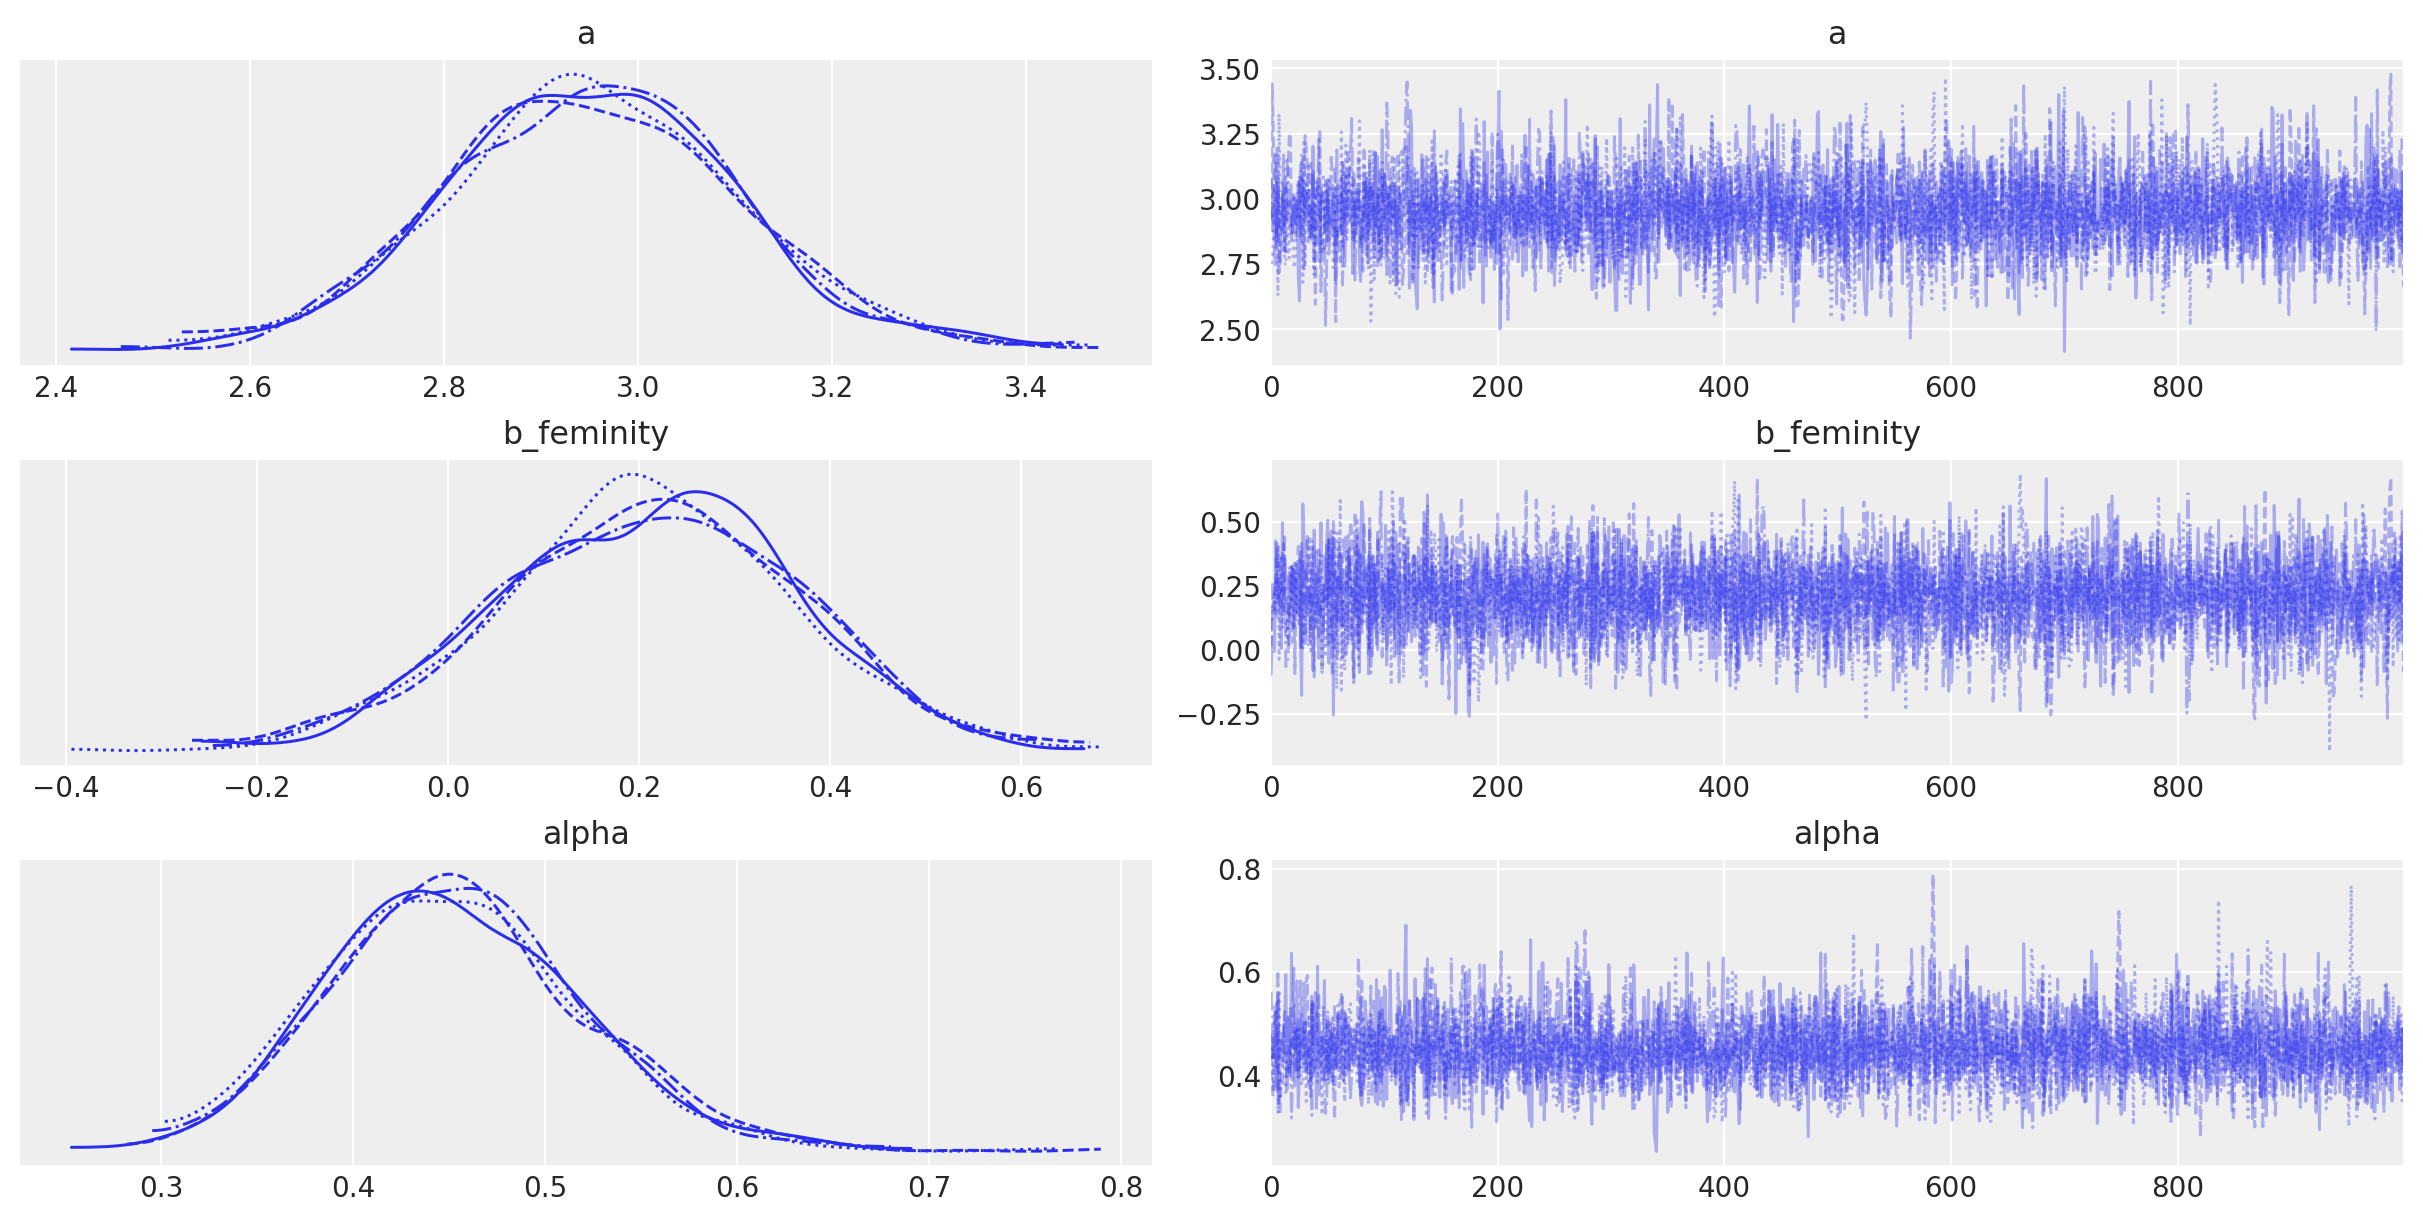

In [72]:
az.plot_trace(trace_m_hurricane_negbin)

In the Poisson model, all variability in deaths must be explained by femininity, inflating the association. The Negative Binomial model allows for extra noise (overdispersion), so it no longer needs femininity to stretch to fit every outlier. As a result, the apparent relationship weakens and becomes statistically uncertain.

12H3.  In the data, there are two measures of a hurricane’s potential to cause death: damage_norm and min_pressure. Consult ?Hurricanes for their meanings. It makes some sense to imagine that femininity of a name matters more when the hurricane is itself deadly. This implies an interaction between femininity and either or both of damage_norm and min_pressure. Fit a series of models evaluating these interactions. Interpret and compare the models. In interpreting the estimates, it may help to generate counterfactual predictions contrasting hurricanes with masculine and feminine names. Are the effect sizes plausible?

In [74]:
with pm.Model() as m_hurricane_negbin_damage:
    a = pm.Normal("a", 0.0, 1.0)
    b_feminity = pm.Normal("b_feminity", 0.0, 1.0) 
    b_damage = pm.Normal("b_damage", 0.0, 1.0) 
    b_damage_feminity= pm.Normal("b_damage_feminity", 0.0, 1.0) 
    
    femininity = pm.Data("femininity", df_hurricane.femininity_std)
    damage = pm.Data("damage", df_hurricane.damage_norm_std)
    alpha=pm.Exponential("alpha", 1.0)
    
    eta = a + b_feminity * femininity + b_damage* damage + b_damage_feminity* damage*femininity
    lam = pm.math.exp(eta)

    deaths = pm.NegativeBinomial("deaths", lam, alpha=alpha, observed=df_hurricane.deaths)

    trace_m_hurricane_negbin_damage = pm.sample(cores =4, random_seed=RANDOM_SEED,
                           return_inferencedata=True,
    idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b_feminity, b_damage, b_damage_feminity, alpha]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 389 seconds.


In [76]:
az.summary(trace_m_hurricane_negbin_damage)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,2.553,0.133,2.344,2.767,0.002,0.002,3637.0,2956.0,1.0
b_feminity,0.086,0.127,-0.115,0.282,0.002,0.002,3999.0,2885.0,1.0
b_damage,1.243,0.209,0.925,1.594,0.004,0.003,3343.0,2977.0,1.0
b_damage_feminity,0.307,0.198,0.007,0.633,0.003,0.003,3551.0,2823.0,1.0
alpha,0.684,0.102,0.514,0.834,0.002,0.002,3644.0,2948.0,1.0


In [75]:
with pm.Model() as m_hurricane_negbin_pressure:
    a = pm.Normal("a", 0.0, 1.0)
    b_feminity = pm.Normal("b_feminity", 0.0, 1.0) 
    b_pressure = pm.Normal("b_pressure", 0.0, 1.0) 
    b_pressure_feminity= pm.Normal("b_pressure_feminity", 0.0, 1.0) 
    
    femininity = pm.Data("femininity", df_hurricane.femininity_std)
    pressure = pm.Data("min_pressure", df_hurricane.min_pressure_std)
    alpha=pm.Exponential("alpha", 1.0)
    
    eta = a + b_feminity * femininity + b_pressure* pressure + b_pressure_feminity* pressure*femininity
    lam = pm.math.exp(eta)

    deaths = pm.NegativeBinomial("deaths", lam, alpha=alpha, observed=df_hurricane.deaths)

    trace_m_hurricane_negbin_pressure = pm.sample(cores =4, random_seed=RANDOM_SEED,
                           return_inferencedata=True,
    idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b_feminity, b_pressure, b_pressure_feminity, alpha]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 377 seconds.


In [78]:
az.summary(trace_m_hurricane_negbin_pressure)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,2.731,0.144,2.499,2.955,0.002,0.002,4275.0,3160.0,1.0
b_feminity,0.299,0.143,0.071,0.523,0.002,0.002,5084.0,2807.0,1.0
b_pressure,-0.676,0.139,-0.902,-0.465,0.002,0.002,3736.0,3432.0,1.0
b_pressure_feminity,0.300,0.149,0.060,0.536,0.002,0.002,3996.0,3238.0,1.0
alpha,0.551,0.078,0.432,0.679,0.001,0.001,4489.0,3458.0,1.0


In [81]:
with pm.Model() as m_hurricane_negbin_pressure_damage:
    a = pm.Normal("a", 0.0, 1.0)
    b_feminity = pm.Normal("b_feminity", 0.0, 1.0) 
    b_pressure = pm.Normal("b_pressure", 0.0, 1.0) 
    b_pressure_feminity= pm.Normal("b_pressure_feminity", 0.0, 1.0) 
    b_damage_feminity= pm.Normal("b_damage_feminity", 0.0, 1.0) 
    b_damage = pm.Normal("b_damage", 0.0, 1.0)     
    
    femininity = pm.Data("femininity", df_hurricane.femininity_std)
    pressure = pm.Data("min_pressure", df_hurricane.min_pressure_std)
    damage = pm.Data("damage", df_hurricane.damage_norm_std)
    alpha=pm.Exponential("alpha", 1.0)
    
    eta = a + b_feminity * femininity + b_pressure* pressure +  b_damage* damage+ b_pressure_feminity* pressure*femininity + b_damage_feminity*damage*femininity
    lam = pm.math.exp(eta)

    deaths = pm.NegativeBinomial("deaths", lam, alpha=alpha, observed=df_hurricane.deaths)

    trace_m_hurricane_negbin_pressure_damage = pm.sample(cores =4, random_seed=RANDOM_SEED,
                           return_inferencedata=True,
    idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pytensor\tensor\rewriting\elemwise.py:1003: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b_feminity, b_pressure, b_pressure_feminity, b_damage_feminity, b_damage, alpha]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 80 seconds.


In [82]:
az.summary(trace_m_hurricane_negbin_pressure_damage)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,2.502,0.125,2.299,2.693,0.002,0.002,4560.0,2822.0,1.0
b_feminity,0.115,0.127,-0.080,0.319,0.002,0.002,3862.0,2545.0,1.0
b_pressure,-0.523,0.158,-0.765,-0.267,0.003,0.002,3503.0,3087.0,1.0
b_pressure_feminity,0.346,0.170,0.081,0.620,0.003,0.002,2861.0,2750.0,1.0
b_damage_feminity,0.590,0.203,0.274,0.926,0.004,0.003,3132.0,2587.0,1.0
b_damage,0.922,0.214,0.580,1.262,0.004,0.003,3114.0,3292.0,1.0
alpha,0.747,0.116,0.557,0.919,0.002,0.002,4237.0,2816.0,1.0


In [79]:
az.loo(trace_m_hurricane_negbin_pressure)

C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 92 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -347.70    19.69
p_loo        9.05        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       91   98.9%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    1    1.1%

In [80]:
az.loo(trace_m_hurricane_negbin_damage)

Computed from 4000 posterior samples and 92 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -335.35    17.04
p_loo        6.85        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       92  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [83]:
az.loo(trace_m_hurricane_negbin_pressure_damage)

C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 92 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -333.15    18.33
p_loo       10.07        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       91   98.9%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    1    1.1%

In [104]:
#counterfactual of the best model
fem_values = [-1, 1]        # low and high femininity
damage_values = np.linspace(-2, 2, 46)  # gradient of damage

# Build counterfactual combinations
cf_df = pd.DataFrame(
    [(f, d) for f in fem_values for d in damage_values],
    columns=["femininity", "damage"]
)
cf_df["label"] = ["fem=low"] * len(damage_values) + ["fem=high"] * len(damage_values)


In [105]:
with m_hurricane_negbin_damage:
    pm.set_data({
        "femininity": cf_df["femininity"].values,
        "damage": cf_df["damage"].values
    })
    ppc_cf = pm.sample_posterior_predictive(trace_m_hurricane_negbin_damage, var_names=["deaths"])

Sampling: [deaths]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

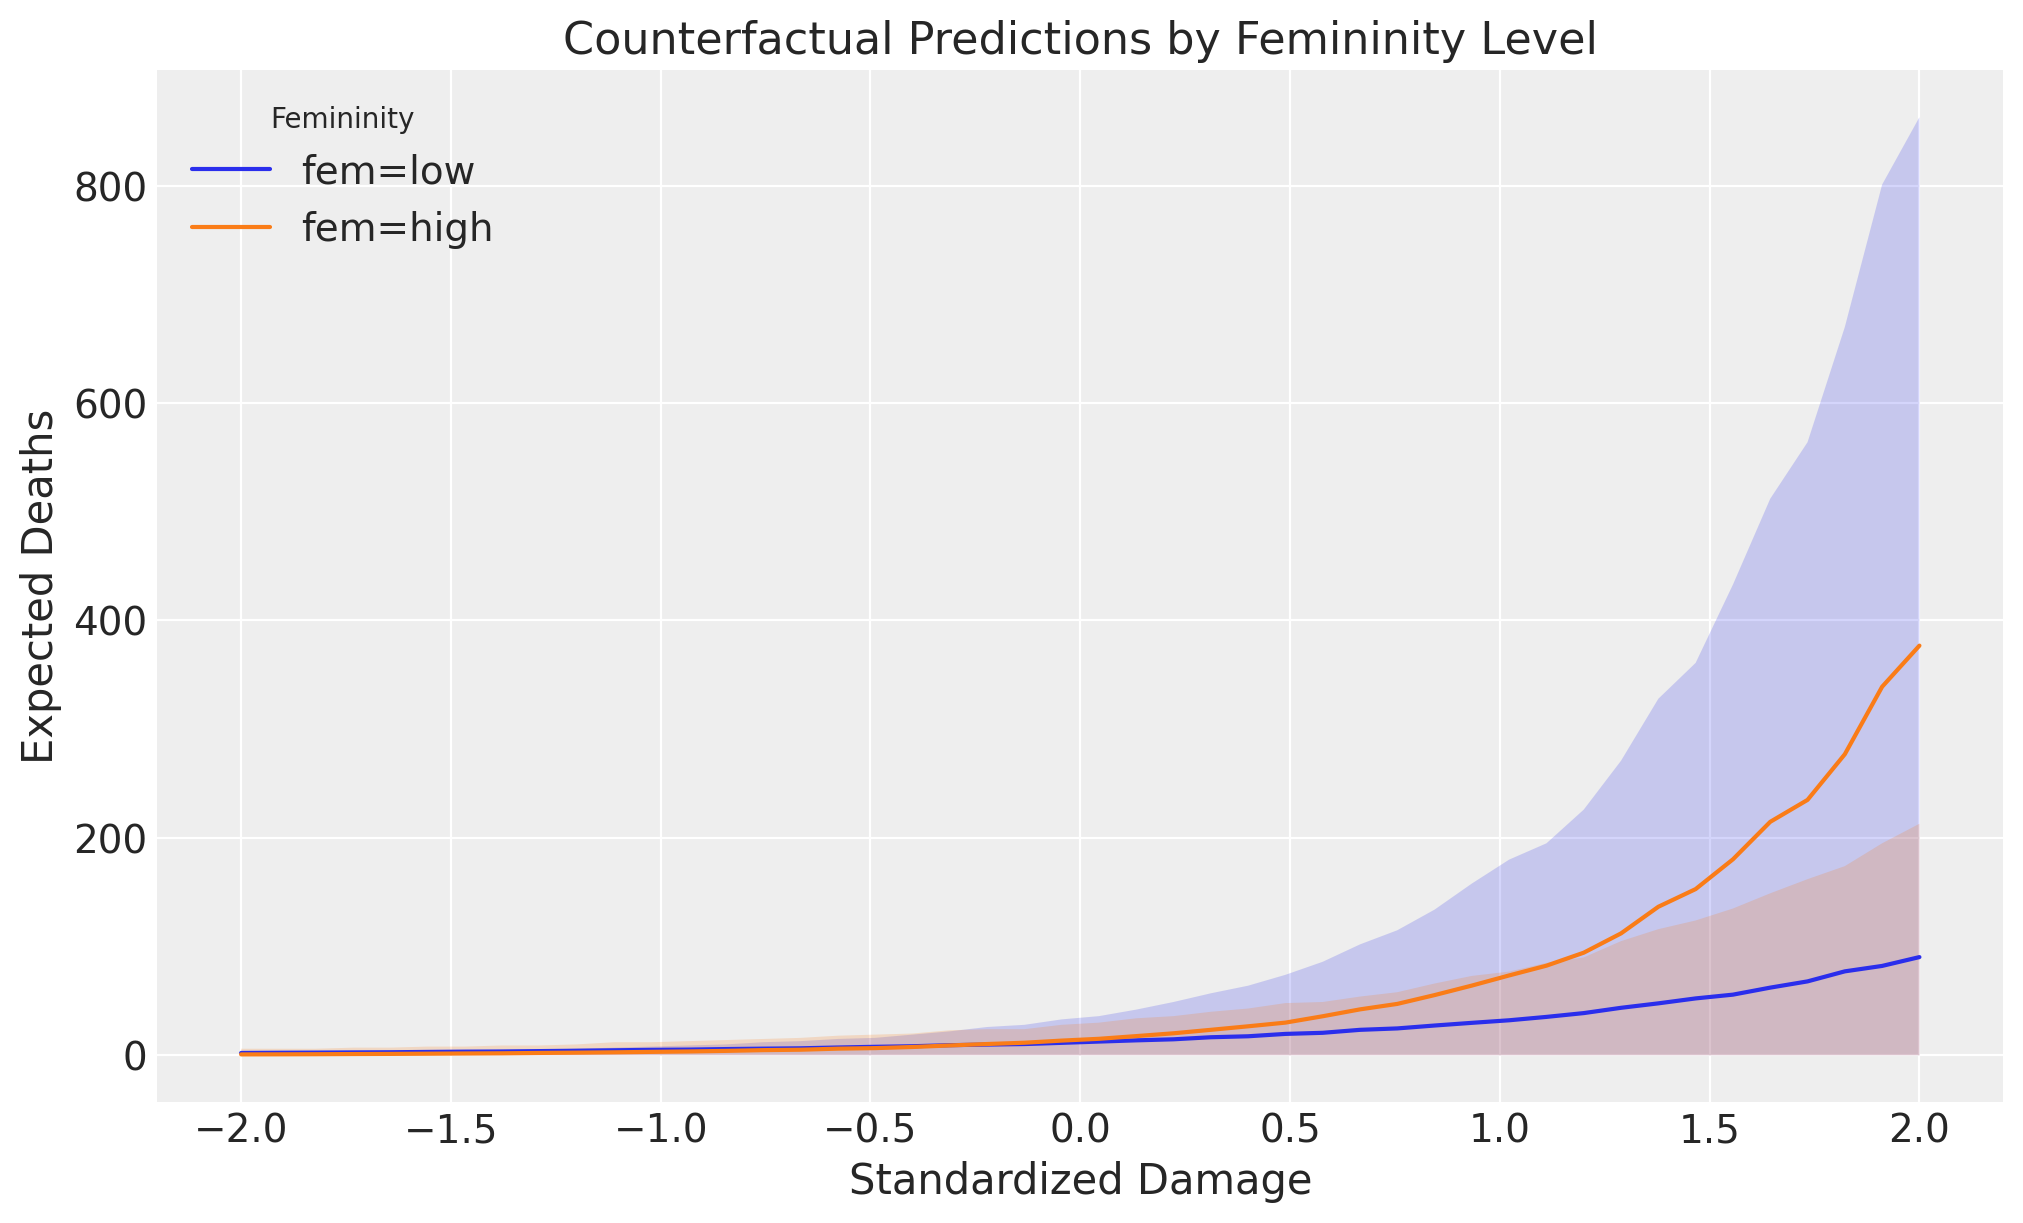

In [106]:
import seaborn as sns

y_preds = ppc_cf.posterior_predictive["deaths"]  # shape: (samples, N)
pred_mean = y_preds.mean(dim=('chain', 'draw'))
pred_hdi = az.hdi(y_preds, hdi_prob=0.89)

cf_df["mean"] = pred_mean.values
cf_df["hdi_low"] = pred_hdi['deaths'][:, 0].values
cf_df["hdi_high"] = pred_hdi['deaths'][:, 1].values

plt.figure(figsize=(10, 6))
sns.lineplot(data=cf_df, x="damage", y="mean", hue="label")
for label, grp in cf_df.groupby("label"):
    plt.fill_between(grp["damage"], grp["hdi_low"], grp["hdi_high"], alpha=0.2)

plt.xlabel("Standardized Damage")
plt.ylabel("Expected Deaths")
plt.title("Counterfactual Predictions by Femininity Level")
plt.grid(True)
plt.legend(title="Femininity")
plt.show()

expected deaths increase with higher damage and female ones specifically. But HDI get very wide mean values are very much different. but not very certain

12H4.  In the original hurricanes paper, storm damage (damage_norm) was used directly. This assumption implies that mortality increases exponentially with a linear increase in storm strength, because a Poisson regression uses a log link. So it’s worth exploring an alternative hypothesis: that the logarithm of storm strength is what matters. Explore this by using the logarithm of damage_norm as a predictor. Using the best model structure from the previous problem, compare a model that uses log(damage_norm) to a model that uses damage_norm directly. Compare their PSIS/WAIC values as well as their implied predictions. What do you conclude?

<Axes: >

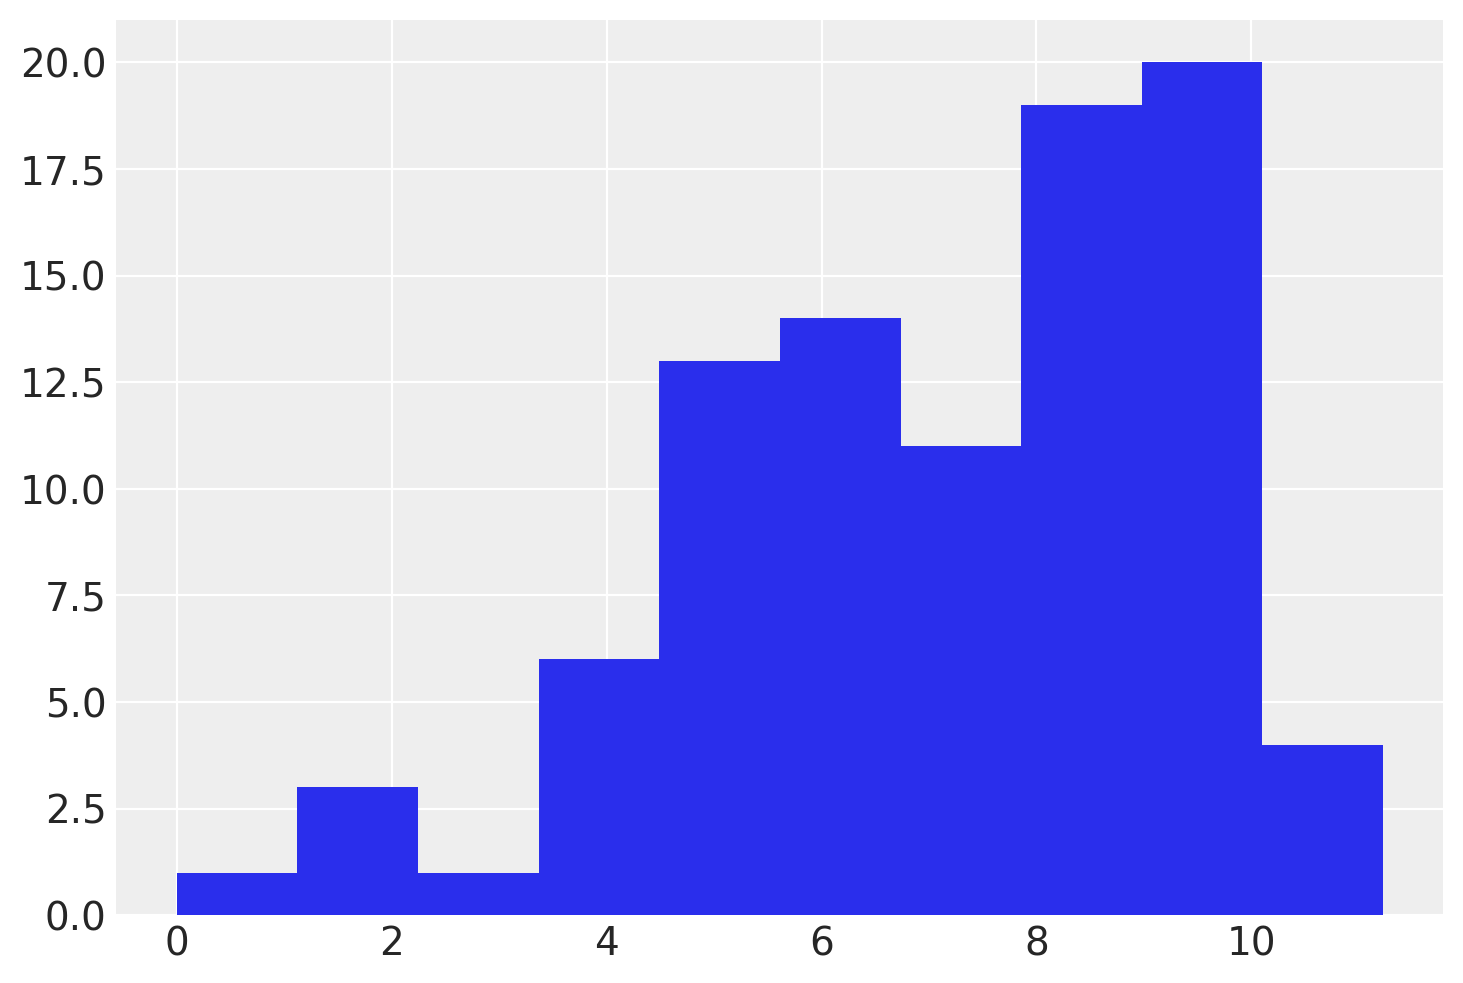

In [108]:
df_hurricane["damage_norm_log"] = np.log(df_hurricane.damage_norm)
df_hurricane["damage_norm_log"].hist()

In [109]:
with pm.Model() as m_hurricane_negbin_damage_log:
    a = pm.Normal("a", 0.0, 1.0)
    b_feminity = pm.Normal("b_feminity", 0.0, 1.0) 
    b_damage = pm.Normal("b_damage", 0.0, 1.0) 
    b_damage_feminity= pm.Normal("b_damage_feminity", 0.0, 1.0) 
    
    femininity = pm.Data("femininity", df_hurricane.femininity_std)
    damage = pm.Data("damage", df_hurricane.damage_norm_log)
    alpha=pm.Exponential("alpha", 1.0)
    
    eta = a + b_feminity * femininity + b_damage* damage + b_damage_feminity* damage*femininity
    lam = pm.math.exp(eta)

    deaths = pm.NegativeBinomial("deaths", lam, alpha=alpha, observed=df_hurricane.deaths)

    trace_m_hurricane_negbin_damage_log = pm.sample(cores =4, random_seed=RANDOM_SEED,
                           return_inferencedata=True,
    idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b_feminity, b_damage, b_damage_feminity, alpha]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1268 seconds.


In [110]:
az.summary(trace_m_hurricane_negbin_damage_log)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-1.622,0.398,-2.253,-0.989,0.009,0.007,1899.0,2139.0,1.0
b_feminity,-0.369,0.386,-0.935,0.291,0.009,0.007,2005.0,1830.0,1.0
b_damage,0.545,0.049,0.469,0.624,0.001,0.001,1926.0,2026.0,1.0
b_damage_feminity,0.059,0.048,-0.021,0.134,0.001,0.001,1997.0,1977.0,1.0
alpha,1.043,0.174,0.775,1.322,0.003,0.003,2840.0,2294.0,1.0


In [115]:
np.exp(0.545)

np.float64(1.7246083823764355)

A 1-unit increase in log(damage) (which corresponds to a ~2.7× increase in actual damage) increases expected deaths by ~72% (1.72 times).

In [111]:
az.loo(trace_m_hurricane_negbin_damage_log)

Computed from 4000 posterior samples and 92 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -315.18    15.28
p_loo        4.76        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       92  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

Sampling: [deaths]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

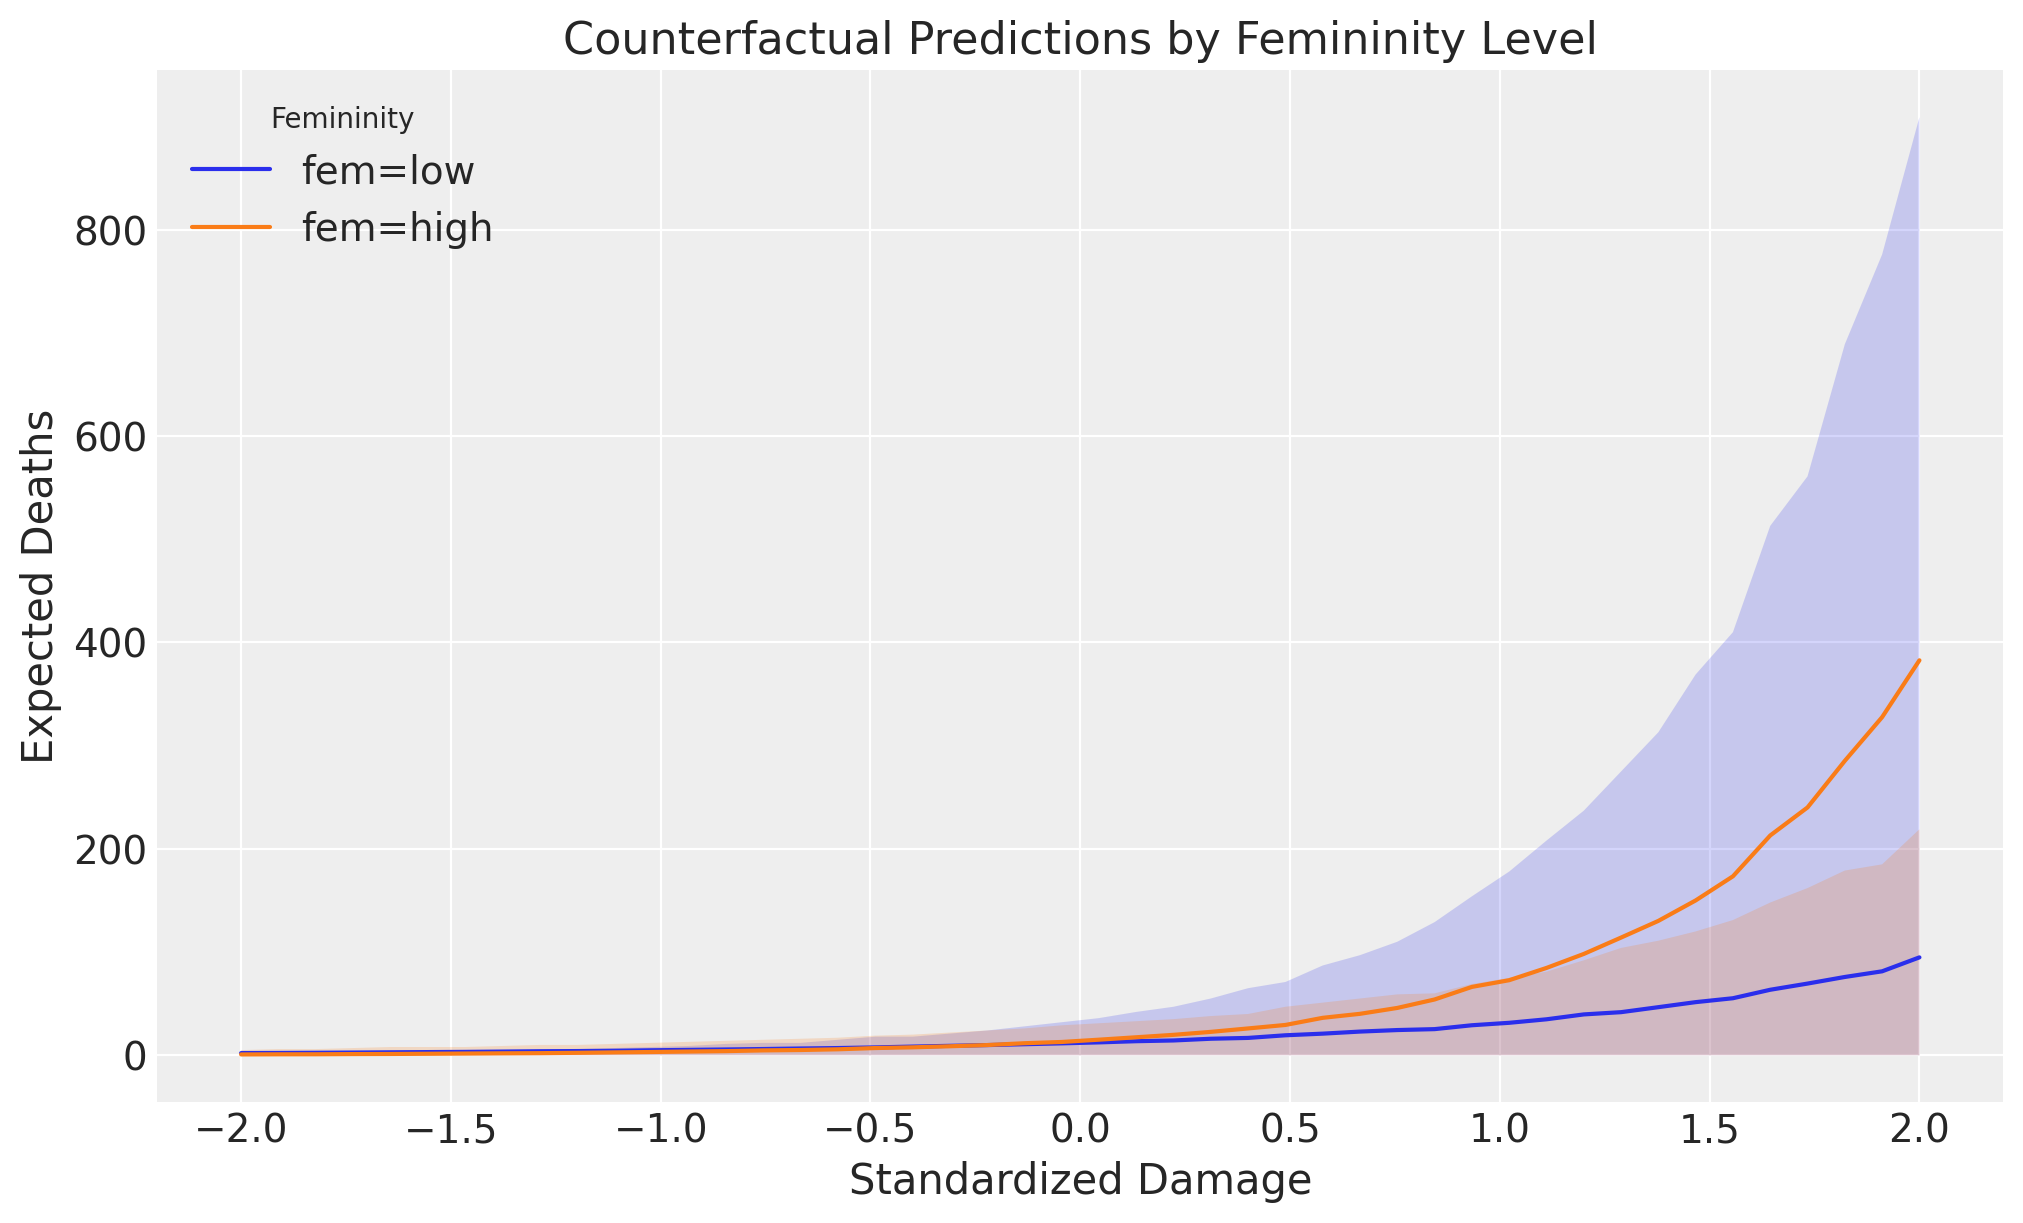

In [112]:
#counterfactual of the best model
fem_values = [-1, 1]        # low and high femininity
damage_values = np.linspace(-2, 2, 46)  # gradient of damage

# Build counterfactual combinations
cf_df = pd.DataFrame(
    [(f, d) for f in fem_values for d in damage_values],
    columns=["femininity", "damage"]
)
cf_df["label"] = ["fem=low"] * len(damage_values) + ["fem=high"] * len(damage_values)

with m_hurricane_negbin_damage_log:
    pm.set_data({
        "femininity": cf_df["femininity"].values,
        "damage": cf_df["damage"].values
    })
    ppc_cf = pm.sample_posterior_predictive(trace_m_hurricane_negbin_damage, var_names=["deaths"])

y_preds = ppc_cf.posterior_predictive["deaths"]  # shape: (samples, N)
pred_mean = y_preds.mean(dim=('chain', 'draw'))
pred_hdi = az.hdi(y_preds, hdi_prob=0.89)

cf_df["mean"] = pred_mean.values
cf_df["hdi_low"] = pred_hdi['deaths'][:, 0].values
cf_df["hdi_high"] = pred_hdi['deaths'][:, 1].values

plt.figure(figsize=(10, 6))
sns.lineplot(data=cf_df, x="damage", y="mean", hue="label")
for label, grp in cf_df.groupby("label"):
    plt.fill_between(grp["damage"], grp["hdi_low"], grp["hdi_high"], alpha=0.2)

plt.xlabel("Standardized Damage")
plt.ylabel("Expected Deaths")
plt.title("Counterfactual Predictions by Femininity Level")
plt.grid(True)
plt.legend(title="Femininity")
plt.show()

this model is better than previous best one. damage_norm on log scale makes better predictions

12H5.  One hypothesis from developmental psychology, usually attributed to Carol Gilligan, proposes that women and men have different average tendencies in moral reasoning. Like most hypotheses in social psychology, it is descriptive, not causal. The notion is that women are more concerned with care (avoiding harm), while men are more concerned with justice and rights. Evaluate this hypothesis, using the Trolley data, supposing that contact provides a proxy for physical harm. Are women more or less bothered by contact than are men, in these data? Figure out the model(s) that is needed to address this question.

In [4]:
trolley_df = pd.read_csv("Data/Trolley.csv", sep=";")
#subset
#trolley_df=trolley_df.head(1000)
trolley_df.head()

,case,response,order,id,age,male,edu,action,intention,contact,story,action2
0,cfaqu,4,2,96;434,14,0,Middle School,0,0,1,aqu,1
1,cfbur,3,31,96;434,14,0,Middle School,0,0,1,bur,1
2,cfrub,4,16,96;434,14,0,Middle School,0,0,1,rub,1
3,cibox,3,32,96;434,14,0,Middle School,0,1,1,box,1
4,cibur,3,4,96;434,14,0,Middle School,0,1,1,bur,1


In [11]:
trolley_df

,case,response,order,id,age,male,edu,action,intention,contact,story,action2
0,cfaqu,4,2,96;434,14,0,Middle School,0,0,1,aqu,1
1,cfbur,3,31,96;434,14,0,Middle School,0,0,1,bur,1
2,cfrub,4,16,96;434,14,0,Middle School,0,0,1,rub,1
3,cibox,3,32,96;434,14,0,Middle School,0,1,1,box,1
4,cibur,3,4,96;434,14,0,Middle School,0,1,1,bur,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,cispe,1,24,96;599,46,1,Master's Degree,0,1,1,spe,1
996,fkaqu,4,4,96;599,46,1,Master's Degree,1,0,0,aqu,1
997,fkboa,6,21,96;599,46,1,Master's Degree,1,0,0,boa,1
998,fkbox,7,10,96;599,46,1,Master's Degree,1,0,0,box,1


In [10]:
R = trolley_df.response.values - 1

with pm.Model() as m_trolley:
    cutpoints = pm.Normal(
        "cutpoints",
        0.0,
        1.5,
        transform=pm.distributions.transforms.ordered,
        shape=6,
        initval=np.arange(6) - 2.5,
    )
    bS = pm.Normal("bS", 0.0, 0.5)
    bC = pm.Normal("bC", 0.0, 0.5)
    bI = pm.Normal("bI", 0.0, 0.5)


    gender = pm.Data("gender", trolley_df.male.values)
    contact = pm.Data("contact", trolley_df.contact.values)
    
    phi = pm.Deterministic("phi", bC * contact + bS * gender + bI * contact * gender)

    resp_obs = pm.OrderedLogistic("resp_obs", phi, cutpoints, observed=R)

    trace_m_trolley = pm.sample(random_seed=RANDOM_SEED, 
                                chains=4,
                                cores=4,
                               init="adapt_diag")

az.summary(trace_m_trolley, var_names=["bS", "bC", "bI"], round_to=2)

Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints, bS, bC, bI]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bS,0.62,0.12,0.44,0.82,0.0,0.0,4461.27,3296.30,1.0
bC,-0.39,0.17,-0.64,-0.09,0.0,0.0,4142.80,3618.46,1.0
bI,-0.56,0.24,-0.93,-0.17,0.0,0.0,3912.64,3487.57,1.0


12H6.  The data in data(Fish) are records of visits to a national park. See ?Fish for details. The question of interest is how many fish an average visitor takes per hour, when fishing. The problem is that not everyone tried to fish, so the fish_caught numbers are zero-inflated. As with the monks example in the chapter, there is a process that determines who is fishing (working) and another process that determines fish per hour (manuscripts per day), conditional on fishing (working). We want to model both. Otherwise we’ll end up with an underestimate of rate of fish extraction from the park.

You will model these data using zero-inflated Poisson GLMs. Predict fish_caught as a function of any of the other variables you think are relevant. One thing you must do, however, is use a proper Poisson offset/exposure in the Poisson portion of the zero-inflated model. Then use the hours variable to construct the offset. This will adjust the model for the differing amount of time individuals spent in the park.

In [13]:
df_fish=pd.read_csv('End_of_chapter_problems/data/Fish.csv', sep=';')
df_fish.shape

(250, 6)

In [14]:
df_fish.head()

,fish_caught,livebait,camper,persons,child,hours
0,0,0,0,1,0,21.124
1,0,1,1,1,0,5.732
2,0,1,0,1,0,1.323
3,0,1,1,2,1,0.548
4,1,1,0,1,0,1.695


In [16]:
#log_hours = np.log(df_fish.hours)

with pm.Model() as m_fish:
    ap = pm.Normal("ap", -1.5, 1.0)
    al = pm.Normal("al", 1.0, 0.5)

    p = pm.Deterministic("p_zero", pm.math.invlogit(ap))   # zero-inflation probability
    psi = 1.0 - p  # Poisson part probability
    eta = al  # intercept or linear model
    log_hours = pm.Data("log_hours", np.log(df_fish.hours.values))
    lambda_ = pm.math.exp(log_hours + eta)  # log offset + linear predictor

    y_obs = pm.ZeroInflatedPoisson("fish_caught", psi, lambda_, observed=df_fish.fish_caught)

    trace_m_fish = pm.sample(random_seed=RANDOM_SEED)
az.summary(trace_m_fish, round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ap, al]


C:\Users\risto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 546 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ap,-0.78,0.18,-1.05,-0.47,0.0,0.0,4185.83,2898.74,1.0
al,-0.14,0.04,-0.20,-0.08,0.0,0.0,3956.62,2900.36,1.0
p_zero,0.32,0.04,0.25,0.38,0.0,0.0,4185.83,2898.74,1.0


In [18]:
np.exp(-0.14)

np.float64(0.8693582353988059)

The base rate of fish per hour (for the Poisson part of the model) is scaled by a factor of 0.87 → meaning:

On average, visitors who were fishing caught 13% fewer fish per hour than 1 fish/hr (since exp(0) = 1 is neutral).

If you had predictors (like camper or child), their coefficients would also be exponentiated and interpreted as multiplicative effects on rate.m

In [22]:
logistic(-0.78)# = p_zero = 0.32

np.float64(0.31431988606174616)

About 32% of people have a structural reason to catch zero fish (i.e., they didn’t fish). That’s not the same as just catching zero by chance — this is the zero-inflated component.

So even though the Poisson rate λ is ~0.87 × hours, the overall expected number of fish is lower because ~32% of people are predicted to have structural zeros.

12H7.  In the trolley data—data(Trolley)—we saw how education level (modeled as an ordered category) is associated with responses. But is this association causal? One plausible confound is that education is also associated with age, through a causal process: People are older when they finish school than when they begin it. Reconsider the Trolley data in this light. Draw a DAG that represents hypothetical causal relationships among response, education, and age. Which statical model or models do you need to evaluate the causal influence of education on responses? Fit these models to the trolley data. What do you conclude about the causal relationships among these three variables?

In [23]:
#E > R, A > R, A > E > R

In [5]:
R = trolley_df.response.values - 1
trolley_df["edu_new"] = pd.Categorical(
    trolley_df.edu.values,
    categories=[
        "Elementary School",
        "Middle School",
        "Some High School",
        "High School Graduate",
        "Some College",
        "Bachelor's Degree",
        "Master's Degree",
        "Graduate Degree",
    ],
    ordered=True,
)
trolley_df["edu_new"] = trolley_df.edu_new.cat.codes

In [5]:
trolley_df

,case,response,order,id,age,male,edu,action,intention,contact,story,action2,edu_new
0,cfaqu,4,2,96;434,14,0,Middle School,0,0,1,aqu,1,1
1,cfbur,3,31,96;434,14,0,Middle School,0,0,1,bur,1,1
2,cfrub,4,16,96;434,14,0,Middle School,0,0,1,rub,1,1
3,cibox,3,32,96;434,14,0,Middle School,0,1,1,box,1,1
4,cibur,3,4,96;434,14,0,Middle School,0,1,1,bur,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9925,ilpon,3,23,98;299,66,1,Graduate Degree,0,1,0,pon,0,7
9926,ilsha,6,15,98;299,66,1,Graduate Degree,0,1,0,sha,0,7
9927,ilshi,7,7,98;299,66,1,Graduate Degree,0,1,0,shi,0,7
9928,ilswi,2,18,98;299,66,1,Graduate Degree,0,1,0,swi,0,7


In [6]:
R = trolley_df.response.values - 1
A = trolley_df.action.values
I = trolley_df.intention.values
C = trolley_df.contact.values
E = trolley_df.edu_new.values

In [29]:


with pm.Model() as m_trolley_edu:
    kappa = pm.Normal(
        "kappa",
        0.0,
        1.5,
        transform=pm.distributions.transforms.ordered,
        shape=6,
        initval=np.arange(6),
    )

    bE = pm.Normal("bE", 0.0, 0.5)

    delta = pm.Dirichlet("delta", np.repeat(2.0, 7), shape=7)
    delta_j = at.concatenate([at.zeros(1), delta])
    delta_j_cumulative = at.cumsum(delta_j)

    phi = bE * delta_j_cumulative[E]

    resp_obs = pm.OrderedLogistic("resp_obs", phi, kappa, observed=R)

    trace_m_trolley_edu = pm.sample(target_accept=0.9, random_seed=RANDOM_SEED)

az.summary(trace_m_trolley_edu, var_names=["bE"], round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, bE, delta]
/usr/local/lib/python3.11/dist-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Output()

/usr/local/lib/python3.11/dist-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 187 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bE,-0.31,0.16,-0.54,-0.05,0.0,0.0,1204.47,1531.72,1.0


In [30]:
R = trolley_df.response.values - 1

with pm.Model() as m_trolley_age:
    cutpoints = pm.Normal(
        "cutpoints",
        0.0,
        1.5,
        transform=pm.distributions.transforms.ordered,
        shape=6,
        initval=np.arange(6) - 2.5,
    )
    bA = pm.Normal("bA", 0.0, 0.5)


    age = pm.Data("age", standardize(trolley_df.age).values)
    
    phi = pm.Deterministic("phi", bA * age)

    resp_obs = pm.OrderedLogistic("resp_obs", phi, cutpoints, observed=R)

    trace_m_trolley_age = pm.sample(random_seed=RANDOM_SEED, 
                                chains=4,
                                cores=4,
                               init="adapt_diag")

az.summary(trace_m_trolley_age, var_names=["bA"], round_to=2)

Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints, bA]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 35 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bA,-0.07,0.02,-0.1,-0.04,0.0,0.0,7031.21,3193.24,1.0


In [31]:
with pm.Model() as m_trolley_edu_age:
    kappa = pm.Normal(
        "kappa",
        0.0,
        1.5,
        transform=pm.distributions.transforms.ordered,
        shape=6,
        initval=np.arange(6),
    )

    bE = pm.Normal("bE", 0.0, 0.5)
    bA = pm.Normal("bA", 0.0, 0.5)
    age = pm.Data("age", standardize(trolley_df.age).values)

    delta = pm.Dirichlet("delta", np.repeat(2.0, 7), shape=7)
    delta_j = at.concatenate([at.zeros(1), delta])
    delta_j_cumulative = at.cumsum(delta_j)

    phi = bE * delta_j_cumulative[E] + bA*age

    resp_obs = pm.OrderedLogistic("resp_obs", phi, kappa, observed=R)

    trace_m_trolley_edu_age = pm.sample(target_accept=0.9, random_seed=RANDOM_SEED)

az.summary(trace_m_trolley_edu_age, var_names=["bE", "bA"], round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, bE, bA, delta]


Output()

/usr/local/lib/python3.11/dist-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/usr/local/lib/python3.11/dist-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 163 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bE,0.16,0.15,-0.06,0.38,0.01,0.01,680.03,522.98,1.01
bA,-0.08,0.02,-0.12,-0.05,0.00,0.00,996.64,1008.20,1.01


In [32]:
with pm.Model() as m_trolley_edu_age_inter:
    kappa = pm.Normal(
        "kappa",
        0.0,
        1.5,
        transform=pm.distributions.transforms.ordered,
        shape=6,
        initval=np.arange(6),
    )

    bE = pm.Normal("bE", 0.0, 0.5)
    bA = pm.Normal("bA", 0.0, 0.5)
    bInter = pm.Normal("bInter", 0.0, 0.5)
    age = pm.Data("age", standardize(trolley_df.age).values)

    delta = pm.Dirichlet("delta", np.repeat(2.0, 7), shape=7)
    delta_j = at.concatenate([at.zeros(1), delta])
    delta_j_cumulative = at.cumsum(delta_j)

    phi = bE * delta_j_cumulative[E] + bA*age + bInter*age*delta_j_cumulative[E]

    resp_obs = pm.OrderedLogistic("resp_obs", phi, kappa, observed=R)

    trace_m_trolley_edu_age_inter = pm.sample(target_accept=0.9, random_seed=RANDOM_SEED)

az.summary(trace_m_trolley_edu_age_inter, var_names=["bE", "bA", "bInter"], round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, bE, bA, bInter, delta]


Output()

/usr/local/lib/python3.11/dist-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/usr/local/lib/python3.11/dist-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/usr/local/lib/python3.11/dist-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 180 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bE,0.32,0.12,0.13,0.51,0.0,0.0,1379.80,1540.63,1.0
bA,-0.29,0.09,-0.42,-0.15,0.0,0.0,1474.55,1322.48,1.0
bInter,0.28,0.10,0.12,0.44,0.0,0.0,1548.67,1340.43,1.0


In [33]:
az.summary(trace_m_trolley_edu_age, var_names=["bE", "bA"], round_to=2)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bE,0.16,0.15,-0.06,0.38,0.01,0.01,680.03,522.98,1.01
bA,-0.08,0.02,-0.12,-0.05,0.00,0.00,996.64,1008.20,1.01


In [34]:
np.exp(-0.08)

0.9231163463866358

Age is negatively related to output, increase of age by 1 unit (in standardadized scale) diminshes output odds by 0.08 (1-np.exp(-0.08)) units

In [35]:
az.summary(trace_m_trolley_edu_age_inter, var_names=["bE", "bA", "bInter"], round_to=2)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bE,0.32,0.12,0.13,0.51,0.0,0.0,1379.80,1540.63,1.0
bA,-0.29,0.09,-0.42,-0.15,0.0,0.0,1474.55,1322.48,1.0
bInter,0.28,0.10,0.12,0.44,0.0,0.0,1548.67,1340.43,1.0


In [43]:
np.exp(0.28)

1.3231298123374369

In [37]:
np.exp(-0.29)

0.7482635675785653

In [44]:
np.exp(0.32)

1.3771277643359572

here age has even more diminshing effect (0.74) and interaction term is positive higher education increases age effect or higher age increases education effect log odds. also here education is with positive effect

In [39]:
az.summary(trace_m_trolley_age, var_names=["bA"], round_to=2)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bA,-0.07,0.02,-0.1,-0.04,0.0,0.0,7031.21,3193.24,1.0


In [45]:
np.exp(-0.07)

0.9323938199059483

Age is barely significant (in some models depending on the randomness), it decreases the odds of 0.93 times in response if age changes by 1 unit

In [46]:
az.summary(trace_m_trolley_edu, var_names=["bE"], round_to=2)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bE,-0.31,0.16,-0.54,-0.05,0.0,0.0,1204.47,1531.72,1.0


In [42]:
np.exp(-0.31)

0.7334469562242892

education seems to have negative effect by diminishing odds of outcome by 1-0.73.

When controlling for age, education’s effect shifts from negative to positive, suggesting that the raw education–response association was confounded by age.

| DAG ID | Description                                      | Variables                  | Arrows / Edges                             | Notes                                                       |
|--------|--------------------------------------------------|----------------------------|--------------------------------------------|-------------------------------------------------------------|
| DAG 1  | Age → Response                                   | Age (A), Response (R)      | A → R                                      | Age has significant negative effect on moral response       |
| DAG 2  | Age confounds Education → Response               | Age (A), Education (E), R  | A → E, A → R, E → R                        | Age and education both influence response, potential confound|
| DAG 3  | Age × Education interaction → Response           | A, E, R, Interaction (I)   | A → R, E → R, A → I, E → I, I → R          | Interaction is significant and positive                     |


12H8.  Consider one more variable in the trolley data: Gender. Suppose that gender might influence education as well as response directly. Draw the DAG now that includes response, education, age, and gender. Using only the DAG, is it possible that the inferences from 12H7 above are confounded by gender? If so, define any additional models you need to infer the causal influence of education on response. What do you conclude?

G → E → R
↓       ↑
→ R     ↑
A → E → R


In [47]:
with pm.Model() as m_trolley_edu_age_gender:
    kappa = pm.Normal("kappa", 0.0, 1.5, 
                      transform=pm.distributions.transforms.ordered, 
                      shape=6, initval=np.arange(6))
    
    bE = pm.Normal("bE", 0.0, 0.5)
    bA = pm.Normal("bA", 0.0, 0.5)
    bG = pm.Normal("bG", 0.0, 0.5)

    age = pm.Data("age", standardize(trolley_df.age).values)
    gender = pm.Data("gender", trolley_df.male.values)  # Assuming 1=male, 0=female

    delta = pm.Dirichlet("delta", np.repeat(2.0, 7), shape=7)
    delta_j = at.concatenate([at.zeros(1), delta])
    delta_j_cumulative = at.cumsum(delta_j)

    phi = bE * delta_j_cumulative[E] + bA * age + bG * gender

    resp_obs = pm.OrderedLogistic("resp_obs", phi, kappa, observed=R)

    trace_m_trolley_edu_age_gender = pm.sample(target_accept=0.9, random_seed=RANDOM_SEED)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, bE, bA, bG, delta]


Output()

/usr/local/lib/python3.11/dist-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/usr/local/lib/python3.11/dist-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/usr/local/lib/python3.11/dist-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 167 seconds.


In [48]:
az.summary(trace_m_trolley_edu_age_gender)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bE,-0.044,0.164,-0.279,0.233,0.005,0.002,1122.0,2054.0,1.0
bA,-0.053,0.022,-0.088,-0.019,0.000,0.000,2163.0,2580.0,1.0
bG,0.539,0.035,0.482,0.593,0.000,0.001,5036.0,2587.0,1.0
kappa[0],-1.684,0.122,-1.852,-1.473,0.004,0.002,1122.0,1723.0,1.0
kappa[1],-1.033,0.121,-1.220,-0.844,0.004,0.002,1121.0,1803.0,1.0
...,...,...,...,...,...,...,...,...,...
"resp_obs_probs[9929, 2]",0.101,0.004,0.095,0.107,0.000,0.000,4693.0,3360.0,1.0
"resp_obs_probs[9929, 3]",0.234,0.005,0.227,0.242,0.000,0.000,5462.0,2899.0,1.0
"resp_obs_probs[9929, 4]",0.155,0.004,0.149,0.162,0.000,0.000,5230.0,2407.0,1.0
"resp_obs_probs[9929, 5]",0.157,0.005,0.148,0.165,0.000,0.000,4614.0,3579.0,1.0


In [57]:
np.exp(0.539)

1.7142917130401751

in this model Gender seems to have positive effect

In [49]:
with pm.Model() as m_trolley_gender:
    cutpoints = pm.Normal(
        "cutpoints",
        0.0,
        1.5,
        transform=pm.distributions.transforms.ordered,
        shape=6,
        initval=np.arange(6) - 2.5,
    )

    bG = pm.Normal("bG", 0.0, 0.5)  # Gender effect

    gender = pm.Data("gender", trolley_df["male"].values)  # 1 = male, 0 = female
    phi = pm.Deterministic("phi", bG * gender)

    R = trolley_df["response"].values - 1  # Assuming responses coded 1–7
    resp_obs = pm.OrderedLogistic("resp_obs", phi, cutpoints, observed=R)

    trace_gender = pm.sample(
        target_accept=0.9, 
        random_seed=RANDOM_SEED)
    
az.summary(trace_gender)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints, bG]


Output()

/usr/local/lib/python3.11/dist-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 50 seconds.
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chai

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bG,0.542,0.037,0.484,0.599,0.001,0.001,3546.0,3191.0,1.0
cutpoints[0],-1.647,0.035,-1.704,-1.591,0.001,0.001,2963.0,2685.0,1.0
cutpoints[1],-0.997,0.030,-1.042,-0.948,0.000,0.000,3765.0,3434.0,1.0
cutpoints[2],-0.444,0.028,-0.492,-0.403,0.000,0.000,4096.0,3400.0,1.0
cutpoints[3],0.542,0.028,0.499,0.589,0.000,0.000,4031.0,3703.0,1.0
...,...,...,...,...,...,...,...,...,...
"resp_obs_probs[9929, 2]",0.095,0.003,0.090,0.100,0.000,0.000,4246.0,3210.0,1.0
"resp_obs_probs[9929, 3]",0.228,0.004,0.221,0.235,0.000,0.000,3943.0,2834.0,1.0
"resp_obs_probs[9929, 4]",0.159,0.004,0.153,0.165,0.000,0.000,3972.0,3066.0,1.0
"resp_obs_probs[9929, 5]",0.167,0.004,0.160,0.173,0.000,0.000,4076.0,3303.0,1.0


In [51]:
np.exp(0.542)

1.7194423102121061

Gender seems to have positive effect, increases outcome odds 1.72 times when gender changes female to male

In [63]:
trolley_df.edu_new.value_counts()

edu_new
5    3540
4    2460
6    1410
7    1050
3     870
2     420
1     120
0      60
Name: count, dtype: int64

In [64]:
with pm.Model() as m_gender_to_edu:
    kappa = pm.Normal(
        "kappa",
        0.0,
        1.5,
        transform=pm.distributions.transforms.ordered,
        shape=7,  # not 6
        initval=np.linspace(-3, 3, 7)
    )

    bG = pm.Normal("bG", 0.0, 0.5)

    gender = pm.Data("gender", trolley_df["male"].values)
    phi = pm.Deterministic("phi", bG * gender)

    E = trolley_df["edu_new"].values  # assuming 0-6 encoding for 7 levels
    edu_obs = pm.OrderedLogistic("edu_obs", phi, kappa, observed=E)

    trace_gender_to_edu = pm.sample(
        target_accept=0.9,
        random_seed=RANDOM_SEED
    )

az.summary(trace_gender_to_edu)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, bG]


Output()

/usr/local/lib/python3.11/dist-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 143 seconds.
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_cha

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bG,0.159,0.035,0.104,0.215,0.001,0.001,4392.0,3036.0,1.0
kappa[0],-4.982,0.127,-5.172,-4.770,0.003,0.002,2577.0,2817.0,1.0
kappa[1],-3.886,0.076,-4.009,-3.765,0.001,0.001,4271.0,2899.0,1.0
kappa[2],-2.650,0.046,-2.724,-2.577,0.001,0.001,4592.0,3167.0,1.0
kappa[3],-1.660,0.035,-1.718,-1.608,0.001,0.001,4521.0,3077.0,1.0
...,...,...,...,...,...,...,...,...,...
"edu_obs_probs[9929, 3]",0.083,0.003,0.078,0.087,0.000,0.000,4660.0,3157.0,1.0
"edu_obs_probs[9929, 4]",0.240,0.005,0.233,0.247,0.000,0.000,4377.0,3285.0,1.0
"edu_obs_probs[9929, 5]",0.360,0.005,0.353,0.368,0.000,0.000,4082.0,2900.0,1.0
"edu_obs_probs[9929, 6]",0.148,0.004,0.142,0.154,0.000,0.000,4454.0,3206.0,1.0


In [ ]:
np.exp(0.159)

Gender and education are positively related

In [7]:
with pm.Model() as m_trolley_edu_age_gender_inter:
    # Ordered cutpoints for the 7 response levels (6 thresholds)
    kappa = pm.Normal(
        "kappa",
        mu=0.0,
        sigma=1.5,
        transform=pm.distributions.transforms.ordered,
        shape=6,
        initval=np.arange(6)
    )

    # Priors for main effects and interactions
    bE = pm.Normal("bE", mu=0.0, sigma=0.5)      # education effect
    bA = pm.Normal("bA", mu=0.0, sigma=0.5)      # age effect
    bG = pm.Normal("bG", mu=0.0, sigma=0.5)      # gender effect
    bEA = pm.Normal("bEA", mu=0.0, sigma=0.5)    # education * age
    bEG = pm.Normal("bEG", mu=0.0, sigma=0.5)    # education * gender
    bAG = pm.Normal("bAG", mu=0.0, sigma=0.5)    # age * gender

    # Standardized age
    age_std = standardize(trolley_df.age).values
    gender = pm.Data("gender", trolley_df.male.values)
    age = pm.Data("age", age_std)

    # Encode education as ordered categories (0 to 6)
    E = trolley_df["edu_new"].values  # Ensure values are 0 to 6 inclusive

    # Flexible spacing for ordered categories
    delta = pm.Dirichlet("delta", a=np.repeat(2.0, 7), shape=7)
    delta_j = at.concatenate([at.zeros(1), delta])  # insert 0 at beginning
    delta_cum = at.cumsum(delta_j)

    # Linear model
    phi = (
        bE * delta_cum[E] +
        bA * age +
        bG * gender +
        bEA * delta_cum[E] * age +
        bEG * delta_cum[E] * gender +
        bAG * age * gender
    )

    # Ordered logistic likelihood
    resp_obs = pm.OrderedLogistic("resp_obs", eta=phi, cutpoints=kappa, observed=R)

    # Sample
    trace_m_trolley_edu_age_gender_inter = pm.sample(
        target_accept=0.9,
        random_seed=RANDOM_SEED
    )
az.summary(trace_m_trolley_edu_age_gender_inter, var_names=["bE", "bA", "bG", "bEA", "bEG", "bAG"])

Initializing NUTS using jitter+adapt_diag...
/usr/local/lib/python3.11/dist-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, bE, bA, bG, bEA, bEG, bAG, delta]
/usr/local/lib/python3.11/dist-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset i

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 288 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bE,-0.206,0.208,-0.534,0.126,0.006,0.003,1429.0,2542.0,1.0
bA,-0.082,0.084,-0.211,0.049,0.002,0.002,1806.0,1639.0,1.0
bG,0.182,0.150,-0.052,0.425,0.003,0.002,2256.0,2388.0,1.0
bEA,0.094,0.106,-0.075,0.258,0.002,0.002,1862.0,1836.0,1.0
bEG,0.505,0.198,0.194,0.829,0.004,0.003,1959.0,2362.0,1.0
bAG,-0.096,0.040,-0.161,-0.034,0.001,0.001,4372.0,3301.0,1.0


In [9]:
np.exp(0.505)

1.6569855204608508

In [10]:
np.exp(-0.096)

0.9084640160687062

in interaction model gender and education have positive interaction. age increases male response or maleness increases education response. Age and gender interaction has negative effect. With older age males tend ho have negative effect on logg-odds of response variable  

| Parameter | Mean   | 89% Interval            | Interpretation                                                    |
| --------- | ------ | ----------------------- | ----------------------------------------------------------------- |
| `bG`      | 0.54   | \[0.48, 0.59]           | Gender (male = 1): Increases odds of action response by **1.72×** |
| `bA`      | -0.05  | \[-0.09, -0.02]         | Age: Slightly **decreases** odds of action                        |
| `bE`      | varies | \[-0.28, 0.23] or wider | Education: No consistent effect across models                     |
| `bEG`     | 0.51   | \[0.19, 0.83]           | Gender × Education: Education has **more effect for males**       |
| `bAG`     | -0.10  | \[-0.16, -0.03]         | Age × Gender: Older **males less likely** to endorse action       |
| `bEA`     | 0.09   | \[-0.08, 0.26]          | Age × Education: No strong evidence                               |


Gender is the strongest predictor: Males consistently show higher willingness to endorse harm in the dilemma.

Age dampens endorsement, especially for males.

Education shows a positive effect when interacting with gender, suggesting education boosts endorsement for males but not females.

Gender influences education (small effect), indicating possible backdoor path confounding in simpler models.

Final interpretation must account for interaction terms, as education's effect is conditional on gender.

## 🧠 GLM Coefficient Interpretation Cheat Sheet

This guide helps you interpret regression coefficients depending on the distribution and link function used in your model.

---

### 🔗 Summary Table

| **Model Type**           | **Link Function**            | **Coefficient \( \beta \)** Interpretation      | **Use \( \exp(\beta) \) to interpret as…** |
|--------------------------|------------------------------|-------------------------------------------------|---------------------------------------------|
| **Binomial (Logistic)**  | \( \log\left(\frac{p}{1 - p}\right) \) | Change in log-odds of success                 | Odds ratio                                  |
| **Poisson**              | \( \log(\lambda) \)          | Change in log expected **count**               | Rate multiplier (multiplicative change)     |
| **Multinomial Logistic** | \( \log\left(\frac{p_k}{p_K}\right) \) | Change in log-odds for category \( k \) vs baseline \( K \) | Relative odds ratio                         |

---

### 📐 Interpretation Rules

#### ✅ Binomial / Logistic Regression

- Model:
  $$
  \log\left( \frac{p}{1 - p} \right) = \alpha + \beta x
  $$
- \( \beta \): change in **log-odds** of success per unit increase in \( x \)
- \( \exp(\beta) \): **odds multiplier**

> One unit increase in \( x \) multiplies the **odds of success** by \( \exp(\beta) \)

---

#### ✅ Poisson Regression

- Model:
  $$
  \log(\lambda) = \alpha + \beta x
  $$
- \( \lambda \): expected count
- \( \beta \): change in **log expected count**
- \( \exp(\beta) \): **rate multiplier**

> One unit increase in \( x \) multiplies the **expected count** by \( \exp(\beta) \)

---

#### ✅ Multinomial Logistic Regression

- Model:
  $$
  \log\left( \frac{p_k}{p_K} \right) = \alpha_k + \beta_k x
  $$
- \( \beta_k \): log-odds change for choosing category \( k \) vs. baseline \( K \)
- \( \exp(\beta_k) \): **relative odds ratio**

> One unit increase in \( x \) multiplies the **relative odds** of choosing class \( k \) over the baseline class \( K \)

---

### 📊 Quick Examples

| Model Type       | \( \beta = 0.5 \)        | \( \exp(0.5) \approx 1.65 \) Means…                      |
|------------------|--------------------------|-----------------------------------------------------------|
| Binomial         | Log-odds +0.5            | Odds increase by 65%                                     |
| Poisson          | Log-count +0.5           | Expected count increases by 65%                          |
| Multinomial (k)  | Log-odds vs class K +0.5 | Relative odds of class \( k \) vs \( K \) increase by 65% |

---

✅ Use this cheat sheet to know **when to exponentiate coefficients**, and **how to interpret them correctly** depending on the model.



In [49]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Sat Sep 24 2022

Python implementation: CPython
Python version       : 3.9.13
IPython version      : 8.4.0

arviz     : 0.12.1
aesara    : 2.6.6
scipy     : 1.7.3
numpy     : 1.22.1
matplotlib: 3.5.2
pandas    : 1.4.2
pymc      : 4.0.0

Watermark: 2.3.1

